# DreamerV3 — Robosuite Panda Pick-and-Place (Google Colab)

Complete training + evaluation pipeline for DreamerV3 on a simulated Franka Panda robot, running entirely in Colab.

**STOP — do this first, before running any cell:**
`Runtime` → `Change runtime type` → Hardware accelerator → **T4 GPU** → Save → `Runtime` → `Restart runtime`.
If the GPU-check cell prints `command not found`, the GPU isn't attached yet — go back and redo this step.

**RECONNECTED AFTER A DISCONNECT? Read this before doing anything else:**
Colab wipes `/content` (all code) every time the runtime disconnects or restarts. Only **Google Drive**
persists. This means:
- Your checkpoints are safe — they live in Drive, not in `/content`.
- The *code* (`train.py`, configs, etc.) is disposable — it doesn't need to survive, because it's
  regenerated in seconds from the cells below.
- **Every time you reconnect: re-run sections 1 → 2 → 3 → 4 in order, then run the training cell.**
  It will automatically resume from your last checkpoint. There is nothing to manually recover —
  just re-run the setup cells like a fresh session, because it is one.

**Stack used (current, Python-3.12-compatible — no legacy version pins):**
- `mujoco>=3.2.3` (current 3.x line, has prebuilt wheels for Python 3.12)
- `robosuite==1.5.1` (current release, written for MuJoCo 3.x, no `gym` dependency at all)
- PyTorch with CUDA (pre-installed on Colab GPU runtimes)

**How this notebook is organised:**
1. Mount Drive + check GPU
2. Install dependencies (~3-5 min)
3. Write project files (env wrapper, networks, training loop)
4. Validate the full stack
5. Train (auto-resumes from Drive every time)
6. Monitor progress
7. Evaluate + render video

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/dreamerv3_panda'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs', exist_ok=True)
print(f'Drive project dir (persists across sessions): {PROJECT_DIR}')
print('Only checkpoints/ and logs/ live here. Code is never stored in Drive — see note above.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive project dir (persists across sessions): /content/drive/MyDrive/dreamerv3_panda
Only checkpoints/ and logs/ live here. Code is never stored in Drive — see note above.


In [ ]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader
# If this prints "command not found", go to Runtime > Change runtime type > GPU, then Restart runtime.

Tesla T4, 15360 MiB, 580.82.07


## 2 — Install dependencies

**Current stack, no legacy version pins.** We deliberately do NOT install `gym` — modern
robosuite (1.5.x) doesn't need it, and `gym==0.21.0`'s old `setup.py` cannot build on Colab's
Python 3.12 (no fix exists for that combination). We also do NOT pin MuJoCo to 2.3.7 — that
version has no installable wheel for Python 3.12 either. Instead we use the current, mutually
compatible pair: `mujoco>=3.2.3` + `robosuite==1.5.1`, both of which ship clean Python 3.12 wheels.

Takes about 3-5 minutes.

In [ ]:
# Remove any conflicting packages that might already be present
!pip uninstall -y -q gym gymnasium mujoco mujoco-py robosuite 2>/dev/null
!pip install -q setuptools wheel --upgrade
print("Cleaned up old packages")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 21.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cu128 requires setuptools<82, but you have setuptools 84.0.0 which is incompatible.
Cleaned up old packages


In [ ]:
# # !pip install wandb -q

# import wandb
# wandb.login()   # paste your key from https://wandb.ai/authorize

In [ ]:
# System dependencies for headless MuJoCo rendering (EGL — uses the Colab GPU for rendering)
!apt-get update -qq
!apt-get install -y -qq libgl1-mesa-glx libosmesa6-dev libgl1-mesa-dev \
    libglew-dev patchelf libegl1-mesa-dev > /dev/null 2>&1
print("System deps installed")

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
System deps installed


In [ ]:

!pip install -q "robosuite==1.5.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.8/232.8 kB 9.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.2/182.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.1/107.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.6/927.6 kB 37.8 MB/s eta 0:00:00


In [ ]:
# Force the correct mujoco version right now, in this session
!pip uninstall -y -q mujoco
!pip install -q "mujoco==3.9.0"

import importlib
import mujoco
importlib.reload(mujoco)
print(f"mujoco version now: {mujoco.__version__}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 47.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mink 1.3.0 requires mujoco>=3.10.0, but you have mujoco 3.9.0 which is incompatible.
mujoco version now: 3.9.0


In [ ]:
!pip show mujoco | grep Version

Version: 3.9.0


In [ ]:
# Remaining dependencies (no gym, no old mujoco-py)
!pip install -q einops ruamel.yaml rich h5py \
    imageio imageio-ffmpeg opencv-python-headless \
    matplotlib tensorboard

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 1.4 MB/s eta 0:00:00

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# pip freeze > requirement.txt

## 3 — Write project files

Creates `/content/dreamerv3_panda` fresh (disposable, local disk) and symlinks `checkpoints/`
and `logs/` into Drive so they persist. Safe and necessary to re-run every session.

In [ ]:
import os, shutil

PROJECT = '/content/dreamerv3_panda'
PROJECT_DIR = '/content/drive/MyDrive/dreamerv3_panda'   # must already be mounted (section 1)

for d in ['configs', 'utils', 'scripts']:
    os.makedirs(f'{PROJECT}/{d}', exist_ok=True)

os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs', exist_ok=True)

for sub in ['checkpoints', 'logs']:
    local = f'{PROJECT}/{sub}'
    drive_path = f'{PROJECT_DIR}/{sub}'

    if os.path.exists(local) and not os.path.islink(local):
        shutil.rmtree(local)
    if not os.path.exists(local):
        os.symlink(drive_path, local)

print(f"Project structure created at {PROJECT}")

# Verify the symlinks are correct before continuing
all_ok = True
for sub in ['checkpoints', 'logs']:
    local = f'{PROJECT}/{sub}'
    ok = os.path.islink(local)
    all_ok = all_ok and ok
    print(f"  {sub}/: {'symlinked correctly' if ok else 'NOT a symlink -- something is wrong'}")
assert all_ok, "Fix the symlinks before continuing -- training will not find your checkpoints otherwise."


Project structure created at /content/dreamerv3_panda
  checkpoints/: symlinked correctly
  logs/: symlinked correctly


In [ ]:
%%writefile /content/dreamerv3_panda/utils/device.py
"""utils/device.py — Colab GPU edition (CUDA via T4/A100)"""
import torch

def get_device(prefer="auto"):
    if prefer == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(prefer)

def device_info(device):
    if device.type == "cuda":
        name = torch.cuda.get_device_name(0)
        mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
        return f"CUDA — {name} ({mem:.1f} GB VRAM)"
    return "CPU"


Writing /content/dreamerv3_panda/utils/device.py


In [ ]:
%%writefile /content/dreamerv3_panda/utils/__init__.py

Writing /content/dreamerv3_panda/utils/__init__.py


In [ ]:
%%writefile /content/dreamerv3_panda/configs/panda_pickplace_colab.yaml
# ═══════════════════════════════════════════════════════════════════════════
# DreamerV3 — Robosuite Panda PickPlaceCan
# REVISION 2 — matched to the fixed scripts/train.py
#
# [paper]    value from Hafner et al. 2023, Table 4
# [tuned]    adapted for Colab T4/L4
# [FIX]      changed in revision 2 to address the posterior collapse seen in
#            run dv3_202608 (world_model/kl pinned at 0.6, grad_norm at 0.01,
#            all policy stage rates flat at 0 through 15k steps)
# ═══════════════════════════════════════════════════════════════════════════

env:
  task: PickPlaceCan
  robot: Panda
  controller: OSC_POSE
  camera: agentview
  image_size: 64
  obs_keys:
    - robot0_eef_pos          # 3
    - robot0_eef_quat         # 4
    - robot0_gripper_qpos     # 2
    - robot0_joint_pos        # 7
    - object-state            # 14   -> 30 total
  reward_shaping: true        # required: InstrumentedEnv reads staged_rewards()
  control_freq: 20
  horizon: 500
  seed: 42

training:
  # [FIX] 2_000_000 was unreachable. At train_ratio 32 on a T4 you get roughly
  # 500 env steps/hour, so 2M steps is months of compute. Pick a number your
  # actual remaining budget supports and treat it as the real target.
  total_steps: 300_000
  prefill_steps: 10_000
  train_ratio: 32             # [paper] 32 gradient steps per env step
  checkpoint_every: 200     # [tuned] Drive I/O is expensive on Colab
  log_every: 20              # [tuned]
  collapse_check_every: 500 # [FIX] periodic decoder-variance diagnostic
  stat_window: 20             # rolling window for success-rate reporting
  device: cuda
  seed: 42
  mixed_precision: true

replay:
  capacity: 500_000
  batch_size: 16              # [paper] 16
  batch_length: 64            # [paper] 64
  min_seq_length: 64

world_model:
  # --- RSSM ---
  rssm_deter: 2048            # [tuned] paper 200M model uses 8192; 2048 fits a T4
  rssm_stoch: 32              # [paper]
  rssm_classes: 32            # [paper]  -> 32x32 discrete latent

  # --- encoders / decoders ---
  encoder_cnn_depth: 48
  encoder_mlp_units: 256

  # [FIX 5] Vector decoder. The paper reconstructs every observation modality.
  # Revision 1 decoded only the image, and at 64x64 the can spans a handful of
  # pixels — so the latent had almost no pressure to encode object position,
  # which is the one quantity this task depends on. Set false to ablate.
  decode_vector: true
  vector_decoder_layers: 2
  vector_decoder_units: 512
  # [FIX rev3] 1.0 -> 10.0. THE SUBSTANTIVE FIX of revision 3.
  # Measured: open-loop eef_pos error at H=15 was 0.125 m against a 0.05 m
  # reach threshold -- the world model is 2.5x less precise than the task
  # needs. Error concentrates in joint_pos (0.60 rad). Cause: at scale 1.0
  # the logs showed reconstruction ~5-10 against vector_reconstruction ~0.05,
  # so the image term (mostly static table, bins and background) carried
  # ~100x the weight of the 30 numbers describing the arm and the can.
  vector_loss_scale: 10.0

  # --- prediction heads ---
  reward_layers: 2
  reward_units: 512
  continue_layers: 2
  continue_units: 512
  num_bins: 255               # [paper] symexp two-hot bins

  # --- losses (paper Eq. 4-5) ---
  beta_pred: 1.0              # [paper] weight on recon + reward + continue
  beta_dyn: 0.5               # [paper] KL term that trains the PRIOR
  beta_rep: 0.1               # [paper] KL term that trains the POSTERIOR
  kl_free: 1.0                # [paper] free bits, in nats
  unimix: 0.01                # [paper] 1% uniform mixture on categoricals

  # --- optimisation ---
  model_lr: 1.0e-4            # [paper]
  model_eps: 1.0e-8           # [paper]
  # [FIX 3] 100 -> 1000. With the reconstruction term now summed over pixel
  # dims (paper scale, ~50-300 instead of 0.005), a clip of 100 would fire on
  # essentially every step and throttle world-model learning.
  grad_clip: 1000.0           # [paper]

actor_critic:
  actor_layers: 3
  actor_units: 512
  actor_min_std: 0.1
  # [FIX rev3] 1.0 -> 0.5. At 1.0 the actor's std saturated against this clamp
  # and actor/entropy sat at exactly 9.93 for 5k steps. Lowering it forces the
  # policy to commit while exploration is not yet productive.
  actor_max_std: 0.5
  critic_layers: 3
  critic_units: 512

  imagination_horizon: 15     # [paper] H=15
  imagination_batch: 256      # starting states per update
  lambda_: 0.95               # [paper] lambda-returns

  # [FIX 2] This key was previously DEAD. lambda_returns used the continue
  # head alone as the discount, and cont_head collapses to ~1.0 because
  # terminations are vanishingly rare at horizon=500 — so the agent was
  # running gamma=1.0. Undiscounted bootstrapping is why returns/mean drifted
  # to ~3 while imagined per-step reward was 0.002. Now applied as
  # discount = cont * gamma. Paper horizon 1/(1-gamma) = 333.
  discount: 0.997             # [paper]

  # 'dynamics'  = reparameterised backprop through the world model.
  # 'reinforce' = REINFORCE with log-probs, which saturates near the +-1
  #               action bounds OSC_POSE constantly hits. The paper itself
  #               reports dynamics backprop is substantially better for
  #               continuous control. Keep 'dynamics'.
  actor_grad: dynamics

  # [FIX 4] 1e-3 -> 3e-4. At 1e-3, with a flat return signal, the entropy
  # bonus was the dominant gradient and pinned action std at max_std —
  # actor/entropy sat at ~9 of a possible ~9.9 for 7 dims, i.e. the policy
  # was functionally random.
  actor_entropy: 3.0e-4       # [paper]

  actor_lr: 3.0e-5            # [paper]
  critic_lr: 3.0e-5           # [paper]
  # [FIX] 10 -> 100 (paper). The +-350 spikes that motivated 10 came from the
  # REINFORCE path combined with an unfloored return scale; both are gone.
  # If actor/grad_norm spikes above ~50 repeatedly, drop these back to 10.
  actor_grad_clip: 100.0      # [paper]
  critic_grad_clip: 100.0     # [paper]

  # --- percentile return normalisation (paper Eq. 7-8) ---
  return_ema_decay: 0.99      # [paper]
  return_limit: 1.0           # [paper] the max(1, S) floor. Do not lower.

  # --- slow critic ---
  critic_ema_decay: 0.98      # [paper]
  critic_slow_reg: 1.0        # [paper] regularise critic toward its EMA

logging:
  log_dir: logs/
  checkpoint_dir: checkpoints/
  use_wandb: true
  wandb_project: dreamerv3-panda
  wandb_run_name: null        # null -> auto timestamp
  wandb_run_id: null          # set to a previous run id to resume that run

Writing /content/dreamerv3_panda/configs/panda_pickplace_colab.yaml


## 4 — Write and run the validation script

In [ ]:
%%writefile /content/dreamerv3_panda/scripts/validate.py
"""scripts/validate.py — Colab GPU edition (mujoco 3.x + robosuite 1.5.x)"""
import os, sys
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")
sys.path.insert(0, "/content/dreamerv3_panda")

PASS = "\033[92m  PASS\033[0m"
FAIL = "\033[91m  FAIL\033[0m"

def check(name, fn):
    try:
        result = fn()
        print(f"{PASS}  {name}" + (f"  [{result}]" if result else ""))
        return True
    except Exception as e:
        print(f"{FAIL}  {name}  -> {e}")
        return False

check("Python version", lambda: __import__("sys").version.split()[0])

def _cuda():
    import torch
    assert torch.cuda.is_available(), "CUDA not available — check Runtime > Change runtime type > GPU"
    name = torch.cuda.get_device_name(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    x = torch.randn(1024, 1024, device="cuda")
    y = (x @ x.T).mean()
    return f"{name}  {mem:.1f}GB  matmul={y.item():.4f}"
check("CUDA GPU", _cuda)

def _mujoco():
    import mujoco
    m = mujoco.MjModel.from_xml_string("<mujoco/>")
    d = mujoco.MjData(m)
    mujoco.mj_step(m, d)
    assert int(mujoco.__version__.split(".")[0]) >= 3, f"Expected mujoco 3.x, got {mujoco.__version__}"
    return f"mujoco {mujoco.__version__}"
check("MuJoCo 3.x", _mujoco)

def _egl():
    import mujoco
    xml = """<mujoco><worldbody><geom type="box" size="0.1 0.1 0.1"/></worldbody></mujoco>"""
    m = mujoco.MjModel.from_xml_string(xml)
    d = mujoco.MjData(m)
    with mujoco.Renderer(m, height=64, width=64) as r:
        mujoco.mj_forward(m, d)
        r.update_scene(d)
        img = r.render()
    assert img.shape == (64, 64, 3)
    return f"EGL render OK — {img.shape}"
check("EGL headless rendering", _egl)

def _robosuite_version():
    import robosuite
    assert robosuite.__version__.startswith("1.5"), f"Expected robosuite 1.5.x, got {robosuite.__version__}"
    return f"robosuite {robosuite.__version__}"
check("Robosuite 1.5.x", _robosuite_version)

def _controller_import():
    from robosuite.controllers import load_composite_controller_config
    cfg = load_composite_controller_config(controller=None, robot="Panda")
    assert isinstance(cfg, dict)
    return f"OSC_POSE config loaded, {len(cfg)} keys"
check("Controller config loader (renamed API)", _controller_import)

def _robosuite_env():
    import robosuite as suite
    import numpy as np
    from robosuite.controllers import load_composite_controller_config
    env = suite.make(
        "PickPlaceCan", robots="Panda",
        has_renderer=False, has_offscreen_renderer=True,
        use_camera_obs=True, camera_heights=64, camera_widths=64,
        reward_shaping=True, horizon=50,
        controller_configs=load_composite_controller_config(controller=None, robot="Panda"),
    )
    obs = env.reset()
    low, high = env.action_spec
    env.step(np.random.uniform(low, high))
    env.close()
    return f"obs keys: {len(obs)}"
check("Robosuite PickPlaceCan (full env + step)", _robosuite_env)

def _camera():
    import robosuite as suite
    env = suite.make("Lift", robots="Panda",
        has_renderer=False, has_offscreen_renderer=True,
        use_camera_obs=True, camera_names="agentview",
        camera_heights=64, camera_widths=64)
    obs = env.reset()
    img = obs["agentview_image"]
    assert img.shape == (64, 64, 3)
    assert img.max() > 0
    env.close()
    return f"image {img.shape}  max={img.max()}"
check("Camera rendering 64x64", _camera)

def _networks():
    import torch, torch.nn as nn
    device = torch.device("cuda")
    B = 16
    enc = nn.Sequential(
        nn.Conv2d(3, 48, 4, 2), nn.BatchNorm2d(48), nn.SiLU(),
        nn.Conv2d(48, 96, 4, 2), nn.BatchNorm2d(96), nn.SiLU(),
        nn.Conv2d(96, 192, 4, 2), nn.BatchNorm2d(192), nn.SiLU(),
        nn.Conv2d(192, 384, 4, 2), nn.BatchNorm2d(384), nn.SiLU(),
        nn.Flatten(),
    ).to(device)
    img = torch.randint(0, 255, (B, 3, 64, 64), dtype=torch.float32).to(device) / 255.0
    emb = enc(img)
    gru = nn.GRUCell(1024+7, 512).to(device)
    h = torch.zeros(B, 512, device=device)
    h2 = gru(torch.randn(B, 1031, device=device), h)
    return f"enc {emb.shape}  gru {h2.shape}"
check("Networks on CUDA", _networks)

def _amp():
    import torch
    x = torch.randn(256, 256, device="cuda")
    with torch.amp.autocast("cuda"):
        y = x @ x.T
    return f"fp16 matmul {y.shape}"
check("Mixed precision (fp16)", _amp)

print("\nValidation complete.")
print("If all PASS, proceed to the training cell.")


Writing /content/dreamerv3_panda/scripts/validate.py


In [ ]:
!cd /content/dreamerv3_panda && python scripts/validate.py

  PASS  Python version  [3.13.15]
  PASS  CUDA GPU  [Tesla T4  15.6GB  matmul=1.0096]
  PASS  MuJoCo 3.x  [mujoco 3.9.0]
  PASS  EGL headless rendering  [EGL render OK — (64, 64, 3)]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.13/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)
  PASS  Robosuite 1.5.x  [robosuite 1.5.1]
[robosuite INFO] Loa

## 5 — Write the training script

Fixes baked in from prior debugging:
- Uses `load_part_controller_config` (robosuite 1.5.x renamed API)
- Resume logic correctly calls `find_latest_checkpoint(ckpt_dir)` — no hardcoded paths
- Uses `torch.amp.autocast('cuda', ...)` / `torch.amp.GradScaler('cuda', ...)` — the current
  non-deprecated API (avoids the FutureWarning spam from `torch.cuda.amp.*`)
- Checkpoints save every 2,000 steps by default (not 25,000) so early disconnects don't lose much
- Auto-resumes from `checkpoints/latest.pt` every time, no flags needed

## 6 — Train

Choose your config, optionally cap runtime with `MAX_MINUTES`, then run. This auto-resumes
from your last checkpoint every time — no flags needed.

In [ ]:
%%writefile /content/dreamerv3_panda/utils/instrumented_wrapper.py
"""
Paste this file into /content/dreamerv3_panda/utils/instrumented_wrapper.py

It replaces your existing RobosuiteWrapper with an instrumented version
that extracts all five metrics from robosuite's internal state every step:

  1. reach_success  — gripper within 5cm of can
  2. grasp_success  — fingers in contact with can
  3. lift_success   — can lifted above table (grasped + elevated)
  4. place_success  — can inside target bin
  5. dist_to_object — raw Euclidean distance, gripper tip to can centre

These are reported:
  - Per step in the CSV log (for plotting continuous learning curves)
  - Per episode (aggregated as: did any step in the episode achieve this?)
  - In the console log every log_every steps

The episode-level success flags give you the clearest dissertation metrics:
  grasp_rate  = episodes where grasp_success was ever True / total episodes
  lift_rate   = episodes where lift_success was ever True / total episodes
  place_rate  = episodes where place_success was ever True / total episodes
"""

import numpy as np


class InstrumentedWrapper:
    """
    Drop-in replacement for RobosuiteWrapper.
    All existing code (buf.add, env.step, env.reset) works identically.

    Extra: call env.get_metrics() after env.step() to get the 5-tuple.
    Extra: call env.episode_metrics() at episode end to get episode stats.
    """

    def __init__(self, env, cfg):
        self.env  = env
        self.cfg  = cfg
        self._low, self._high = env.action_spec
        self.act_dim = self._low.shape[0]

        # Per-step metric (updated after every step)
        self._metrics = {
            "reach_success":  False,
            "grasp_success":  False,
            "lift_success":   False,
            "place_success":  False,
            "dist_to_object": float("inf"),
        }

        # Per-episode accumulators
        self._ep_any_reach = False
        self._ep_any_grasp = False
        self._ep_any_lift  = False
        self._ep_any_place = False
        self._ep_min_dist  = float("inf")
        self._ep_steps     = 0

    # ── Public API ───────────────────────────────────────────────────────────

    def sample_action(self):
        return np.random.uniform(self._low, self._high).astype(np.float32)

    def reset(self):
        self._ep_any_reach = False
        self._ep_any_grasp = False
        self._ep_any_lift  = False
        self._ep_any_place = False
        self._ep_min_dist  = float("inf")
        self._ep_steps     = 0
        return self._process(self.env.reset())

    def step(self, action):
        action = np.clip(action.astype(np.float64), self._low, self._high)
        obs_dict, reward, done, info = self.env.step(action)
        self._update_metrics()
        self._ep_steps += 1
        return self._process(obs_dict), float(reward), bool(done), info

    def get_metrics(self):
        """Return per-step metrics dict after the most recent step."""
        return dict(self._metrics)

    def episode_summary(self):
        """
        Return per-episode aggregate metrics.
        Call this when done=True before calling reset().

        Returns dict with:
          ep_reach_success  bool   — gripper got within 5cm at any point
          ep_grasp_success  bool   — grasped can at any point
          ep_lift_success   bool   — lifted can at any point
          ep_place_success  bool   — placed can in bin (task complete)
          ep_min_dist       float  — closest the gripper got to the can
          ep_steps          int    — total steps in episode
          ep_stage          str    — highest stage reached this episode
        """
        if self._ep_any_place:
            stage = "place"
        elif self._ep_any_lift:
            stage = "lift"
        elif self._ep_any_grasp:
            stage = "grasp"
        elif self._ep_any_reach:
            stage = "reach"
        else:
            stage = "none"

        return {
            "ep_reach_success": self._ep_any_reach,
            "ep_grasp_success": self._ep_any_grasp,
            "ep_lift_success":  self._ep_any_lift,
            "ep_place_success": self._ep_any_place,
            "ep_min_dist":      round(self._ep_min_dist, 4),
            "ep_steps":         self._ep_steps,
            "ep_stage":         stage,
        }

    def close(self):
        self.env.close()

    # ── Internal ─────────────────────────────────────────────────────────────

    def _update_metrics(self):
        """
        Extract all 5 metrics from robosuite's internal simulation state.
        Called after every env.step().

        How each metric is computed:
          dist_to_object  — directly from sim: eef_site_xpos vs obj body_xpos
          reach_success   — dist < 0.05m (5cm threshold, same scale as tanh reward)
          grasp_success   — staged_rewards()[1] > 0 (robosuite's own grasp check)
          lift_success    — staged_rewards()[2] > staged_rewards()[1]
                            (lift reward > grasp reward = can is elevating)
          place_success   — env.objects_in_bins[0] > 0 (robosuite's placement check)
        """
        raw_env = self.env  # the underlying robosuite env

        try:
            # ── Distance to object ────────────────────────────────────────────
            # Get can body position from sim
            can_name = raw_env.objects[0].name
            can_pos  = raw_env.sim.data.body_xpos[raw_env.obj_body_id[can_name]]

            # Get gripper tip position (eef_site)
            # robots[0].arms returns ['right'] for Panda
            arm      = raw_env.robots[0].arms[0]
            eef_site = raw_env.robots[0].eef_site_id[arm]
            eef_pos  = raw_env.sim.data.site_xpos[eef_site]

            dist = float(np.linalg.norm(eef_pos - can_pos))

            # ── Stage rewards (gives us grasp + lift booleans) ────────────────
            # Call robosuite's own staged_rewards() — returns (reach, grasp, lift, hover)
            r_reach, r_grasp, r_lift, r_hover = raw_env.staged_rewards()

            # ── Derive boolean flags ──────────────────────────────────────────
            reach_success = dist < 0.05            # within 5cm
            grasp_success = r_grasp > 0.0          # binary: contact with can
            lift_success  = r_lift > r_grasp       # lift reward exceeds grasp base
            place_success = bool(
                hasattr(raw_env, "objects_in_bins") and
                raw_env.objects_in_bins[0] > 0
            )

            # Store per-step
            self._metrics = {
                "reach_success":  reach_success,
                "grasp_success":  grasp_success,
                "lift_success":   lift_success,
                "place_success":  place_success,
                "dist_to_object": round(dist, 4),
            }

            # Accumulate episode bests
            self._ep_any_reach = self._ep_any_reach or reach_success
            self._ep_any_grasp = self._ep_any_grasp or grasp_success
            self._ep_any_lift  = self._ep_any_lift  or lift_success
            self._ep_any_place = self._ep_any_place or place_success
            self._ep_min_dist  = min(self._ep_min_dist, dist)

        except Exception as e:
            # Fail silently — never break training due to metric extraction
            pass

    def _process(self, obs_dict):
        cam  = self.cfg["env"]["camera"] + "_image"
        img  = np.ascontiguousarray(np.flipud(obs_dict[cam])).transpose(2, 0, 1)
        parts = [
            np.asarray(obs_dict[k], np.float32).flatten()
            for k in self.cfg["env"]["obs_keys"] if k in obs_dict
        ]
        vec  = np.concatenate(parts) if parts else np.zeros(1, np.float32)
        return {"image": img.copy(), "vector": vec}



Writing /content/dreamerv3_panda/utils/instrumented_wrapper.py


In [ ]:
%%writefile /content/dreamerv3_panda/scripts/train.py
"""
scripts/train.py — DreamerV3 (official-aligned) for Robosuite Panda PickPlaceCan

Faithful PyTorch implementation of Hafner et al. 2023 (arXiv:2301.04104),
adapted for robosuite manipulation.

═══════════════════════════════════════════════════════════════════════════════
REVISION 3 — actor fixes, after the world model was measured healthy
═══════════════════════════════════════════════════════════════════════════════

REVISION 1 (posterior collapse) — fixed in rev 2, retained here for context
    world_model/loss  flat at 0.645 = 0.600 (KL free-bits floor) + 0.045
    world_model/kl    0.6 over 32 latents = 0.019 nats/latent (~zero)
    world_model/grad_norm  0.01 and flat -> the world model had stopped learning
  Cause: F.mse_loss(rec, tgt) averages over all 3x64x64 = 12,288 pixel dims,
  making reconstruction ~12,000x smaller than the paper's. It contributed
  0.005 against a KL of 0.600, so the cheapest minimum was for the posterior
  to stop depending on `embed`. Free bits could not prevent this: it removes
  the pressure to SHRINK the KL, it cannot create pressure to GROW it.
    FIX 1  recon sums over pixel dims, averages over batch (paper scale)
    FIX 2  lambda_returns applies gamma (cont_head had collapsed to ~1.0, so
           the agent was running gamma=1.0 and values drifted to ~3)
    FIX 3  world-model grad_clip 100 -> 1000 (paper)
    FIX 4  actor_entropy 1e-3 -> 3e-4 (paper)
    FIX 5  vector decoder head (the paper decodes ALL observation modalities)

REVISION 2 (measured) — world model healthy, actor parked
    recon 60 -> ~5 falling; vecrec 2.1 -> 0.05; recon_std_ratio ~1.0
    32/32 latents active, changing category on 35-62% of steps
    min_distance 0.198 -> 0.140 monotone (the first real policy signal)
  But: actor/entropy pinned at exactly 9.93 = 7 * 0.5*log(2*pi*e*1.0^2),
  the analytic maximum at max_std=1.0, dead flat for 5k steps.

DIAGNOSIS (check_action_response.py)
  The obvious hypothesis -- that imagination is action-blind -- was FALSE:
      |d(return)/d(action)| = 0.82   vs   |d(return)/d(latent)| = 1.05
      ratio 0.78, i.e. the same order of magnitude
  The actor receives a perfectly usable action gradient. The real constraint
  is PRECISION:
      open-loop eef_pos error at H=15   0.125 m
      task reach threshold              0.050 m
  The world model is 2.5x less precise than the task requires. Coarse
  approach improves (direction is enough); grasping cannot (it needs
  centimetre precision). Error concentrates in joint_pos (0.60 rad mean)
  because the 30-dim proprioception vector carries under 1% of the world
  model's prediction loss, while the image term -- dominated by static
  table, bins and background -- carries the rest.

REVISION 3 CHANGES
    FIX 6  entropy estimated as -log p(a) of the SQUASHED distribution
           instead of the pre-squash Gaussian entropy. The old quantity rises
           without bound in std, so the bonus always drove std to the clamp.
           NOTE: -log p(a) peaks near std ~ 0.8, so below max_std=0.5 it is
           still monotone increasing. This does not by itself end saturation;
           saturation is a SYMPTOM of no usable return signal, and the cure
           is the precision fix below. Logged actor/entropy now reads ~3.5 at
           std=0.5, not 9.93 -- a different quantity on a different scale.
    FIX 7  actor Adam moments discarded on resume; they were accumulated with
           std pinned at the old clamp.

  CONFIG changes that go with this revision (in the YAML, not here):
      world_model.vector_loss_scale:  1.0 -> 10.0     <- the substantive fix
      actor_critic.actor_max_std:     1.0 -> 0.5

RESUME, DO NOT RESTART. vector_loss_scale is a loss coefficient, not an
architecture change; the revision-2 world model is healthy and worth keeping.

WHAT TO CHECK
  ~25k steps  re-run check_action_response.py
              open-loop eef_pos error at H=15 should fall 0.125 -> below 0.06
              joint_pos block error should fall well below 0.60
              NOT IMPROVING -> stop; the model cannot reach task precision
  ~35k steps  policy/reach_rate above 30%   (below 20% -> stop)
  ~60k steps  buffer/grasp_pct strictly above 0   (still 0 -> stop)
  Immediately: world_model/vector_reconstruction jumps ~10x (same quantity,
  weighted more), then falls. actor/entropy should MOVE, not sit constant.

═══════════════════════════════════════════════════════════════════════════════

Official DreamerV3 components implemented here:
  - symlog observation transform (vector obs) and symlog decode targets
  - symexp two-hot distributional loss (255 bins) for reward head AND critic
  - KL balancing: dyn (beta=0.5) + rep (beta=0.1) with free bits at 1.0 nat
  - 1% unimix on all categorical distributions
  - percentile return normalisation: S = EMA(Per95 - Per5), divide by max(1, S)
  - slow critic (EMA target, decay 0.98) + slow-critic regularisation
  - zero-initialised output layers on reward head, critic, and actor mean
  - continuation-weighted imagination losses
  - RMSNorm-style normalisation in the conv stacks

Known deliberate deviations from the official JAX implementation:
  - Adam instead of LaProp; norm-based clipping instead of adaptive (AGC)
  - standard nn.GRUCell instead of the block-diagonal GRU
  - LayerNorm in MLPs, RMSNorm only in conv stacks
  - actor_grad='dynamics' (reparameterised) rather than REINFORCE. The paper
    itself reports dynamics backprop works substantially better for continuous
    control; REINFORCE with TanhNormal log-probs saturates near the +-1 bounds
    that OSC_POSE constantly hits.

Usage:
    python scripts/train.py --config configs/panda_pickplace_colab.yaml --fresh
    python scripts/train.py --config ... --max_minutes 300
"""

import os, sys, csv, math, time, copy, yaml, signal, argparse
from pathlib import Path
from datetime import datetime, timedelta
from collections import deque

os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import wandb
    WANDB_OK = True
except ImportError:
    WANDB_OK = False

sys.path.insert(0, "/content/dreamerv3_panda")
try:
    from utils.device import get_device, device_info
except Exception:
    def get_device(prefer="auto"):
        if prefer == "auto":
            return torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return torch.device(prefer)
    def device_info(d):
        if d.type == "cuda":
            n = torch.cuda.get_device_name(0)
            m = torch.cuda.get_device_properties(0).total_memory / 1e9
            return f"CUDA - {n} ({m:.1f} GB)"
        return "CPU"


# ══════════════════════════════════════════════════════════════════════════════
# Args / config
# ══════════════════════════════════════════════════════════════════════════════

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--config", default="configs/panda_pickplace_colab.yaml")
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--fresh", action="store_true")
    p.add_argument("--max_minutes", type=float, default=0)
    p.add_argument("--no_save_buffer", action="store_true")
    p.add_argument("--no_wandb", action="store_true")
    # Colab-safe: ignore notebook argv noise
    known, _ = p.parse_known_args()
    return known


def load_config(path):
    with open(path) as f:
        cfg = yaml.safe_load(f)
    return cfg


def cfgget(cfg, section, key, default):
    return cfg.get(section, {}).get(key, default)


def fmt_time(s):
    return str(timedelta(seconds=int(s)))


def safe(x):
    """Replace non-finite values. Cheap insurance against fp16 edge cases."""
    if not torch.isfinite(x).all():
        x = torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)
    return x


# ══════════════════════════════════════════════════════════════════════════════
# Official DreamerV3 math: symlog, two-hot, unimix, return normalisation
# ══════════════════════════════════════════════════════════════════════════════

def symlog(x):
    return torch.sign(x) * torch.log1p(x.abs())


def symexp(x):
    return torch.sign(x) * (x.abs().exp() - 1.0)


class TwoHot:
    """
    Official DreamerV3 discrete regression head (Section 3, "symexp twohot").

    A scalar target y is encoded as a soft distribution over K=255 bins whose
    positions are symexp-spaced in [-20, 20] symlog space. The network outputs
    logits over bins; the loss is cross-entropy. Prediction is the expected
    bin value, then symexp'd back to real reward/return scale.

    Why this matters for PickPlaceCan:
      Robosuite rewards jump from ~0.0002 (far from can) to 0.0875 (grasping),
      a ~400x range. With plain MSE the rare large reward dominates the
      gradient. Two-hot cross-entropy makes the gradient magnitude independent
      of the target magnitude.
    """

    def __init__(self, num_bins=255, lo=-20.0, hi=20.0, device="cpu"):
        self.num_bins = num_bins
        # Bins are evenly spaced in SYMLOG space; the values they represent
        # are symexp of those positions.
        self.sym_pos = torch.linspace(lo, hi, num_bins, device=device)

    def to(self, device):
        self.sym_pos = self.sym_pos.to(device)
        return self

    def encode(self, y):
        """
        y: (N,) real-valued targets (raw reward / return scale)
        returns: (N, K) two-hot soft targets in symlog space
        """
        ys = symlog(y).clamp(self.sym_pos[0], self.sym_pos[-1])   # (N,)
        pos = self.sym_pos                                        # (K,)
        # index of the bin immediately at/below ys
        below = (pos.unsqueeze(0) <= ys.unsqueeze(1)).sum(-1) - 1
        below = below.clamp(0, self.num_bins - 2)
        above = below + 1
        lo = pos[below]
        hi = pos[above]
        w_hi = (ys - lo) / (hi - lo + 1e-8)
        w_lo = 1.0 - w_hi
        out = torch.zeros(y.shape[0], self.num_bins, device=y.device, dtype=torch.float32)
        out.scatter_(1, below.unsqueeze(1), w_lo.unsqueeze(1).float())
        out.scatter_(1, above.unsqueeze(1), w_hi.unsqueeze(1).float())
        return out

    def loss(self, logits, y):
        """Cross-entropy between predicted bin distribution and two-hot target."""
        tgt = self.encode(y.detach())
        logp = F.log_softmax(logits.float(), dim=-1)
        return -(tgt * logp).sum(-1)          # (N,)  -- caller reduces

    def mean(self, logits):
        """Expected value, mapped back to real scale via symexp."""
        probs = torch.softmax(logits.float(), dim=-1)
        sym_mean = (probs * self.sym_pos.unsqueeze(0)).sum(-1)
        return symexp(sym_mean)


def unimix_logits(logits, ratio=0.01):
    """
    Official 1% uniform mixture. Returns *logits* (not log-probs) so the result
    can still be fed to gumbel_softmax and to log_softmax consistently.

    Guarantees no category has probability exactly 0, so the KL can never
    become infinite and gradients never vanish for unused categories.
    """
    probs = torch.softmax(logits, dim=-1)
    uniform = torch.ones_like(probs) / probs.shape[-1]
    mixed = (1.0 - ratio) * probs + ratio * uniform
    return torch.log(mixed + 1e-10)


def kl_categorical(post_logits, prior_logits):
    """KL(post || prior) summed over classes then over the stoch dimension."""
    lp = F.log_softmax(post_logits, -1)
    lq = F.log_softmax(prior_logits, -1)
    return (lp.exp() * (lp - lq)).sum(-1).sum(-1)      # (B, T)


def categorical_entropy(logits):
    """Mean per-latent entropy in nats. Max = log(classes) = 3.466 for 32."""
    lp = F.log_softmax(logits, -1)
    return -(lp.exp() * lp).sum(-1).mean()


def kl_balanced(post_logits, prior_logits,
                free_nats=1.0, beta_dyn=0.5, beta_rep=0.1, unimix=0.01):
    """
    Official DreamerV3 KL balancing (paper Eq. 5):

        L_dyn = max(free, KL( sg(post) || prior ))     * beta_dyn
        L_rep = max(free, KL( post || sg(prior) ))     * beta_rep

    L_dyn trains the *prior* (sequence model) to predict the posterior.
    L_rep trains the *posterior* (encoder) to be predictable.

    free_nats=1.0 is the "free bits" floor, clamped ELEMENT-WISE before the
    mean (clamping after the mean would defeat the purpose). It stops the model
    being pushed to compress further once the prior is already good enough.

    NOTE: free bits is a one-sided guard. It removes the incentive to shrink
    the KL; it cannot stop the posterior collapsing if some other term (here,
    reconstruction) is too weakly scaled to demand observation information.
    That is precisely what happened in revision 1 -- see the header.

    Returns (total_loss, kl_value_for_logging).
    """
    post_l = unimix_logits(post_logits, unimix)
    prior_l = unimix_logits(prior_logits, unimix)

    kl_dyn = kl_categorical(post_l.detach(), prior_l)          # grads -> prior
    kl_rep = kl_categorical(post_l, prior_l.detach())          # grads -> post

    kl_dyn = kl_dyn.clamp(min=free_nats).mean()
    kl_rep = kl_rep.clamp(min=free_nats).mean()

    total = beta_dyn * kl_dyn + beta_rep * kl_rep
    # For logging report the raw (unbalanced) KL magnitude.
    with torch.no_grad():
        kl_raw = kl_categorical(post_l, prior_l).mean()
    return total, kl_raw


class ReturnNorm:
    """
    Official DreamerV3 percentile return normalisation (paper Eq. 7-8):

        S  = EMA( Per(R, 95) - Per(R, 5) )
        R' = R / max(1, S)

    Two properties that matter here:
      * No mean subtraction. Subtracting the mean flips the sign of below-
        average returns, which under sparse reward turns "slightly good"
        into "punished".
      * The max(1, S) floor. Under sparse reward the spread S is tiny, and
        dividing by a tiny number amplifies noise into huge gradients. The
        floor leaves small returns untouched instead of amplifying them.
    """

    def __init__(self, decay=0.99, limit=1.0, lo=0.05, hi=0.95):
        self.decay = decay
        self.limit = limit
        self.lo = lo
        self.hi = hi
        self.ema = None

    @torch.no_grad()
    def scale(self, returns):
        flat = returns.detach().flatten().float()
        lo = torch.quantile(flat, self.lo)
        hi = torch.quantile(flat, self.hi)
        S = (hi - lo).item()
        if not math.isfinite(S):
            S = 0.0
        self.ema = S if self.ema is None else self.decay * self.ema + (1 - self.decay) * S
        return max(self.limit, self.ema)


# ══════════════════════════════════════════════════════════════════════════════
# Normalisation
# ══════════════════════════════════════════════════════════════════════════════

class RMSNorm2d(nn.Module):
    """RMSNorm over channels for conv feature maps (paper uses RMSNorm)."""

    def __init__(self, ch, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, ch, 1, 1))

    def forward(self, x):
        rms = torch.sqrt(x.float().pow(2).mean(1, keepdim=True) + self.eps)
        return (x / rms.to(x.dtype)) * self.g


# ══════════════════════════════════════════════════════════════════════════════
# Encoders / decoders
# ══════════════════════════════════════════════════════════════════════════════

class ImageEncoder(nn.Module):
    """
    Stride-2 conv stack: 64 -> 32 -> 16 -> 8 -> 4, then flatten.
    Uses padded 4x4 kernels so the spatial size halves exactly each layer,
    which makes the decoder a clean mirror.
    """

    def __init__(self, depth=48):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,         depth,     4, 2, 1), RMSNorm2d(depth),     nn.SiLU(),
            nn.Conv2d(depth,     depth * 2, 4, 2, 1), RMSNorm2d(depth * 2), nn.SiLU(),
            nn.Conv2d(depth * 2, depth * 4, 4, 2, 1), RMSNorm2d(depth * 4), nn.SiLU(),
            nn.Conv2d(depth * 4, depth * 8, 4, 2, 1), RMSNorm2d(depth * 8), nn.SiLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            self.out_dim = self.net(torch.zeros(1, 3, 64, 64)).shape[1]

    def forward(self, x):
        # uint8 [0,255] -> float [-0.5, 0.5]
        return safe(self.net(x.float() / 255.0 - 0.5))


class VectorEncoder(nn.Module):
    """
    MLP over proprioception. Applies symlog first, as the paper specifies for
    non-image observations: the 30-dim vector mixes joint angles (~pi),
    positions (~0.5 m) and object velocities (potentially >>1), and symlog
    compresses them onto a comparable scale before LayerNorm.
    """

    def __init__(self, in_dim, out_dim=64, units=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, units), nn.LayerNorm(units), nn.SiLU(),
            nn.Linear(units, out_dim), nn.LayerNorm(out_dim), nn.SiLU(),
        )
        self.out_dim = out_dim

    def forward(self, x):
        return safe(self.net(symlog(x)))


class ImageDecoder(nn.Module):
    """Exact mirror of the encoder: 4 -> 8 -> 16 -> 32 -> 64. Output is 64x64."""

    def __init__(self, feat_dim, depth=48):
        super().__init__()
        self.depth = depth
        self.fc = nn.Linear(feat_dim, depth * 8 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(depth * 8, depth * 4, 4, 2, 1), RMSNorm2d(depth * 4), nn.SiLU(),
            nn.ConvTranspose2d(depth * 4, depth * 2, 4, 2, 1), RMSNorm2d(depth * 2), nn.SiLU(),
            nn.ConvTranspose2d(depth * 2, depth,     4, 2, 1), RMSNorm2d(depth),     nn.SiLU(),
            nn.ConvTranspose2d(depth,     3,         4, 2, 1),
        )
        with torch.no_grad():
            o = self.forward(torch.zeros(1, feat_dim))
            self.out_h, self.out_w = o.shape[2], o.shape[3]

    def forward(self, z):
        x = self.fc(z).view(-1, self.depth * 8, 4, 4)
        return self.net(x)      # linear output; loss is MSE vs [0,1] targets


class VectorDecoder(nn.Module):
    """
    FIX 5 — reconstructs the proprioception/object-state vector from the latent.

    The paper decodes every observation modality. Revision 1 decoded only the
    image, and at 64x64 the can spans a handful of pixels, so the latent had
    almost no gradient pressure to represent object position accurately -- the
    one quantity PickPlaceCan actually depends on. Targets are symlog(vec),
    matching the encoder's input transform and the paper's symlog prediction
    for vector outputs.
    """

    def __init__(self, feat_dim, out_dim, layers=2, units=512):
        super().__init__()
        mods, d = [], feat_dim
        for _ in range(layers):
            mods += [nn.Linear(d, units), nn.LayerNorm(units), nn.SiLU()]
            d = units
        self.trunk = nn.Sequential(*mods)
        self.out = nn.Linear(d, out_dim)
        for m in self.trunk.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.out.weight, gain=0.1)
        nn.init.zeros_(self.out.bias)

    def forward(self, z):
        return self.out(self.trunk(safe(z)))


# ══════════════════════════════════════════════════════════════════════════════
# RSSM
# ══════════════════════════════════════════════════════════════════════════════

class RSSM(nn.Module):
    """
    Recurrent State Space Model.

      h_t = GRU(h_{t-1}, [s_{t-1}, a_{t-1}])      deterministic  (memory)
      prior:      p(s_t | h_t)                     32x32 categorical
      posterior:  q(s_t | h_t, embed_t)            32x32 categorical

    Sampling uses straight-through Gumbel-Softmax so gradients flow into the
    logits while the sampled state stays one-hot. Unimix is applied to the
    logits before sampling and before the KL, matching the paper.

    Note h_t depends only on (s_{t-1}, a_{t-1}) -- the CURRENT observation
    enters the feature vector solely through the posterior sample s_t. If the
    posterior collapses onto the prior, feat = [h, s] contains zero information
    about what the camera is currently seeing. That is why the KL magnitude is
    the single most diagnostic number in the logs.
    """

    def __init__(self, deter, stoch, classes, embed_dim, action_dim,
                 hidden=None, unimix=0.01):
        super().__init__()
        self.deter, self.stoch, self.classes = deter, stoch, classes
        self.lat = stoch * classes
        self.unimix = unimix

        H = hidden or min(deter, 1024)
        self.gru_in = nn.Linear(self.lat + action_dim, deter)
        self.gru_norm = nn.LayerNorm(deter)
        self.gru = nn.GRUCell(deter, deter)

        self.prior = nn.Sequential(
            nn.Linear(deter, H), nn.LayerNorm(H), nn.SiLU(),
            nn.Linear(H, self.lat))
        self.post = nn.Sequential(
            nn.Linear(deter + embed_dim, H), nn.LayerNorm(H), nn.SiLU(),
            nn.Linear(H, self.lat))

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def init_state(self, B, device):
        return (torch.zeros(B, self.deter, device=device),
                torch.zeros(B, self.stoch, self.classes, device=device))

    def feat(self, h, s):
        return torch.cat([h, s.reshape(s.shape[0], -1)], -1)

    def _sample(self, logits):
        logits = unimix_logits(safe(logits).clamp(-15, 15), self.unimix)
        return F.gumbel_softmax(logits, tau=1.0, hard=True, dim=-1)

    def _gru(self, h, s, a):
        x = torch.cat([s.reshape(s.shape[0], -1), a.clamp(-1, 1)], -1)
        x = self.gru_norm(self.gru_in(x))
        return safe(self.gru(safe(x), h)).clamp(-20, 20)

    def obs_step(self, h, s, a, embed):
        """One step WITH an observation. Used for world-model training."""
        h2 = self._gru(h, s, a)
        prior = safe(self.prior(h2)).view(-1, self.stoch, self.classes)
        post = safe(self.post(torch.cat([h2, safe(embed)], -1))
                    ).view(-1, self.stoch, self.classes)
        return h2, self._sample(post), prior, post

    def img_step(self, h, s, a):
        """One step WITHOUT an observation. Used for imagination."""
        h2 = self._gru(h, s, a)
        prior = safe(self.prior(h2)).view(-1, self.stoch, self.classes)
        return h2, self._sample(prior)


# ══════════════════════════════════════════════════════════════════════════════
# Heads
# ══════════════════════════════════════════════════════════════════════════════

class MLPHead(nn.Module):
    """Generic MLP head. zero_out=True zero-inits the final layer (paper)."""

    def __init__(self, in_dim, out_dim, layers=2, units=512, zero_out=False):
        super().__init__()
        mods, d = [], in_dim
        for _ in range(layers):
            mods += [nn.Linear(d, units), nn.LayerNorm(units), nn.SiLU()]
            d = units
        self.trunk = nn.Sequential(*mods)
        self.out = nn.Linear(d, out_dim)

        for m in self.trunk.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
        if zero_out:
            # Paper: zero-init reward/value outputs so the model predicts
            # exactly 0 at init instead of hallucinating random rewards that
            # the actor would then chase.
            nn.init.zeros_(self.out.weight)
            nn.init.zeros_(self.out.bias)
        else:
            nn.init.orthogonal_(self.out.weight, gain=0.1)
            nn.init.zeros_(self.out.bias)

    def forward(self, x):
        return self.out(self.trunk(safe(x)))


class TanhNormal:
    """
    Squashed Gaussian for bounded actions in [-1, 1] (OSC_POSE deltas).

    rsample() is reparameterised, so gradients flow from the imagined return
    back through the action into the actor weights. This is the 'dynamics
    backprop' path and is what we use by default.
    """

    def __init__(self, mean, std):
        self.base = torch.distributions.Normal(mean, std)
        self.mean = torch.tanh(mean)
        self._std = std

    def rsample(self):
        return torch.tanh(self.base.rsample())

    def sample(self):
        with torch.no_grad():
            return torch.tanh(self.base.sample())

    def log_prob(self, a):
        a = a.clamp(-0.999999, 0.999999)
        u = torch.atanh(a)
        lp = self.base.log_prob(u) - torch.log1p(-a.pow(2) + 1e-6)
        return lp.sum(-1)

    def entropy(self):
        # Entropy of the PRE-SQUASH Gaussian. NO LONGER USED as the actor's
        # entropy bonus (see FIX 6) because it is monotone increasing in std
        # with no upper turning point: maximising it always pushes std to
        # max_std. Kept for reference and for the analytic ceiling it gives,
        # act_dim * 0.5*log(2*pi*e*max_std^2) = 9.93 at 7 dims, max_std=1.0
        # -- the exact value observed when revision 2 saturated.
        return self.base.entropy().sum(-1)


class Actor(nn.Module):
    def __init__(self, feat_dim, act_dim, layers=3, units=512,
                 min_std=0.1, max_std=1.0):
        super().__init__()
        self.min_std, self.max_std = min_std, max_std
        mods, d = [], feat_dim
        for _ in range(layers):
            mods += [nn.Linear(d, units), nn.LayerNorm(units), nn.SiLU()]
            d = units
        self.trunk = nn.Sequential(*mods)
        self.mean_head = nn.Linear(d, act_dim)
        self.std_head = nn.Linear(d, act_dim)

        for m in self.trunk.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
        # Zero-init mean -> policy starts centred (action 0) rather than with
        # an arbitrary bias that must first be unlearned.
        nn.init.zeros_(self.mean_head.weight)
        nn.init.zeros_(self.mean_head.bias)
        nn.init.zeros_(self.std_head.weight)
        nn.init.constant_(self.std_head.bias, 0.0)   # softplus(0)=0.693 -> mid range

    def forward(self, z):
        h = self.trunk(safe(z))
        mean = safe(self.mean_head(h)).clamp(-5, 5)
        std = F.softplus(safe(self.std_head(h))) + self.min_std
        std = std.clamp(self.min_std, self.max_std)
        return TanhNormal(mean, std)

    def act(self, z, deterministic=False):
        d = self.forward(z)
        return d.mean if deterministic else d.sample()


class Critic(nn.Module):
    """Distributional critic: outputs 255 bin logits, read out via TwoHot."""

    def __init__(self, feat_dim, layers=3, units=512, num_bins=255):
        super().__init__()
        self.net = MLPHead(feat_dim, num_bins, layers=layers,
                           units=units, zero_out=True)

    def forward(self, z):
        return self.net(z)


def lambda_returns(rew, val, cont, lam=0.95, gamma=0.997):
    """
    Bootstrapped lambda-returns over the imagined horizon.

      d_t = cont_t * gamma
      R_t = r_t + d_t * ( (1-lam) * v_t + lam * R_{t+1} )

    FIX 2 — gamma is now applied explicitly.

    Revision 1 used cont_t alone as the discount, on the reasoning that the
    continue head folds discount and termination into one term. But with
    horizon=500 terminations are so rare that cont_head collapsed to ~1.0
    (visible as world_model/continue pinned at 0 loss), which meant the agent
    ran at gamma=1.0. Undiscounted bootstrapping lets the value level drift
    freely, which is why returns/mean climbed to ~3 while imagined per-step
    reward was 0.002. The paper's discount horizon is 1/(1-gamma) = 333.
    """
    H = rew.shape[1]
    out = torch.zeros_like(rew)
    nxt = val[:, -1]
    disc = cont * gamma
    for t in reversed(range(H)):
        nxt = rew[:, t] + disc[:, t] * ((1 - lam) * val[:, t] + lam * nxt)
        out[:, t] = nxt
    return out


# ══════════════════════════════════════════════════════════════════════════════
# Environment + instrumentation
# ══════════════════════════════════════════════════════════════════════════════

def make_raw_env(cfg):
    import robosuite as suite
    from robosuite.controllers import load_composite_controller_config
    return suite.make(
        env_name=cfg["env"]["task"],
        robots=cfg["env"]["robot"],
        has_renderer=False,
        has_offscreen_renderer=True,
        use_camera_obs=True,
        camera_names=cfg["env"]["camera"],
        camera_heights=cfg["env"]["image_size"],
        camera_widths=cfg["env"]["image_size"],
        reward_shaping=cfg["env"]["reward_shaping"],
        control_freq=cfg["env"]["control_freq"],
        horizon=cfg["env"]["horizon"],
        ignore_done=False,
        controller_configs=load_composite_controller_config(
            controller=None, robot=cfg["env"]["robot"]),
    )


class InstrumentedEnv:
    """
    Robosuite wrapper that also extracts task-stage metrics.

    DISTANCE
    --------
    Rather than indexing sim.data.site_xpos / body_xpos directly (which
    returned ~17.0 in an earlier revision -- not a metric distance on a
    tabletop), this inverts robosuite's own reach reward, defined as

        r_reach = (1 - tanh(10 * d)) * 0.1
    so
        d = atanh(1 - r_reach / 0.1) / 10

    guaranteed to be exactly the distance robosuite used to compute the
    reward. A direct-sim path is kept as a fallback, sanity-checked against
    a 3 m ceiling.
    """

    REACH_MULT = 0.1
    GRASP_MULT = 0.35
    REACH_THRESHOLD = 0.05      # 5 cm counts as "reached"

    def __init__(self, env, cfg):
        self.env = env
        self.cfg = cfg
        self._low, self._high = env.action_spec
        self.act_dim = self._low.shape[0]
        self._reset_episode_stats()
        self._m = self._blank_metrics()

    # ---- helpers ----------------------------------------------------------

    @staticmethod
    def _blank_metrics():
        return dict(reach=False, grasp=False, lift=False, place=False,
                    dist=float("inf"))

    def _reset_episode_stats(self):
        self.ep_reach = False
        self.ep_grasp = False
        self.ep_lift = False
        self.ep_place = False
        self.ep_min_dist = float("inf")
        self.ep_steps = 0

    # ---- gym-like API -----------------------------------------------------

    def sample_action(self):
        return np.random.uniform(self._low, self._high).astype(np.float32)

    def reset(self):
        self._reset_episode_stats()
        self._m = self._blank_metrics()
        return self._obs(self.env.reset())

    def step(self, action):
        a = np.clip(np.asarray(action, np.float64), self._low, self._high)
        obs, rew, done, info = self.env.step(a)
        self._update(info)
        self.ep_steps += 1
        return self._obs(obs), float(rew), bool(done), info

    def close(self):
        self.env.close()

    def metrics(self):
        return dict(self._m)

    def episode_summary(self):
        if self.ep_place:
            stage = "place"
        elif self.ep_lift:
            stage = "lift"
        elif self.ep_grasp:
            stage = "grasp"
        elif self.ep_reach:
            stage = "reach"
        else:
            stage = "none"
        d = self.ep_min_dist
        return dict(
            reach=self.ep_reach, grasp=self.ep_grasp,
            lift=self.ep_lift, place=self.ep_place,
            min_dist=round(d, 4) if math.isfinite(d) else -1.0,
            steps=self.ep_steps, stage=stage,
        )

    # ---- metric extraction ------------------------------------------------

    def _distance_from_reach(self, r_reach):
        """Invert robosuite's tanh reach reward to recover the true distance."""
        if r_reach <= 0.0:
            return float("inf")
        t = 1.0 - (r_reach / self.REACH_MULT)     # = tanh(10 d)
        t = min(max(t, 0.0), 1.0 - 1e-9)          # keep atanh finite
        return float(np.arctanh(t) / 10.0)

    def _distance_from_sim(self):
        """Fallback: direct sim query, validated for plausibility."""
        try:
            raw = self.env
            obj = raw.objects[0]
            can = np.asarray(raw.sim.data.body_xpos[raw.obj_body_id[obj.name]],
                             dtype=np.float64).reshape(-1)[:3]
            robot = raw.robots[0]
            sid = robot.eef_site_id
            if isinstance(sid, dict):
                sid = sid[list(sid.keys())[0]]
            eef = np.asarray(raw.sim.data.site_xpos[sid],
                             dtype=np.float64).reshape(-1)[:3]
            d = float(np.linalg.norm(eef - can))
            # A tabletop scene is never wider than ~3 m. Anything larger means
            # we indexed the wrong thing, so reject it rather than log garbage.
            return d if 0.0 <= d < 3.0 else float("inf")
        except Exception:
            return float("inf")

    def _update(self, info):
        try:
            raw = self.env
            r_reach, r_grasp, r_lift, _r_hover = raw.staged_rewards()

            dist = self._distance_from_reach(r_reach)
            if not math.isfinite(dist):
                dist = self._distance_from_sim()

            grasp = r_grasp > 0.0
            # r_lift starts exactly at GRASP_MULT the instant a grasp begins and
            # rises toward 0.5 as the can is raised, so require a real margin.
            lift = bool(grasp and r_lift > self.GRASP_MULT + 1e-6)

            place = False
            if hasattr(raw, "objects_in_bins"):
                place = bool(np.sum(raw.objects_in_bins) > 0)
            if not place and isinstance(info, dict):
                place = bool(info.get("success", False)) or place

            reach = math.isfinite(dist) and dist < self.REACH_THRESHOLD

            self._m = dict(reach=reach, grasp=grasp, lift=lift, place=place,
                           dist=round(dist, 4) if math.isfinite(dist) else -1.0)

            self.ep_reach |= reach
            self.ep_grasp |= grasp
            self.ep_lift |= lift
            self.ep_place |= place
            if math.isfinite(dist):
                self.ep_min_dist = min(self.ep_min_dist, dist)
        except Exception:
            # Metrics must never break training.
            pass

    def _obs(self, obs_dict):
        cam = self.cfg["env"]["camera"] + "_image"
        img = np.ascontiguousarray(np.flipud(obs_dict[cam])).transpose(2, 0, 1)
        parts = [np.asarray(obs_dict[k], np.float32).ravel()
                 for k in self.cfg["env"]["obs_keys"] if k in obs_dict]
        vec = np.concatenate(parts) if parts else np.zeros(1, np.float32)
        return {"image": img.copy(), "vector": vec.astype(np.float32)}


# ══════════════════════════════════════════════════════════════════════════════
# Replay buffer
# ══════════════════════════════════════════════════════════════════════════════

class ReplayBuffer:
    """
    Stores (image, vector, action, reward, done).

    IMPORTANT alignment convention used throughout this file:
        add(obs_t, action_t, reward_t, done_t)
    where action_t is the action taken *from* obs_t and reward_t is the
    reward received for it. The RSSM is then unrolled with
    obs_step(h, s, a=action_{t-1}, embed=embed_t), i.e. the action that led
    into the current observation. This is the DreamerV3 convention and a
    common source of silent off-by-one bugs.
    """

    def __init__(self, capacity, seq_len):
        self.buf = deque(maxlen=capacity)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.buf)

    def add(self, img, vec, act, rew, done):
        self.buf.append((img.copy(), vec.copy(),
                         np.asarray(act, np.float32),
                         float(rew), bool(done)))

    def ready(self, batch_size):
        return len(self.buf) >= batch_size * self.seq_len + 1

    def sample(self, batch_size, device):
        buf = self.buf
        N = len(buf) - self.seq_len - 1
        idx = np.random.randint(0, max(1, N), batch_size)
        imgs, vecs, acts, rews, dones = [], [], [], [], []
        for i in idx:
            win = [buf[i + t] for t in range(self.seq_len)]
            imgs.append(np.stack([w[0] for w in win]))
            vecs.append(np.stack([w[1] for w in win]))
            acts.append(np.stack([w[2] for w in win]))
            rews.append(np.array([w[3] for w in win], np.float32))
            dones.append(np.array([w[4] for w in win], np.float32))
        t = lambda a: torch.from_numpy(np.stack(a)).to(device, non_blocking=True)
        return t(imgs), t(vecs), t(acts), t(rews), t(dones)

    def reward_stats(self):
        if not self.buf:
            return dict(size=0, mean=0.0, max=0.0, pos_pct=0.0, grasp_pct=0.0)
        r = np.fromiter((x[3] for x in self.buf), np.float32, len(self.buf))
        return dict(
            size=len(self.buf),
            mean=float(r.mean()),
            max=float(r.max()),
            pos_pct=float((r > 1e-4).mean()),
            # grasp contributes 0.35/4 = 0.0875 per step in PickPlaceCan
            grasp_pct=float((r > 0.08).mean()),
        )


# ══════════════════════════════════════════════════════════════════════════════
# Training step
# ══════════════════════════════════════════════════════════════════════════════

def train_step(batch, nets, opts, scalers, cfg, device, use_amp,
               twohot, ret_norm, slow_critic):
    """
    One DreamerV3 update:

      1. World model on real replay data
           encoders -> RSSM unroll -> {img decoder, vec decoder, reward, cont}
           loss = beta_pred*(recon_img + recon_vec + reward + cont)
                  + KL_balanced(free bits)
      2. Imagination rollout of length H from posterior states (detached)
      3. Critic  : two-hot regression onto lambda-returns + slow-critic reg
      4. Actor   : maximise percentile-normalised returns (+ entropy bonus)

    Returns a metrics dict, or None if the batch produced non-finite loss.
    """
    (enc_img, enc_vec, rssm, rew_head, cont_head,
     decoder, vec_decoder, actor, critic) = nets
    opt_wm, opt_actor, opt_critic = opts
    sc_wm, sc_actor, sc_critic = scalers

    imgs, vecs, acts, rews, dones = batch
    B, T = imgs.shape[:2]

    wm_cfg = cfg.get("world_model", {})
    ac_cfg = cfg.get("actor_critic", {})

    free_nats = wm_cfg.get("kl_free", 1.0)
    beta_dyn = wm_cfg.get("beta_dyn", 0.5)
    beta_rep = wm_cfg.get("beta_rep", 0.1)
    beta_pred = wm_cfg.get("beta_pred", 1.0)
    unimix = wm_cfg.get("unimix", 0.01)
    wm_clip = wm_cfg.get("grad_clip", 1000.0)          # FIX 3
    vec_scale = wm_cfg.get("vector_loss_scale", 1.0)

    # ── 1. World model ────────────────────────────────────────────────────────
    with torch.amp.autocast("cuda", enabled=use_amp):
        e_img = enc_img(imgs.reshape(B * T, *imgs.shape[2:]))
        e_vec = enc_vec(vecs.reshape(B * T, *vecs.shape[2:]))
        embed = torch.cat([e_img, e_vec], -1).reshape(B, T, -1)

        h, s = rssm.init_state(B, device)
        feats, priors, posts = [], [], []
        zero_a = torch.zeros(B, acts.shape[-1], device=device, dtype=acts.dtype)

        for t in range(T):
            # Action that LED INTO obs_t is acts[t-1]; at t=0 use zeros.
            prev_a = zero_a if t == 0 else acts[:, t - 1]
            if t > 0:
                # Reset latent across episode boundaries inside the window.
                m = (1.0 - dones[:, t - 1]).unsqueeze(-1)
                h = h * m
                s = s * m.unsqueeze(-1)
                prev_a = prev_a * m
            h, s, prior, post = rssm.obs_step(h, s, prev_a, embed[:, t])
            feats.append(rssm.feat(h, s))
            priors.append(prior)
            posts.append(post)

        feats = torch.stack(feats, 1)                 # (B,T,feat)
        priors = torch.stack(priors, 1)
        posts = torch.stack(posts, 1)
        flat = feats.reshape(B * T, -1)

        # ── FIX 1: image reconstruction at PAPER SCALE ──────────────────────
        # Sum over the 3x64x64 pixel dimensions, average over batch*time.
        # F.mse_loss's default reduction='mean' also averages over the 12,288
        # pixel dims, shrinking this term ~12,000x and letting the KL dominate
        # -> posterior collapse. This is the single most important line here.
        tgt_img = imgs.reshape(B * T, 3, 64, 64).float() / 255.0
        rec = decoder(flat)
        if rec.shape[-2:] != tgt_img.shape[-2:]:
            tgt_img = F.interpolate(tgt_img, size=rec.shape[-2:],
                                    mode="bilinear", align_corners=False)
        recon_loss = F.mse_loss(rec, tgt_img, reduction="none") \
                      .sum(dim=(1, 2, 3)).mean()

        # ── FIX 5: vector reconstruction (symlog targets, summed over dims) ──
        if vec_decoder is not None:
            tgt_vec = symlog(vecs.reshape(B * T, -1).float())
            rec_vec = vec_decoder(flat)
            vecrec_loss = F.mse_loss(rec_vec, tgt_vec, reduction="none") \
                           .sum(-1).mean()
        else:
            vecrec_loss = torch.zeros((), device=device)

        # Reward: two-hot cross-entropy (NOT MSE)
        rew_logits = rew_head(flat)
        rew_loss = twohot.loss(rew_logits, rews.reshape(B * T)).mean()

        # Continue: Bernoulli
        cont_logits = cont_head(flat).squeeze(-1)
        cont_loss = F.binary_cross_entropy_with_logits(
            cont_logits, (1.0 - dones).reshape(B * T))

        # KL with balancing + free bits
        kl_loss, kl_raw = kl_balanced(posts, priors, free_nats=free_nats,
                                      beta_dyn=beta_dyn, beta_rep=beta_rep,
                                      unimix=unimix)

        wm_loss = beta_pred * (recon_loss + vec_scale * vecrec_loss
                               + rew_loss + cont_loss) + kl_loss

    # Collapse diagnostics: per-latent entropy in nats, max log(32)=3.466.
    with torch.no_grad():
        post_ent = categorical_entropy(posts.float())
        prior_ent = categorical_entropy(priors.float())

    if not torch.isfinite(wm_loss):
        return None

    opt_wm.zero_grad(set_to_none=True)
    sc_wm.scale(wm_loss).backward()
    sc_wm.unscale_(opt_wm)
    wm_mods = [enc_img, enc_vec, rssm, rew_head, cont_head, decoder]
    if vec_decoder is not None:
        wm_mods.append(vec_decoder)
    wm_params = [p for m in wm_mods for p in m.parameters()]
    wm_gn = nn.utils.clip_grad_norm_(wm_params, wm_clip)
    sc_wm.step(opt_wm)
    sc_wm.update()

    # ── 2. Imagination ────────────────────────────────────────────────────────
    H = ac_cfg.get("imagination_horizon", 15)
    lam = ac_cfg.get("lambda_", 0.95)
    gamma = ac_cfg.get("discount", 0.997)              # FIX 2 — now used
    ent_coef = ac_cfg.get("actor_entropy", 3e-4)       # FIX 4
    grad_mode = ac_cfg.get("actor_grad", "dynamics")   # 'dynamics' | 'reinforce'
    n_start = ac_cfg.get("imagination_batch", 256)
    a_clip = ac_cfg.get("actor_grad_clip", 100.0)
    c_clip = ac_cfg.get("critic_grad_clip", 100.0)
    slow_reg = ac_cfg.get("critic_slow_reg", 1.0)

    # Detach: the actor must not backprop into the world model's weights.
    starts = feats.reshape(B * T, -1).detach()
    n = min(n_start, starts.shape[0])
    starts = starts[torch.randperm(starts.shape[0], device=device)[:n]]
    Bs = starts.shape[0]
    hi = starts[:, :rssm.deter]
    si = starts[:, rssm.deter:].reshape(Bs, rssm.stoch, rssm.classes)

    im_feats, im_rew, im_cont, im_ent, im_logp = [], [], [], [], []
    with torch.amp.autocast("cuda", enabled=use_amp):
        for _ in range(H):
            f = rssm.feat(hi, si)
            dist = actor(f)
            a = dist.rsample()                       # reparameterised
            # FIX 6: entropy estimated as -log p(a) of the SQUASHED
            # distribution, not the entropy of the pre-squash Gaussian.
            # The old estimate was monotone in std without bound, so the
            # entropy bonus pushed std to max_std and parked it there --
            # actor/entropy sat at exactly 7*0.5*log(2*pi*e) = 9.93 for
            # 5k steps. -log p(a) accounts for the tanh correction and
            # peaks near std ~ 0.8 instead of rising forever.
            logp = dist.log_prob(a)
            im_ent.append(-logp)
            # REINFORCE needs log p(a) with `a` held fixed (score function);
            # the entropy estimator above needs the pathwise gradient. These
            # are different quantities, so do not share one tensor.
            im_logp.append(dist.log_prob(a.detach())
                           if grad_mode == "reinforce" else logp)
            im_feats.append(f)
            # Rewards/continues stay in the graph so 'dynamics' gradients can
            # flow from the return back through the action.
            im_rew.append(twohot.mean(rew_head(f)))
            im_cont.append(torch.sigmoid(cont_head(f).squeeze(-1)))
            hi, si = rssm.img_step(hi, si, a)

    im_feats = torch.stack(im_feats, 1)               # (Bs,H,feat)
    im_rew = torch.stack(im_rew, 1)                   # (Bs,H)
    im_cont = torch.stack(im_cont, 1)
    im_ent = torch.stack(im_ent, 1)
    im_logp = torch.stack(im_logp, 1)

    # Probability the imagined trajectory is still alive at each step.
    alive = torch.ones_like(im_cont)
    if H > 1:
        alive[:, 1:] = torch.cumprod(im_cont[:, :-1].detach(), dim=1)
    alive_f = alive.reshape(-1)
    alive_sum = alive_f.sum() + 1e-8

    # Values from the SLOW critic (EMA) -> stable bootstrap targets.
    with torch.no_grad():
        vals = twohot.mean(slow_critic(im_feats.reshape(Bs * H, -1))).reshape(Bs, H)

    returns = lambda_returns(im_rew, vals, im_cont, lam=lam, gamma=gamma)

    # ── 3. Critic ─────────────────────────────────────────────────────────────
    tgt = returns.reshape(-1).detach()
    with torch.amp.autocast("cuda", enabled=use_amp):
        c_logits = critic(im_feats.reshape(Bs * H, -1).detach())
        c_loss = (alive_f * twohot.loss(c_logits, tgt)).sum() / alive_sum
        if slow_reg > 0:
            with torch.no_grad():
                slow_val = twohot.mean(
                    slow_critic(im_feats.reshape(Bs * H, -1).detach()))
            c_loss = c_loss + slow_reg * (
                alive_f * twohot.loss(c_logits, slow_val)).sum() / alive_sum

    crit_gn = torch.tensor(0.0)
    if torch.isfinite(c_loss):
        opt_critic.zero_grad(set_to_none=True)
        sc_critic.scale(c_loss).backward()
        sc_critic.unscale_(opt_critic)
        crit_gn = nn.utils.clip_grad_norm_(critic.parameters(), c_clip)
        sc_critic.step(opt_critic)
        sc_critic.update()

    # ── 4. Actor ──────────────────────────────────────────────────────────────
    # Percentile scale: divide only, never subtract the mean, and never let the
    # denominator fall below 1. This prevents sparse-reward gradient
    # amplification.
    scale = ret_norm.scale(returns)

    with torch.amp.autocast("cuda", enabled=use_amp):
        if grad_mode == "reinforce":
            adv = ((returns - vals) / scale).reshape(-1).detach()
            objective = im_logp.reshape(-1) * adv
        else:  # 'dynamics' — reparameterised backprop through the world model
            objective = (returns / scale).reshape(-1)

        a_loss = -(alive_f * (objective
                              + ent_coef * im_ent.reshape(-1))).sum() / alive_sum

    actor_gn = torch.tensor(0.0)
    if torch.isfinite(a_loss):
        opt_actor.zero_grad(set_to_none=True)
        sc_actor.scale(a_loss).backward()
        sc_actor.unscale_(opt_actor)
        actor_gn = nn.utils.clip_grad_norm_(actor.parameters(), a_clip)
        sc_actor.step(opt_actor)
        sc_actor.update()

    # EMA update of the slow critic
    with torch.no_grad():
        d = ac_cfg.get("critic_ema_decay", 0.98)
        for ps, p in zip(slow_critic.parameters(), critic.parameters()):
            ps.data.mul_(d).add_(p.data, alpha=1 - d)

    f = lambda x: float(x.detach().cpu()) if torch.is_tensor(x) else float(x)
    return dict(
        wm=f(wm_loss), kl=f(kl_raw), recon=f(recon_loss),
        vecrec=f(vecrec_loss), rew=f(rew_loss), cont=f(cont_loss),
        post_ent=f(post_ent), prior_ent=f(prior_ent),
        actor=f(a_loss) if torch.isfinite(a_loss) else float("nan"),
        crit=f(c_loss) if torch.isfinite(c_loss) else float("nan"),
        ret_mean=f(returns.mean()), ret_scale=float(scale),
        imag_rew=f(im_rew.mean()), entropy=f(im_ent.mean()),
        wm_gn=f(wm_gn), actor_gn=f(actor_gn), crit_gn=f(crit_gn),
    )


# ══════════════════════════════════════════════════════════════════════════════
# Checkpoints + buffer persistence
# ══════════════════════════════════════════════════════════════════════════════

BUFFER_FILE = "replay_buffer.npz"


def find_latest_checkpoint(d):
    p = Path(d) / "latest.pt"
    if p.exists():
        return p
    files = sorted(Path(d).glob("step_*.pt"))
    return files[-1] if files else None


def save_checkpoint(d, nets_d, opts_d, extra, steps, history, reason):
    d = Path(d)
    d.mkdir(parents=True, exist_ok=True)
    ck = {
        "models": {k: v.state_dict() for k, v in nets_d.items()},
        "optimisers": {k: v.state_dict() for k, v in opts_d.items()},
        "extra": extra,
        "total_steps": steps,
        "ep_ret_history": list(history),
        "saved_at": datetime.now().isoformat(),
        "reason": reason,
    }
    tmp, dest = d / "latest.tmp", d / "latest.pt"
    torch.save(ck, tmp)
    tmp.replace(dest)
    print(f"\n  checkpoint [{reason}] step={steps:,} "
          f"({dest.stat().st_size/1e6:.0f} MB)\n", flush=True)
    return dest


def load_checkpoint(path, nets_d, opts_d, device):
    print(f"\n  resuming from {path}")
    ck = torch.load(path, map_location=device, weights_only=False)
    for k, m in nets_d.items():
        if k in ck["models"]:
            try:
                m.load_state_dict(ck["models"][k])
            except Exception as e:
                print(f"    ! {k}: {e}")
        else:
            print(f"    ! {k}: not in checkpoint (new module) - left at init")
    for k, o in opts_d.items():
        if k in ck.get("optimisers", {}):
            try:
                o.load_state_dict(ck["optimisers"][k])
            except Exception:
                pass
    steps = ck.get("total_steps", 0)
    hist = deque(ck.get("ep_ret_history", []), maxlen=500)
    print(f"  step {steps:,}  (saved {ck.get('saved_at','?')})\n")
    return steps, hist, ck.get("extra", {})


def save_buffer(d, buf):
    if len(buf) == 0:
        return
    d = Path(d)
    t0 = time.time()
    print(f"  saving buffer ({len(buf):,} transitions)...", flush=True)
    imgs = np.stack([x[0] for x in buf.buf])
    vecs = np.stack([x[1] for x in buf.buf])
    acts = np.stack([x[2] for x in buf.buf])
    rews = np.array([x[3] for x in buf.buf], np.float32)
    dones = np.array([x[4] for x in buf.buf], bool)
    stem = d / "replay_buffer_tmp"           # np adds .npz itself
    np.savez_compressed(str(stem), imgs=imgs, vecs=vecs,
                        acts=acts, rews=rews, dones=dones)
    (d / "replay_buffer_tmp.npz").replace(d / BUFFER_FILE)
    sz = (d / BUFFER_FILE).stat().st_size / 1e6
    print(f"  buffer saved ({sz:.0f} MB, {time.time()-t0:.0f}s)")


def load_buffer(d, buf):
    p = Path(d) / BUFFER_FILE
    if not p.exists():
        return False
    t0 = time.time()
    print(f"  loading buffer ({p.stat().st_size/1e6:.0f} MB)...", flush=True)
    z = np.load(str(p), allow_pickle=False)
    imgs, vecs, acts = z["imgs"], z["vecs"], z["acts"]
    rews, dones = z["rews"], z["dones"]
    N = len(imgs)
    start = max(0, N - buf.buf.maxlen)
    for i in range(start, N):
        buf.buf.append((imgs[i], vecs[i], acts[i],
                        float(rews[i]), bool(dones[i])))
    print(f"  buffer loaded: {N-start:,} transitions ({time.time()-t0:.0f}s)")
    return True


# ══════════════════════════════════════════════════════════════════════════════
# Collapse self-check
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def collapse_check(buf, nets, device, n_seq=4):
    """
    Detects the failure mode that killed revision 1.

    If the posterior has collapsed onto the prior, feat = [h, s] carries no
    information from the current frame, and the decoder outputs a near-constant
    image regardless of input. Comparing the decoder's variance ACROSS TIME
    against the target's variance across time makes that visible immediately:
    a healthy model tracks the target's temporal variation, a collapsed one
    emits the mean frame and has near-zero temporal variance.

    Printed at startup (after any resume) and periodically during training.
    """
    if not buf.ready(n_seq):
        return None
    enc_img, enc_vec, rssm, _, _, decoder, _, _, _ = nets
    imgs, vecs, acts, _, _ = buf.sample(n_seq, device)
    B, T = imgs.shape[:2]
    e = torch.cat([enc_img(imgs.reshape(B * T, *imgs.shape[2:])),
                   enc_vec(vecs.reshape(B * T, -1))], -1).reshape(B, T, -1)
    h, s = rssm.init_state(B, device)
    fs = []
    for t in range(T):
        pa = torch.zeros_like(acts[:, 0]) if t == 0 else acts[:, t - 1]
        h, s, _, _ = rssm.obs_step(h, s, pa, e[:, t])
        fs.append(rssm.feat(h, s))
    rec = decoder(torch.stack(fs, 1).reshape(B * T, -1))
    rec_std = rec.reshape(B, T, -1).float().std(1).mean().item()
    tgt_std = (imgs.float() / 255.0).reshape(B, T, -1).std(1).mean().item()
    ratio = rec_std / (tgt_std + 1e-8)
    verdict = ("COLLAPSED - decoder is emitting a near-constant frame"
               if ratio < 0.15 else
               "weak - latent tracks the scene only loosely" if ratio < 0.4
               else "ok")
    print(f"  collapse check: recon_temporal_std={rec_std:.5f} "
          f"target={tgt_std:.5f} ratio={ratio:.3f} -> {verdict}", flush=True)
    return ratio


# ══════════════════════════════════════════════════════════════════════════════
# Logging
# ══════════════════════════════════════════════════════════════════════════════

class StageStats:
    """Rolling per-episode success rates — the real learning signal."""

    def __init__(self, window=20):
        self.w = window
        self.reach = deque(maxlen=window)
        self.grasp = deque(maxlen=window)
        self.lift = deque(maxlen=window)
        self.place = deque(maxlen=window)
        self.dist = deque(maxlen=window)

    def record(self, s):
        self.reach.append(int(s["reach"]))
        self.grasp.append(int(s["grasp"]))
        self.lift.append(int(s["lift"]))
        self.place.append(int(s["place"]))
        if s["min_dist"] >= 0:
            self.dist.append(s["min_dist"])

    def rates(self):
        pct = lambda d: round(float(np.mean(d)) * 100, 1) if d else 0.0
        return dict(
            reach=pct(self.reach), grasp=pct(self.grasp),
            lift=pct(self.lift), place=pct(self.place),
            min_dist=round(float(np.mean(self.dist)), 4) if self.dist else -1.0,
        )


class CSVLog:
    def __init__(self, log_dir, fresh=False):
        d = Path(log_dir)
        d.mkdir(parents=True, exist_ok=True)
        self.lp, self.ep = d / "training_losses.csv", d / "episode_log.csv"
        self._lf = open(self.lp, "w" if fresh or not self.lp.exists() else "a",
                        newline="")
        self._lw = csv.writer(self._lf)
        if self._lf.tell() == 0:
            self._lw.writerow([
                "step", "wm", "kl", "recon", "vecrec", "rew", "cont",
                "post_ent", "prior_ent", "actor", "crit",
                "ret_mean", "ret_scale", "imag_rew", "entropy",
                "wm_gn", "actor_gn", "crit_gn",
                "reach_rate", "grasp_rate", "lift_rate", "place_rate",
                "mean_min_dist", "mean20_return",
                "buf_size", "buf_mean_r", "buf_grasp_pct",
                "nan_skips", "vram_gb", "time"])
            self._lf.flush()
        self._ef = open(self.ep, "w" if fresh or not self.ep.exists() else "a",
                        newline="")
        self._ew = csv.writer(self._ef)
        if self._ef.tell() == 0:
            self._ew.writerow(["episode", "step", "return", "stage",
                               "reach", "grasp", "lift", "place",
                               "min_dist", "ep_steps", "time"])
            self._ef.flush()

    def losses(self, step, L, rates, mean20, bstats, nan, vram):
        self._lw.writerow([
            step,
            round(L["wm"], 4), round(L["kl"], 4), round(L["recon"], 4),
            round(L["vecrec"], 4), round(L["rew"], 5), round(L["cont"], 5),
            round(L["post_ent"], 4), round(L["prior_ent"], 4),
            round(L["actor"], 5), round(L["crit"], 5),
            round(L["ret_mean"], 5), round(L["ret_scale"], 5),
            round(L["imag_rew"], 6), round(L["entropy"], 4),
            round(L["wm_gn"], 2), round(L["actor_gn"], 2), round(L["crit_gn"], 2),
            rates["reach"], rates["grasp"], rates["lift"], rates["place"],
            rates["min_dist"], round(mean20, 4),
            bstats["size"], round(bstats["mean"], 6),
            round(bstats["grasp_pct"] * 100, 2),
            nan, round(vram, 2), datetime.now().strftime("%H:%M:%S")])
        self._lf.flush()

    def episode(self, n, step, ret, s):
        self._ew.writerow([n, step, round(ret, 4), s["stage"],
                           int(s["reach"]), int(s["grasp"]),
                           int(s["lift"]), int(s["place"]),
                           s["min_dist"], s["steps"],
                           datetime.now().strftime("%H:%M:%S")])
        self._ef.flush()

    def close(self):
        self._lf.close()
        self._ef.close()


class WBLog:
    """Weights & Biases: metrics + checkpoint artifacts. Never fatal."""

    STAGES = {"none": 0, "reach": 1, "grasp": 2, "lift": 3, "place": 4}

    def __init__(self, cfg, args, extra_cfg):
        self.on = (WANDB_OK and not args.no_wandb
                   and cfg.get("logging", {}).get("use_wandb", False))
        if not self.on:
            self.run = None
            return
        try:
            self.run = wandb.init(
                project=cfg["logging"].get("wandb_project", "dreamerv3-panda"),
                name=cfg["logging"].get("wandb_run_name")
                or f"dv3_{datetime.now():%Y%m%d_%H%M%S}",
                id=cfg["logging"].get("wandb_run_id"),
                resume="allow", config={**cfg, **extra_cfg}, save_code=True)
            wandb.define_metric("step")
            wandb.define_metric("*", step_metric="step")
            print(f"  wandb: {self.run.url}\n  run id: {self.run.id}")
        except Exception as e:
            print(f"  wandb init failed ({e}) - continuing without it")
            self.on, self.run = False, None

    def losses(self, step, L, rates, mean20, bstats, nan, vram):
        if not self.on:
            return
        wandb.log({
            "step": step,
            "world_model/loss": L["wm"], "world_model/kl": L["kl"],
            "world_model/reconstruction": L["recon"],
            "world_model/vector_reconstruction": L["vecrec"],
            "world_model/reward": L["rew"], "world_model/continue": L["cont"],
            "world_model/post_entropy": L["post_ent"],
            "world_model/prior_entropy": L["prior_ent"],
            "actor/loss": L["actor"], "actor/entropy": L["entropy"],
            "actor/grad_norm": L["actor_gn"],
            "critic/loss": L["crit"], "critic/grad_norm": L["crit_gn"],
            "returns/mean": L["ret_mean"], "returns/scale": L["ret_scale"],
            "returns/imagined_reward": L["imag_rew"],
            "world_model/grad_norm": L["wm_gn"],
            "policy/reach_rate": rates["reach"], "policy/grasp_rate": rates["grasp"],
            "policy/lift_rate": rates["lift"], "policy/place_rate": rates["place"],
            "policy/min_distance": rates["min_dist"],
            "reward/rolling_return": mean20,
            "buffer/size": bstats["size"], "buffer/mean_reward": bstats["mean"],
            "buffer/grasp_pct": bstats["grasp_pct"] * 100,
            "train/nan_skips": nan, "gpu/vram_gb": vram,
        })

    def scalar(self, step, key, value):
        if self.on:
            wandb.log({"step": step, key: value})

    def episode(self, step, ret, s, n):
        if not self.on:
            return
        wandb.log({
            "step": step, "episode/return": ret, "episode/number": n,
            "episode/stage": self.STAGES.get(s["stage"], 0),
            "episode/min_distance": s["min_dist"],
            "episode/length": s["steps"],
            "episode/reached": int(s["reach"]), "episode/grasped": int(s["grasp"]),
            "episode/lifted": int(s["lift"]), "episode/placed": int(s["place"]),
        })

    def artifact(self, path, steps, reason):
        if not self.on:
            return
        try:
            art = wandb.Artifact(f"dv3-panda-{self.run.id}", type="model",
                                 metadata={"step": steps, "reason": reason})
            art.add_file(str(path), name="latest.pt")
            self.run.log_artifact(art, aliases=["latest", f"step-{steps}"])
        except Exception as e:
            print(f"  wandb artifact skipped: {e}")

    def finish(self):
        if self.on:
            try:
                wandb.finish()
            except Exception:
                pass


# ══════════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════════

def main():
    args = parse_args()
    cfg = load_config(args.config)
    device = get_device(args.device)
    use_amp = cfg["training"].get("mixed_precision", True) and device.type == "cuda"

    torch.manual_seed(args.seed)
    np.random.seed(args.seed)

    print(f"\nDevice   : {device_info(device)}")
    print(f"AMP fp16 : {use_amp}")

    ckpt_dir = Path(cfg["logging"]["checkpoint_dir"])
    log_dir = Path(cfg["logging"]["log_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    # ── environment ───────────────────────────────────────────────────────────
    print("Building environment...")
    env = InstrumentedEnv(make_raw_env(cfg), cfg)
    act_dim = env.act_dim
    obs = env.reset()
    vec_dim = obs["vector"].shape[0]
    print(f"act_dim={act_dim}  vec_dim={vec_dim}")

    # ── networks ──────────────────────────────────────────────────────────────
    wm_cfg, ac_cfg = cfg["world_model"], cfg["actor_critic"]
    depth = wm_cfg["encoder_cnn_depth"]
    deter = wm_cfg["rssm_deter"]
    stoch = wm_cfg["rssm_stoch"]
    classes = wm_cfg["rssm_classes"]
    num_bins = wm_cfg.get("num_bins", 255)
    feat_dim = deter + stoch * classes

    enc_img = ImageEncoder(depth).to(device)
    enc_vec = VectorEncoder(vec_dim, 64,
                            wm_cfg.get("encoder_mlp_units", 256)).to(device)
    embed_dim = enc_img.out_dim + enc_vec.out_dim

    rssm = RSSM(deter, stoch, classes, embed_dim, act_dim,
                unimix=wm_cfg.get("unimix", 0.01)).to(device)
    decoder = ImageDecoder(feat_dim, depth).to(device)

    vec_decoder = None
    if wm_cfg.get("decode_vector", True):
        vec_decoder = VectorDecoder(
            feat_dim, vec_dim,
            layers=wm_cfg.get("vector_decoder_layers", 2),
            units=wm_cfg.get("vector_decoder_units", 512)).to(device)

    rew_head = MLPHead(feat_dim, num_bins,
                       layers=wm_cfg.get("reward_layers", 2),
                       units=wm_cfg.get("reward_units", 512),
                       zero_out=True).to(device)
    cont_head = MLPHead(feat_dim, 1,
                        layers=wm_cfg.get("continue_layers", 2),
                        units=wm_cfg.get("continue_units", 512)).to(device)
    actor = Actor(feat_dim, act_dim,
                  layers=ac_cfg.get("actor_layers", 3),
                  units=ac_cfg.get("actor_units", 512),
                  min_std=ac_cfg.get("actor_min_std", 0.1),
                  max_std=ac_cfg.get("actor_max_std", 1.0)).to(device)
    critic = Critic(feat_dim,
                    layers=ac_cfg.get("critic_layers", 3),
                    units=ac_cfg.get("critic_units", 512),
                    num_bins=num_bins).to(device)
    slow_critic = copy.deepcopy(critic).to(device)
    for p in slow_critic.parameters():
        p.requires_grad_(False)

    twohot = TwoHot(num_bins=num_bins, device=device)
    ret_norm = ReturnNorm(decay=ac_cfg.get("return_ema_decay", 0.99),
                          limit=ac_cfg.get("return_limit", 1.0))

    all_mods = [enc_img, enc_vec, rssm, decoder, rew_head, cont_head,
                actor, critic]
    if vec_decoder is not None:
        all_mods.append(vec_decoder)
    n_params = sum(p.numel() for m in all_mods for p in m.parameters())
    print(f"Parameters : {n_params:,}")
    print(f"Decoder out: {decoder.out_h}x{decoder.out_w}")
    print(f"Vec decoder: {'on' if vec_decoder is not None else 'off'}")
    print(f"Actor grad : {ac_cfg.get('actor_grad', 'dynamics')}")
    print(f"Discount   : {ac_cfg.get('discount', 0.997)}  "
          f"(horizon {1/(1-ac_cfg.get('discount', 0.997)):.0f})")

    # ── optimisers ────────────────────────────────────────────────────────────
    wm_mods = [enc_img, enc_vec, rssm, decoder, rew_head, cont_head]
    if vec_decoder is not None:
        wm_mods.append(vec_decoder)
    wm_params = [p for m in wm_mods for p in m.parameters()]
    opt_wm = torch.optim.Adam(wm_params, lr=wm_cfg["model_lr"],
                              eps=wm_cfg.get("model_eps", 1e-8))
    opt_actor = torch.optim.Adam(actor.parameters(), lr=ac_cfg["actor_lr"], eps=1e-5)
    opt_critic = torch.optim.Adam(critic.parameters(), lr=ac_cfg["critic_lr"], eps=1e-5)

    sc_wm = torch.amp.GradScaler("cuda", enabled=use_amp)
    sc_actor = torch.amp.GradScaler("cuda", enabled=use_amp)
    sc_critic = torch.amp.GradScaler("cuda", enabled=use_amp)

    nets = (enc_img, enc_vec, rssm, rew_head, cont_head,
            decoder, vec_decoder, actor, critic)
    opts = (opt_wm, opt_actor, opt_critic)
    scalers = (sc_wm, sc_actor, sc_critic)

    nets_d = dict(enc_img=enc_img, enc_vec=enc_vec, rssm=rssm, decoder=decoder,
                  rew_head=rew_head, cont_head=cont_head,
                  actor=actor, critic=critic, slow_critic=slow_critic)
    if vec_decoder is not None:
        nets_d["vec_decoder"] = vec_decoder
    opts_d = dict(opt_wm=opt_wm, opt_actor=opt_actor, opt_critic=opt_critic)

    # ── logging ───────────────────────────────────────────────────────────────
    csv_log = CSVLog(log_dir, fresh=args.fresh)
    wb = WBLog(cfg, args, dict(total_params=n_params,
                               vec_dim=vec_dim, act_dim=act_dim))

    # ── replay + resume ───────────────────────────────────────────────────────
    buf = ReplayBuffer(cfg["replay"]["capacity"], cfg["replay"]["batch_length"])
    PREFILL = cfg["training"]["prefill_steps"]
    BATCH = cfg["replay"]["batch_size"]

    steps = 0
    hist = deque(maxlen=500)
    if not args.fresh:
        latest = find_latest_checkpoint(ckpt_dir)
        if latest:
            print("\n  NOTE: resuming. This is correct for revision 3 -- the")
            print("  world model is healthy and vector_loss_scale is only a loss")
            print("  coefficient, so there is nothing pathological to escape.")
            print("  Use --fresh ONLY if the checkpoint predates the recon-scale")
            print("  fix (revision 1), whose encoder learned to be ignored.\n")
            steps, hist, extra = load_checkpoint(latest, nets_d, opts_d, device)
            # FIX 7: discard the actor's Adam moments. They were accumulated
            # while std was pinned against the old max_std=1.0 clamp, and
            # restoring them makes the optimiser fight the new entropy
            # estimator and the lower cap for hundreds of updates.
            # NOTE the tuple rebind: train_step unpacks `opts`, so updating
            # opts_d alone would leave the stale optimiser in use.
            opt_actor = torch.optim.Adam(actor.parameters(),
                                         lr=ac_cfg["actor_lr"], eps=1e-5)
            opts_d["opt_actor"] = opt_actor
            opts = (opt_wm, opt_actor, opt_critic)
            print("  actor optimiser state reset (FIX 7)")
            if extra.get("ret_ema") is not None:
                ret_norm.ema = extra["ret_ema"]
            if not args.no_save_buffer and not load_buffer(ckpt_dir, buf):
                n = min(PREFILL, max(1000, steps // 10))
                print(f"  no saved buffer - collecting {n:,} random steps")
                o = env.reset()
                for _ in range(n):
                    a = env.sample_action()
                    o2, r, d, _ = env.step(a)
                    buf.add(o["image"], o["vector"], a, r, d)
                    o = env.reset() if d else o2
        else:
            print("  no checkpoint - starting fresh\n")
    else:
        print("  --fresh: ignoring checkpoint and buffer\n")

    obs = env.reset()

    # top up prefill if needed
    if len(buf) < PREFILL:
        need = PREFILL - len(buf)
        print(f"Prefilling {need:,} random steps ({len(buf):,} already stored)...")
        for _ in range(need):
            a = env.sample_action()
            o2, r, d, _ = env.step(a)
            buf.add(obs["image"], obs["vector"], a, r, d)
            obs = env.reset() if d else o2
        obs = env.reset()
        print(f"Buffer ready: {len(buf):,}\n")

    collapse_check(buf, nets, device)

    # ── training state ────────────────────────────────────────────────────────
    t0 = time.time()
    h_s, s_s = rssm.init_state(1, device)
    prev_a = torch.zeros(1, act_dim, device=device)
    ep_ret, nan_skips, L = 0.0, 0, None
    stop = False
    stages = StageStats(window=cfg["training"].get("stat_window", 20))
    episode_n = len(hist)
    max_sec = args.max_minutes * 60 if args.max_minutes > 0 else float("inf")

    def _sigint(sig, frame):
        nonlocal stop
        print("\n\n  interrupt - saving before exit...")
        stop = True
    signal.signal(signal.SIGINT, _sigint)

    print(f"Training from step {steps:,}\n")

    TOTAL = cfg["training"]["total_steps"]
    RATIO = cfg["training"]["train_ratio"]
    LOG_EVERY = cfg["training"]["log_every"]
    CKPT_EVERY = cfg["training"]["checkpoint_every"]
    CHECK_EVERY = cfg["training"].get("collapse_check_every", 2000)

    # ── main loop ─────────────────────────────────────────────────────────────
    while steps < TOTAL and not stop and (time.time() - t0) < max_sec:

        # act
        with torch.no_grad():
            it = torch.from_numpy(obs["image"]).unsqueeze(0).to(device)
            vt = torch.from_numpy(obs["vector"]).unsqueeze(0).to(device)
            emb = torch.cat([enc_img(it), enc_vec(vt)], -1)
            h_s, s_s, _, _ = rssm.obs_step(h_s, s_s, prev_a, emb)
            if steps < PREFILL:
                a = env.sample_action()
            else:
                a = actor.act(rssm.feat(h_s, s_s)).squeeze(0).cpu().numpy()
                a = np.clip(a, -1, 1).astype(np.float32)

        nxt, r, done, _ = env.step(a)
        # add(obs_t, a_t, r_t, done_t) — see ReplayBuffer docstring
        buf.add(obs["image"], obs["vector"], a, r, done)
        prev_a = torch.from_numpy(np.asarray(a, np.float32)).unsqueeze(0).to(device)
        ep_ret += r
        obs = nxt
        steps += 1

        if done:
            s = env.episode_summary()
            stages.record(s)
            hist.append(ep_ret)
            episode_n += 1
            m20 = float(np.mean(list(hist)[-20:]))
            rt = stages.rates()
            print(f"[{steps:>9,}] ret={ep_ret:7.3f} mean20={m20:6.3f} "
                  f"stage={s['stage']:<5} d={s['min_dist']:.3f} "
                  f"| R{rt['reach']:.0f} G{rt['grasp']:.0f} "
                  f"L{rt['lift']:.0f} P{rt['place']:.0f} "
                  f"| {fmt_time(time.time()-t0)}", flush=True)
            csv_log.episode(episode_n, steps, ep_ret, s)
            wb.episode(steps, ep_ret, s, episode_n)
            obs = env.reset()
            h_s, s_s = rssm.init_state(1, device)
            prev_a = torch.zeros(1, act_dim, device=device)
            ep_ret = 0.0

        # learn
        if steps >= PREFILL and buf.ready(BATCH):
            for _ in range(RATIO):
                out = train_step(buf.sample(BATCH, device), nets, opts, scalers,
                                 cfg, device, use_amp, twohot, ret_norm, slow_critic)
                if out is None:
                    nan_skips += 1
                else:
                    L = out

            if steps % LOG_EVERY == 0 and L is not None:
                vram = (torch.cuda.memory_allocated(0) / 1e9
                        if device.type == "cuda" else 0.0)
                bs = buf.reward_stats()
                rt = stages.rates()
                m20 = float(np.mean(list(hist)[-20:])) if hist else 0.0
                print(f"   wm={L['wm']:.2f} kl={L['kl']:.3f} "
                      f"rec={L['recon']:.2f} vrec={L['vecrec']:.2f} "
                      f"rew={L['rew']:.4f} pH={L['post_ent']:.2f} "
                      f"act={L['actor']:+.4f} crit={L['crit']:.4f} "
                      f"| S={L['ret_scale']:.3f} wgn={L['wm_gn']:.1f} "
                      f"agn={L['actor_gn']:.1f} "
                      f"| bufG={bs['grasp_pct']*100:.1f}% nan={nan_skips} "
                      f"vram={vram:.1f}G", flush=True)
                csv_log.losses(steps, L, rt, m20, bs, nan_skips, vram)
                wb.losses(steps, L, rt, m20, bs, nan_skips, vram)

            if CHECK_EVERY > 0 and steps % CHECK_EVERY == 0:
                ratio = collapse_check(buf, nets, device)
                if ratio is not None:
                    wb.scalar(steps, "world_model/recon_std_ratio", ratio)

        # checkpoint
        if steps % CKPT_EVERY == 0 and steps > 0:
            p = save_checkpoint(ckpt_dir, nets_d, opts_d,
                                dict(ret_ema=ret_norm.ema), steps, hist, "periodic")
            if not args.no_save_buffer:
                save_buffer(ckpt_dir, buf)
            wb.artifact(p, steps, "periodic")

    # ── shutdown ──────────────────────────────────────────────────────────────
    reason = ("interrupted" if stop else
              "time_limit" if (time.time() - t0) >= max_sec else "completed")
    p = save_checkpoint(ckpt_dir, nets_d, opts_d,
                        dict(ret_ema=ret_norm.ema), steps, hist, reason)
    if not args.no_save_buffer:
        save_buffer(ckpt_dir, buf)
    wb.artifact(p, steps, reason)
    wb.finish()
    csv_log.close()
    env.close()
    print(f"\nDone. steps={steps:,} time={fmt_time(time.time()-t0)} ({reason})")


if __name__ == "__main__":
    main()

Writing /content/dreamerv3_panda/scripts/train.py


In [ ]:
CONFIG = "configs/panda_pickplace_colab.yaml"        # try this first
# CONFIG = "configs/panda_pickplace_colab_t4.yaml"    # fallback if you hit CUDA OOM

print(f"Using config: {CONFIG}")

Using config: configs/panda_pickplace_colab.yaml


In [ ]:
# Optional safety cap so the cell doesn't run unattended forever. 0 = run until total_steps.
MAX_MINUTES = 0

!cd /content/dreamerv3_panda && python scripts/train.py --config {CONFIG} --max_minutes {MAX_MINUTES}


Device   : CUDA — NVIDIA L4 (23.7 GB VRAM)
AMP fp16 : True
Building environment...
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.13/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)
[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.13/dist-packages/robosuite/controllers/config/robots/default_panda.json (composite_

**Tip — keeping Colab alive during long training:**
Free Colab disconnects after ~90 min of browser inactivity. Either keep the tab active, use
Colab Pro/Pro+ for longer background execution, or run in shorter capped chunks and just
re-run the cell — it always resumes from the last checkpoint (saved every 2,000 steps by default).

**If you disconnect:** re-run sections 1 → 2 → 3 → 4, then this training cell again. That's it.

## 7 — Check checkpoint status and plot training progress

In [ ]:
import torch
from pathlib import Path

ckpt_path = Path("/content/dreamerv3_panda/checkpoints/latest.pt")

if not ckpt_path.exists():
    print("No checkpoint found yet.")
else:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    print(f"Checkpoint: {ckpt_path}")
    print(f"  Steps completed: {ckpt['total_steps']:,}")
    print(f"  Saved at:        {ckpt['saved_at']}")
    print(f"  Reason:          {ckpt['reason']}")
    if ckpt.get("ep_ret_history"):
        recent = ckpt["ep_ret_history"][-20:]
        print(f"  Last 20 episode returns — mean: {sum(recent)/len(recent):.3f}")

Checkpoint: /content/dreamerv3_panda/checkpoints/latest.pt
  Steps completed: 127,000
  Saved at:        2026-09-13T15:14:48.436331
  Reason:          periodic
  Last 20 episode returns — mean: 4.577


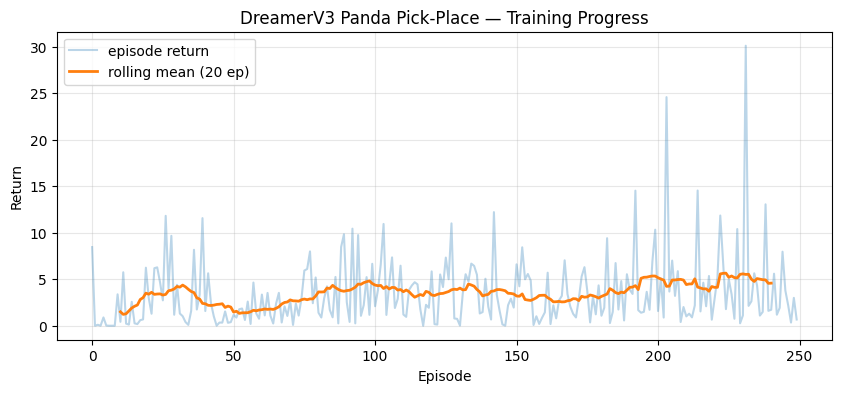

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

history = ckpt.get("ep_ret_history", [])
if history:
    y = np.array(history, dtype=np.float32)
    window = min(20, max(1, len(y)//4))
    smooth = np.convolve(y, np.ones(window)/window, mode='valid')
    plt.figure(figsize=(10,4))
    plt.plot(y, alpha=0.3, label='episode return')
    plt.plot(np.arange(len(smooth))+window//2, smooth, linewidth=2, label=f'rolling mean ({window} ep)')
    plt.xlabel('Episode'); plt.ylabel('Return'); plt.legend(); plt.grid(alpha=0.3)
    plt.title('DreamerV3 Panda Pick-Place — Training Progress')
    plt.show()
else:
    print("No episode history yet — train longer first.")

## 8 — Write the evaluation script

In [ ]:
%%writefile /content/dreamerv3_panda/scripts/dv3_common.py
"""
dv3_common.py — shared checkpoint loading for the DreamerV3 eval scripts.

Imports the network classes directly from train.py rather than redefining
them. This is deliberate: if the architecture in train.py changes, these
scripts follow automatically instead of silently loading a mismatched model.

Place this next to train.py (i.e. in scripts/).
"""

import os
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import sys
import copy
import yaml
from pathlib import Path

import numpy as np
import torch

# Locate train.py. __file__ is undefined when this module's contents are
# pasted into a notebook cell, so fall back to the working directory and a
# few conventional layouts.
def _find_train_dir():
    cands = []
    try:
        cands.append(Path(__file__).resolve().parent)
    except NameError:                      # notebook / exec() context
        pass
    cwd = Path.cwd()
    cands += [cwd, cwd / "scripts", cwd.parent, cwd.parent / "scripts",
              Path("/content/dreamerv3_panda/scripts"),
              Path("/content/dreamerv3_panda"),
              Path("/workspace/scripts"), Path("/workspace")]
    for d in cands:
        if (d / "train.py").exists():
            return d
    raise ImportError(
        "could not find train.py. Put dv3_common.py next to it, or run:\n"
        "    import sys; sys.path.insert(0, '/path/to/scripts')\n"
        f"searched: {[str(c) for c in cands]}")


_HERE = _find_train_dir()
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

# Core symbols. These exist in every revision of train.py; if any is missing
# the file is not a DreamerV3 training script and nothing below will work.
from train import (                      # noqa: E402
    ImageEncoder, VectorEncoder, ImageDecoder,
    RSSM, MLPHead, Actor, Critic, TwoHot,
    InstrumentedEnv, make_raw_env, ReplayBuffer,
    symlog, symexp, kl_categorical, unimix_logits,
)

import train as _train                   # noqa: E402
import torch.nn as _nn                   # noqa: E402
import torch.nn.functional as _F         # noqa: E402

_MISSING = []

# ── VectorDecoder: added in revision 2 ────────────────────────────────────
VectorDecoder = getattr(_train, "VectorDecoder", None)
if VectorDecoder is None:
    _MISSING.append("VectorDecoder")

    class VectorDecoder(_nn.Module):
        """
        Local fallback, identical to revision 2 of train.py. Defined here only
        so that checkpoints containing vec_decoder weights still load when the
        train.py on disk predates the fix.
        """

        def __init__(self, feat_dim, out_dim, layers=2, units=512):
            super().__init__()
            mods, d = [], feat_dim
            for _ in range(layers):
                mods += [_nn.Linear(d, units), _nn.LayerNorm(units), _nn.SiLU()]
                d = units
            self.trunk = _nn.Sequential(*mods)
            self.out = _nn.Linear(d, out_dim)

        def forward(self, z):
            x = z
            if not torch.isfinite(x).all():
                x = torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)
            return self.out(self.trunk(x))

# ── categorical_entropy: added in revision 2 ──────────────────────────────
categorical_entropy = getattr(_train, "categorical_entropy", None)
if categorical_entropy is None:
    _MISSING.append("categorical_entropy")

    def categorical_entropy(logits):
        """Mean per-latent entropy in nats. Max = log(classes)."""
        lp = _F.log_softmax(logits, -1)
        return -(lp.exp() * lp).sum(-1).mean()


def _report_train_version():
    """Tell the user which revision of train.py is on disk, and why it matters."""
    print(f"train.py : {Path(_train.__file__).resolve()}")
    if not _MISSING:
        print("  revision : 2 (recon-scale + discount fixes present)")
        return
    print(f"  revision : 1  -- missing {', '.join(_MISSING)}")
    print("  " + "!" * 66)
    print("  WARNING: this train.py PREDATES the reconstruction-scale and")
    print("  discount fixes. Evaluation will still work (the network")
    print("  architectures are identical between revisions), but if you")
    print("  RESUME TRAINING from this file you will re-introduce the")
    print("  posterior collapse. Restore the fixed train.py before training.")
    print("  " + "!" * 66)


_report_train_version()


# Bump when the shared API changes, so a stale copy of one script is caught
# immediately instead of surfacing as a confusing ImportError.
DV3_COMMON_VERSION = 3


def require_version(minimum, who):
    if DV3_COMMON_VERSION < minimum:
        raise SystemExit(
            f"\n{'='*68}\n"
            f"VERSION MISMATCH\n"
            f"  {who} needs dv3_common version >= {minimum}\n"
            f"  the dv3_common.py on disk is version {DV3_COMMON_VERSION}\n"
            f"  at: {__file__ if '__file__' in dir() else 'dv3_common.py'}\n\n"
            f"  Re-upload ALL of these together, they are one set:\n"
            f"    dv3_common.py\n    evaluate.py\n"
            f"    inspect_world_model.py\n    visualize_reconstruction.py\n"
            f"{'='*68}")


def load_config(path):
    with open(path) as f:
        return yaml.safe_load(f)


def pick_device(pref="auto"):
    if pref == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(pref)


def build_env(cfg):
    """Build the instrumented robosuite env exactly as training does."""
    return InstrumentedEnv(make_raw_env(cfg), cfg)


def build_nets(cfg, vec_dim, act_dim, device):
    """Reconstruct every module with the dimensions the checkpoint expects."""
    wm, ac = cfg["world_model"], cfg["actor_critic"]
    depth = wm["encoder_cnn_depth"]
    deter, stoch, classes = wm["rssm_deter"], wm["rssm_stoch"], wm["rssm_classes"]
    num_bins = wm.get("num_bins", 255)
    feat_dim = deter + stoch * classes

    enc_img = ImageEncoder(depth).to(device)
    enc_vec = VectorEncoder(vec_dim, 64,
                            wm.get("encoder_mlp_units", 256)).to(device)
    embed_dim = enc_img.out_dim + enc_vec.out_dim

    rssm = RSSM(deter, stoch, classes, embed_dim, act_dim,
                unimix=wm.get("unimix", 0.01)).to(device)
    decoder = ImageDecoder(feat_dim, depth).to(device)

    vec_decoder = None
    if wm.get("decode_vector", True):
        vec_decoder = VectorDecoder(
            feat_dim, vec_dim,
            layers=wm.get("vector_decoder_layers", 2),
            units=wm.get("vector_decoder_units", 512)).to(device)

    rew_head = MLPHead(feat_dim, num_bins,
                       layers=wm.get("reward_layers", 2),
                       units=wm.get("reward_units", 512),
                       zero_out=True).to(device)
    cont_head = MLPHead(feat_dim, 1,
                        layers=wm.get("continue_layers", 2),
                        units=wm.get("continue_units", 512)).to(device)
    actor = Actor(feat_dim, act_dim,
                  layers=ac.get("actor_layers", 3),
                  units=ac.get("actor_units", 512),
                  min_std=ac.get("actor_min_std", 0.1),
                  max_std=ac.get("actor_max_std", 1.0)).to(device)
    critic = Critic(feat_dim,
                    layers=ac.get("critic_layers", 3),
                    units=ac.get("critic_units", 512),
                    num_bins=num_bins).to(device)
    slow_critic = copy.deepcopy(critic).to(device)

    nets = dict(enc_img=enc_img, enc_vec=enc_vec, rssm=rssm, decoder=decoder,
                rew_head=rew_head, cont_head=cont_head,
                actor=actor, critic=critic, slow_critic=slow_critic)
    if vec_decoder is not None:
        nets["vec_decoder"] = vec_decoder

    twohot = TwoHot(num_bins=num_bins, device=device)
    return nets, twohot, feat_dim


def load_checkpoint(path, nets, device, strict=True):
    """
    Load weights. Reports every module explicitly — a silently skipped module
    is the difference between evaluating your agent and evaluating noise.
    """
    ck = torch.load(path, map_location=device, weights_only=False)
    saved = ck.get("models", {})
    print(f"\ncheckpoint : {path}")
    print(f"  step     : {ck.get('total_steps', '?'):,}"
          if isinstance(ck.get("total_steps"), int) else "  step     : ?")
    print(f"  saved at : {ck.get('saved_at', '?')}")
    print(f"  reason   : {ck.get('reason', '?')}")
    print("  modules:")

    missing = []
    for name, mod in nets.items():
        if name in saved:
            try:
                mod.load_state_dict(saved[name])
                print(f"    [ok]   {name}")
            except Exception as e:
                print(f"    [FAIL] {name}: {e}")
                missing.append(name)
        else:
            print(f"    [MISS] {name}  (not in checkpoint - RANDOM WEIGHTS)")
            missing.append(name)
        mod.eval()

    if missing and strict:
        core = {"enc_img", "enc_vec", "rssm", "actor"}
        if core & set(missing):
            raise RuntimeError(
                f"core modules failed to load: {sorted(core & set(missing))}. "
                "Evaluating this would be meaningless. Check that --config "
                "matches the config used for training.")
    print()
    return ck, missing


def setup(config_path, checkpoint_path, device_pref="auto", make_env=True):
    """One-call setup: config -> env -> nets -> weights loaded."""
    cfg = load_config(config_path)
    device = pick_device(device_pref)
    print(f"device: {device}")

    env = None
    if make_env:
        print("building environment...")
        env = build_env(cfg)
        obs = env.reset()
        vec_dim, act_dim = obs["vector"].shape[0], env.act_dim
    else:
        # infer dims from the checkpoint itself (no simulator needed)
        ck = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
        w = ck["models"]["enc_vec"]
        vec_dim = next(v for k, v in w.items()
                       if k.endswith("0.weight")).shape[1]
        w = ck["models"]["rssm"]
        lat = cfg["world_model"]["rssm_stoch"] * cfg["world_model"]["rssm_classes"]
        act_dim = w["gru_in.weight"].shape[1] - lat
        del ck

    print(f"vec_dim={vec_dim}  act_dim={act_dim}")
    nets, twohot, feat_dim = build_nets(cfg, vec_dim, act_dim, device)
    ck, missing = load_checkpoint(checkpoint_path, nets, device)
    return dict(cfg=cfg, device=device, env=env, nets=nets, twohot=twohot,
                feat_dim=feat_dim, vec_dim=vec_dim, act_dim=act_dim,
                ckpt=ck, missing=missing)


# ══════════════════════════════════════════════════════════════════════════
# Shared sequence gathering + RSSM unrolling
#
# These live here rather than in one of the eval scripts so that every script
# uses the same definitions and none of them depend on importing another
# script by filename.
# ══════════════════════════════════════════════════════════════════════════

def chw(x):
    return np.transpose(x, (1, 2, 0))


def seqs_from_buffer(path, n_seq, seq_len, seed=0):
    """Pull contiguous windows out of the saved replay buffer."""
    z = np.load(path, allow_pickle=False)
    imgs, vecs, acts = z["imgs"], z["vecs"], z["acts"]
    rews, dones = z["rews"], z["dones"]
    N = len(imgs)
    if N < seq_len + 1:
        raise SystemExit(f"buffer has only {N} transitions, need >{seq_len}")
    rng = np.random.default_rng(seed)

    # Prefer windows that contain some reward — a window of pure idle frames
    # tells you nothing about whether the model tracks anything interesting.
    starts, tries = [], 0
    while len(starts) < n_seq and tries < 2000:
        i = int(rng.integers(0, N - seq_len - 1))
        tries += 1
        if not dones[i:i + seq_len].any():
            w = rews[i:i + seq_len]
            if w.max() > 1e-4 or len(starts) < n_seq // 2:
                starts.append(i)
    while len(starts) < n_seq:                      # fall back to anything
        starts.append(int(rng.integers(0, N - seq_len - 1)))

    out = []
    for i in starts:
        out.append(dict(
            imgs=imgs[i:i + seq_len], vecs=vecs[i:i + seq_len],
            acts=acts[i:i + seq_len], rews=rews[i:i + seq_len]))
    print(f"  {len(out)} sequences of length {seq_len} from {N:,} transitions")
    return out


@torch.no_grad()
def seqs_from_env(env, nets, device, n_seq, seq_len, policy="agent"):
    """Collect fresh sequences by driving the live simulator."""
    enc_img, enc_vec = nets["enc_img"], nets["enc_vec"]
    rssm, actor = nets["rssm"], nets["actor"]
    out = []
    for _ in range(n_seq):
        obs = env.reset()
        h, s = rssm.init_state(1, device)
        prev_a = torch.zeros(1, env.act_dim, device=device)
        I, V, A, R = [], [], [], []
        for _ in range(seq_len):
            it = torch.from_numpy(obs["image"]).unsqueeze(0).to(device)
            vt = torch.from_numpy(obs["vector"]).unsqueeze(0).to(device)
            emb = torch.cat([enc_img(it), enc_vec(vt)], -1)
            h, s, _, _ = rssm.obs_step(h, s, prev_a, emb)
            if policy == "random":
                a = env.sample_action()
            else:
                a = actor.act(rssm.feat(h, s), deterministic=True
                              ).squeeze(0).cpu().numpy()
                a = np.clip(a, -1, 1).astype(np.float32)
            I.append(obs["image"]); V.append(obs["vector"]); A.append(a)
            obs, r, done, _ = env.step(a)
            R.append(r)
            prev_a = torch.from_numpy(np.asarray(a, np.float32)
                                      ).unsqueeze(0).to(device)
            if done:
                break
        if len(I) == seq_len:
            out.append(dict(imgs=np.stack(I), vecs=np.stack(V),
                            acts=np.stack(A), rews=np.array(R, np.float32)))
    print(f"  collected {len(out)} live sequences")
    return out


@torch.no_grad()
def unroll(seq, nets, twohot, device, context):
    """
    Returns everything both plots need.

    Posterior pass: obs_step at every step (camera always available).
    Open-loop pass: obs_step for the first `context` steps, then img_step
                    only — no camera — for the remainder.
    """
    enc_img, enc_vec = nets["enc_img"], nets["enc_vec"]
    rssm, decoder, rew_head = nets["rssm"], nets["decoder"], nets["rew_head"]

    imgs = torch.from_numpy(seq["imgs"]).to(device)               # (T,3,64,64)
    vecs = torch.from_numpy(seq["vecs"]).float().to(device)
    acts = torch.from_numpy(seq["acts"]).float().to(device)
    T = imgs.shape[0]

    embed = torch.cat([enc_img(imgs), enc_vec(vecs)], -1)         # (T,E)

    # ---- posterior (teacher forced) ----
    h, s = rssm.init_state(1, device)
    post_feats, priors, posts = [], [], []
    for t in range(T):
        pa = torch.zeros(1, acts.shape[-1], device=device) if t == 0 \
            else acts[t - 1:t]
        h, s, prior, post = rssm.obs_step(h, s, pa, embed[t:t + 1])
        post_feats.append(rssm.feat(h, s))
        priors.append(prior); posts.append(post)
    post_feats = torch.cat(post_feats, 0)
    priors = torch.cat(priors, 0).unsqueeze(0)
    posts = torch.cat(posts, 0).unsqueeze(0)

    # ---- open loop: context frames observed, then dream ----
    h, s = rssm.init_state(1, device)
    ol_feats = []
    for t in range(T):
        pa = torch.zeros(1, acts.shape[-1], device=device) if t == 0 \
            else acts[t - 1:t]
        if t < context:
            h, s, _, _ = rssm.obs_step(h, s, pa, embed[t:t + 1])
        else:
            h, s = rssm.img_step(h, s, pa)      # NO camera from here on
        ol_feats.append(rssm.feat(h, s))
    ol_feats = torch.cat(ol_feats, 0)

    tgt = imgs.float() / 255.0
    rec_post = decoder(post_feats).clamp(0, 1)
    rec_ol = decoder(ol_feats).clamp(0, 1)

    mse_post = ((rec_post - tgt) ** 2).mean(dim=(1, 2, 3))
    mse_ol = ((rec_ol - tgt) ** 2).mean(dim=(1, 2, 3))

    kl = kl_categorical(unimix_logits(posts, 0.01),
                        unimix_logits(priors, 0.01)).mean()

    return dict(
        target=tgt.cpu().numpy(),
        rec_post=rec_post.cpu().numpy(),
        rec_ol=rec_ol.cpu().numpy(),
        mse_post=mse_post.cpu().numpy(),
        mse_ol=mse_ol.cpu().numpy(),
        rew_true=seq["rews"],
        rew_post=twohot.mean(rew_head(post_feats)).cpu().numpy(),
        rew_ol=twohot.mean(rew_head(ol_feats)).cpu().numpy(),
        kl=float(kl),
        post_ent=float(categorical_entropy(posts.float())),
        prior_ent=float(categorical_entropy(priors.float())),
        tgt_tstd=float(tgt.reshape(T, -1).std(0).mean()),
        post_tstd=float(rec_post.reshape(T, -1).std(0).mean()),
        ol_tstd=float(rec_ol.reshape(T, -1).std(0).mean()),
        context=context,
    )

Writing /content/dreamerv3_panda/scripts/dv3_common.py


In [ ]:
%%writefile /content/dreamerv3_panda/scripts/evaluate.py
"""
evaluate.py — run a trained DreamerV3 checkpoint and measure what it can do.

Reports per-stage success rates (reach / grasp / lift / place), minimum
distance to the object, and episode returns — and, critically, compares
against a uniform-random baseline run in the same session.

The baseline is not optional garnish. "Return 1.2" means nothing on its own;
"return 1.2 vs random 0.9" means something. In the current PickPlaceCan run
the policy has at times been WORSE than random, and only a side-by-side
comparison makes that visible.

Usage
-----
    python scripts/evaluate.py \
        --config configs/panda_pickplace_colab.yaml \
        --checkpoint checkpoints/latest.pt \
        --episodes 20

    # skip the baseline (twice as fast)
    python scripts/evaluate.py ... --no_baseline

    # sample from the policy instead of taking the mean
    python scripts/evaluate.py ... --stochastic

    # save videos of the first 3 episodes
    python scripts/evaluate.py ... --video eval_videos/

    # sweep every checkpoint in a directory
    python scripts/evaluate.py ... --checkpoint checkpoints/ --sweep
"""

import argparse
import csv
import json
import math
import time
from pathlib import Path

import numpy as np
import torch

from dv3_common import setup, require_version, pick_device


require_version(3, "evaluate.py")


# ══════════════════════════════════════════════════════════════════════════
# Rollout
# ══════════════════════════════════════════════════════════════════════════

def grab_frame(env, camera, h=256, w=256):
    """
    Render from the simulator at full resolution rather than reusing the 64x64
    policy observation. env is the InstrumentedEnv wrapper, so the raw
    robosuite env (and its sim) is env.env.
    """
    try:
        f = env.env.sim.render(height=h, width=w, camera_name=camera)
        return np.flipud(f).copy()
    except Exception:
        return None


@torch.no_grad()
def run_episode(env, nets, device, policy="agent", deterministic=True,
                collect_frames=False, max_steps=None,
                camera="agentview", render_size=256):
    """
    One episode. policy='agent' uses the actor; policy='random' uses uniform
    actions, giving the baseline every comparison needs.

    The RSSM latent (h, s) is carried forward exactly as in training: the
    action that led INTO the current observation is fed to obs_step.
    """
    enc_img, enc_vec = nets["enc_img"], nets["enc_vec"]
    rssm, actor = nets["rssm"], nets["actor"]

    obs = env.reset()
    h, s = rssm.init_state(1, device)
    prev_a = torch.zeros(1, env.act_dim, device=device)

    ep_ret, steps, done = 0.0, 0, False
    frames, dists, rewards, gripper_cmds = [], [], [], []

    while not done:
        it = torch.from_numpy(obs["image"]).unsqueeze(0).to(device)
        vt = torch.from_numpy(obs["vector"]).unsqueeze(0).to(device)
        emb = torch.cat([enc_img(it), enc_vec(vt)], -1)
        h, s, _, _ = rssm.obs_step(h, s, prev_a, emb)

        if policy == "random":
            a = env.sample_action()
        else:
            a = actor.act(rssm.feat(h, s),
                          deterministic=deterministic).squeeze(0).cpu().numpy()
            a = np.clip(a, -1, 1).astype(np.float32)

        if collect_frames:
            f = grab_frame(env, camera, render_size, render_size)
            if f is None:                      # fall back to the 64x64 obs
                f = obs["image"].transpose(1, 2, 0).copy()
            frames.append(f)

        obs, r, done, _ = env.step(a)
        m = env.metrics()
        if math.isfinite(m["dist"]) and m["dist"] >= 0:
            dists.append(m["dist"])
        rewards.append(r)
        gripper_cmds.append(float(a[-1]))

        prev_a = torch.from_numpy(np.asarray(a, np.float32)
                                  ).unsqueeze(0).to(device)
        ep_ret += r
        steps += 1
        if max_steps and steps >= max_steps:
            break

    summ = env.episode_summary()
    summ.update(ret=ep_ret, steps=steps,
                mean_reward=float(np.mean(rewards)) if rewards else 0.0,
                max_reward=float(np.max(rewards)) if rewards else 0.0,
                gripper_mean=float(np.mean(gripper_cmds)),
                gripper_close_pct=float(np.mean(np.array(gripper_cmds) > 0.5)),
                frames=frames)
    return summ


def aggregate(results):
    """Summarise a list of episode dicts, with binomial CIs on the rates."""
    n = len(results)
    out = {"episodes": n}
    for stage in ("reach", "grasp", "lift", "place"):
        k = sum(int(r[stage]) for r in results)
        p = k / n if n else 0.0
        # Wilson-ish half width; wide when k is small, which is the point
        se = math.sqrt(max(p * (1 - p), 1e-9) / n) if n else 0.0
        out[f"{stage}_rate"] = 100 * p
        out[f"{stage}_count"] = k
        out[f"{stage}_ci95"] = 100 * 1.96 * se
    rets = [r["ret"] for r in results]
    out["return_mean"] = float(np.mean(rets))
    out["return_std"] = float(np.std(rets))
    out["return_min"] = float(np.min(rets))
    out["return_max"] = float(np.max(rets))
    ds = [r["min_dist"] for r in results if r["min_dist"] >= 0]
    out["min_dist_mean"] = float(np.mean(ds)) if ds else -1.0
    out["min_dist_best"] = float(np.min(ds)) if ds else -1.0
    out["steps_mean"] = float(np.mean([r["steps"] for r in results]))
    out["max_reward_seen"] = float(np.max([r["max_reward"] for r in results]))
    out["gripper_close_pct"] = 100 * float(
        np.mean([r["gripper_close_pct"] for r in results]))
    return out


def print_block(title, a):
    print(f"\n  {title}")
    print(f"    episodes          {a['episodes']}")
    for st in ("reach", "grasp", "lift", "place"):
        print(f"    {st+'_rate':<17} {a[st+'_rate']:6.1f}%  "
              f"+-{a[st+'_ci95']:.1f}   ({a[st+'_count']}/{a['episodes']})")
    print(f"    return            {a['return_mean']:7.3f} +- {a['return_std']:.3f}"
          f"   [{a['return_min']:.3f}, {a['return_max']:.3f}]")
    print(f"    min_dist mean     {a['min_dist_mean']:7.4f} m"
          f"   best {a['min_dist_best']:.4f} m")
    print(f"    max reward seen   {a['max_reward_seen']:7.4f}")
    print(f"    gripper closing   {a['gripper_close_pct']:6.1f}% of steps")


def save_video(frames, path, fps=20):
    try:
        import imageio
    except ImportError:
        print("  (pip install imageio imageio-ffmpeg to save videos)")
        return
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    try:
        w = imageio.get_writer(str(path), fps=fps, codec="libx264",
                               quality=8, macro_block_size=1)
        for f in frames:
            w.append_data(f)
        w.close()
        mb = Path(path).stat().st_size / 1e6
        print(f"  video -> {path}  ({len(frames)} frames, {mb:.1f} MB)")
    except Exception as e:
        gif = str(Path(path).with_suffix(".gif"))
        imageio.mimsave(gif, frames, duration=1.0 / fps)
        print(f"  mp4 failed ({e}); gif -> {gif}")


# ══════════════════════════════════════════════════════════════════════════
# Checkpoint discovery (W&B artifacts are all named latest.pt)
# ══════════════════════════════════════════════════════════════════════════

def ckpt_step(path):
    """Read total_steps out of a checkpoint without keeping it in memory."""
    try:
        ck = torch.load(path, map_location="cpu", weights_only=False)
        n = ck.get("total_steps", -1)
        del ck
        return int(n) if isinstance(n, (int, float)) else -1
    except Exception:
        return -1


def resolve_checkpoint_path(given, cfg):
    """
    Accept a bare filename and still find it. Tries, in order: the path as
    given, then the same name inside the config's checkpoint_dir, then a
    couple of conventional layouts. Falls back to checkpoint_dir/latest.pt
    when nothing was given at all.
    """
    ckdir = Path(cfg.get("logging", {}).get("checkpoint_dir", "checkpoints"))
    if given is None:
        cands = [ckdir / "latest.pt", Path("checkpoints/latest.pt")]
    else:
        g = Path(given)
        cands = [g, ckdir / g.name, ckdir / g, Path("checkpoints") / g.name]
    for c in cands:
        if c.exists():
            if str(c) != str(given):
                print(f"resolved checkpoint: {given} -> {c}")
            return c
    raise SystemExit(
        f"checkpoint not found. tried:\n  " +
        "\n  ".join(str(c.resolve()) for c in cands) +
        f"\n(cwd is {Path.cwd()})")


def discover_checkpoints(root, sweep):
    """
    Accepts a .pt file, or a directory.

    W&B artifact downloads all land as <something>/latest.pt, so globbing by
    filename would collapse them into one. Instead every .pt under the tree is
    collected and sorted by the step recorded INSIDE the file.
    """
    root = Path(root)
    if root.is_file():
        return [root]
    if not root.is_dir():
        raise SystemExit(f"not found: {root}")

    found = sorted({p.resolve() for p in root.rglob("*.pt")
                    if not p.name.endswith(".tmp")})
    if not found:
        raise SystemExit(f"no .pt files under {root}")

    if not sweep:
        # single-checkpoint mode: prefer an explicit latest.pt at the top
        top = root / "latest.pt"
        return [top] if top.exists() else [found[-1]]

    print(f"reading step numbers from {len(found)} checkpoint(s)...")
    pairs = []
    for p in found:
        st = ckpt_step(p)
        pairs.append((st, p))
        print(f"  step {st:>10,}  {p}")
    pairs.sort(key=lambda x: (x[0], str(x[1])))
    return [p for _, p in pairs]


def fetch_wandb(artifact, all_versions=False, root="wandb_ckpts"):
    """
    Download checkpoint artifact(s) logged by train.py.

    train.py logs them as  dv3-panda-<run_id>  with aliases 'latest' and
    'step-<N>', so:
        --wandb_artifact entity/project/dv3-panda-abc123:latest
        --wandb_artifact entity/project/dv3-panda-abc123:step-15000
        --wandb_artifact entity/project/dv3-panda-abc123 --wandb_all
    """
    try:
        import wandb
    except ImportError:
        raise SystemExit("pip install wandb to use --wandb_artifact")

    api = wandb.Api()
    Path(root).mkdir(parents=True, exist_ok=True)
    out = []

    if all_versions:
        name = artifact.split(":")[0]
        print(f"listing versions of {name} ...")
        try:
            versions = list(api.artifact_versions("model", name))
        except Exception as e:
            raise SystemExit(f"could not list versions: {e}")
        print(f"  {len(versions)} version(s)")
        for v in versions:
            step = (v.metadata or {}).get("step", "?")
            d = Path(v.download(root=str(Path(root) / v.version)))
            f = d / "latest.pt"
            if f.exists():
                out.append(f)
                print(f"  {v.version:>6}  step {step}  -> {f}")
    else:
        art = api.artifact(artifact, type="model")
        d = Path(art.download(root=str(Path(root) / art.version)))
        f = d / "latest.pt"
        if not f.exists():
            cands = list(d.glob("*.pt"))
            if not cands:
                raise SystemExit(f"no .pt inside artifact {artifact}")
            f = cands[0]
        out.append(f)
        print(f"downloaded {artifact} -> {f}")
    return out


# ══════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════

def evaluate_one(ckpt_path, args):
    S = setup(args.config, ckpt_path, args.device, make_env=True)
    env, nets, device = S["env"], S["nets"], S["device"]

    torch.manual_seed(args.seed)
    np.random.seed(args.seed)

    print(f"policy: {'stochastic sample' if args.stochastic else 'deterministic mean'}")
    print(f"running {args.episodes} agent episodes...")

    agent_eps, t0 = [], time.time()
    for i in range(args.episodes):
        want_video = args.video and i < args.video_count
        r = run_episode(env, nets, device, policy="agent",
                        deterministic=not args.stochastic,
                        collect_frames=want_video,
                        camera=S["cfg"]["env"]["camera"],
                        render_size=args.render_size)
        if want_video:
            save_video(r.pop("frames"),
                       str(Path(args.video) / f"agent_ep{i:02d}.mp4"),
                       fps=S["cfg"]["env"]["control_freq"])
        r.pop("frames", None)
        agent_eps.append(r)
        print(f"  ep {i:>3}  ret={r['ret']:7.3f}  stage={r['stage']:<5} "
              f"d={r['min_dist']:.4f}  steps={r['steps']}", flush=True)

    base_eps = []
    if not args.no_baseline:
        print(f"\nrunning {args.episodes} RANDOM baseline episodes...")
        for i in range(args.episodes):
            r = run_episode(env, nets, device, policy="random")
            r.pop("frames", None)
            base_eps.append(r)
            print(f"  ep {i:>3}  ret={r['ret']:7.3f}  stage={r['stage']:<5} "
                  f"d={r['min_dist']:.4f}", flush=True)

    a_agg = aggregate(agent_eps)
    print("\n" + "=" * 68)
    print(f"RESULTS  ({time.time()-t0:.0f}s)")
    print("=" * 68)
    print_block("AGENT", a_agg)

    b_agg = None
    if base_eps:
        b_agg = aggregate(base_eps)
        print_block("RANDOM BASELINE", b_agg)

        dr = a_agg["return_mean"] - b_agg["return_mean"]
        dd = b_agg["min_dist_mean"] - a_agg["min_dist_mean"]
        print("\n  VERDICT")
        print(f"    return   agent - random = {dr:+.4f}")
        print(f"    min_dist random - agent = {dd:+.4f} m  (positive = closer)")
        if dr <= 0 and dd <= 0:
            print("    -> the policy is NOT beating uniform random. "
                  "More steps will not fix this by itself.")
        elif dd > 0.02 and a_agg["grasp_rate"] == 0:
            print("    -> reaching has improved over random, but zero grasps. "
                  "This is the exploration wall, not a training bug.")
        elif a_agg["grasp_rate"] > 0:
            print("    -> GRASPS OCCURRING. The reward head now has signal "
                  "to learn from. Keep training.")
        else:
            print("    -> mixed. Check min_dist trend across checkpoints.")

    if a_agg["gripper_close_pct"] < 5:
        print("\n  WARNING: gripper commands a close on "
              f"{a_agg['gripper_close_pct']:.1f}% of steps. If the arm is "
              "reaching but never grasping, the gripper may simply not be "
              "actuating - check actor_max_std / entropy settings.")

    env.close()
    return dict(checkpoint=str(ckpt_path),
                step=S["ckpt"].get("total_steps", -1),
                agent=a_agg, random=b_agg)


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--checkpoint", default=None,
                   help="a .pt file, or a directory (searched recursively)")
    p.add_argument("--wandb_artifact", default=None,
                   help="e.g. entity/project/dv3-panda-<runid>:latest")
    p.add_argument("--wandb_all", action="store_true",
                   help="with --wandb_artifact: download every version")
    p.add_argument("--episodes", type=int, default=20)
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--stochastic", action="store_true",
                   help="sample actions instead of using the mean")
    p.add_argument("--no_baseline", action="store_true")
    p.add_argument("--video", default=None, help="directory for episode videos")
    p.add_argument("--video_count", type=int, default=3)
    p.add_argument("--render_size", type=int, default=256,
                   help="simulator render resolution for videos")
    p.add_argument("--sweep", action="store_true",
                   help="evaluate every checkpoint found, oldest first")
    p.add_argument("--out", default="eval_results.json")
    args, _ = p.parse_known_args()  # tolerate notebook argv noise

    if args.wandb_artifact:
        paths = fetch_wandb(args.wandb_artifact, args.wandb_all)
        if args.wandb_all:
            paths.sort(key=ckpt_step)
        args.sweep = args.sweep or len(paths) > 1
    else:
        cfg = __import__("yaml").safe_load(open(args.config))
        if args.checkpoint and Path(args.checkpoint).is_dir():
            paths = discover_checkpoints(args.checkpoint, args.sweep)
        else:
            paths = [resolve_checkpoint_path(args.checkpoint, cfg)]

    print(f"\nevaluating {len(paths)} checkpoint(s)")

    all_res = []
    for pth in paths:
        all_res.append(evaluate_one(pth, args))

    Path(args.out).write_text(json.dumps(all_res, indent=2))
    print(f"\nwrote {args.out}")

    if len(all_res) > 1:
        print("\nsweep summary")
        print(f"  {'step':>10} {'return':>9} {'reach%':>8} {'grasp%':>8} {'min_d':>8}")
        for r in all_res:
            a = r["agent"]
            print(f"  {r['step']:>10,} {a['return_mean']:>9.3f} "
                  f"{a['reach_rate']:>8.1f} {a['grasp_rate']:>8.1f} "
                  f"{a['min_dist_mean']:>8.4f}")
        csv_path = Path(args.out).with_suffix(".csv")
        with open(csv_path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["step", "return_mean", "return_std", "reach_rate",
                        "grasp_rate", "lift_rate", "place_rate",
                        "min_dist_mean", "min_dist_best"])
            for r in all_res:
                a = r["agent"]
                w.writerow([r["step"], a["return_mean"], a["return_std"],
                            a["reach_rate"], a["grasp_rate"], a["lift_rate"],
                            a["place_rate"], a["min_dist_mean"],
                            a["min_dist_best"]])
        print(f"  wrote {csv_path}")


if __name__ == "__main__":
    main()

Writing /content/dreamerv3_panda/scripts/evaluate.py


In [ ]:
%%writefile /content/dreamerv3_panda/scripts/evaluate.py
"""
evaluate.py — run a trained DreamerV3 checkpoint and measure what it can do.

Reports per-stage success rates (reach / grasp / lift / place), minimum
distance to the object, and episode returns — and, critically, compares
against a uniform-random baseline run in the same session.

The baseline is not optional garnish. "Return 1.2" means nothing on its own;
"return 1.2 vs random 0.9" means something. In the current PickPlaceCan run
the policy has at times been WORSE than random, and only a side-by-side
comparison makes that visible.

Usage
-----
    python scripts/evaluate.py \
        --config configs/panda_pickplace_colab.yaml \
        --checkpoint checkpoints/latest.pt \
        --episodes 20

    # skip the baseline (twice as fast)
    python scripts/evaluate.py ... --no_baseline

    # sample from the policy instead of taking the mean
    python scripts/evaluate.py ... --stochastic

    # save a video of EVERY episode (the default when --video is given)
    python scripts/evaluate.py ... --video eval_videos/

    # only the first 3
    python scripts/evaluate.py ... --video eval_videos/ --video_count 3

    # plus one concatenated reel of all of them
    python scripts/evaluate.py ... --video eval_videos/ --video_reel

    # sweep every checkpoint in a directory
    python scripts/evaluate.py ... --checkpoint checkpoints/ --sweep
"""

import argparse
import csv
import json
import math
import time
from pathlib import Path

import numpy as np
import torch

from dv3_common import setup, require_version, pick_device


require_version(3, "evaluate.py")


# ══════════════════════════════════════════════════════════════════════════
# Rollout
# ══════════════════════════════════════════════════════════════════════════

def grab_frame(env, camera, h=256, w=256):
    """
    Render from the simulator at full resolution rather than reusing the 64x64
    policy observation. env is the InstrumentedEnv wrapper, so the raw
    robosuite env (and its sim) is env.env.
    """
    try:
        f = env.env.sim.render(height=h, width=w, camera_name=camera)
        return np.flipud(f).copy()
    except Exception:
        return None


@torch.no_grad()
def run_episode(env, nets, device, policy="agent", deterministic=True,
                collect_frames=False, max_steps=None,
                camera="agentview", render_size=256):
    """
    One episode. policy='agent' uses the actor; policy='random' uses uniform
    actions, giving the baseline every comparison needs.

    The RSSM latent (h, s) is carried forward exactly as in training: the
    action that led INTO the current observation is fed to obs_step.
    """
    enc_img, enc_vec = nets["enc_img"], nets["enc_vec"]
    rssm, actor = nets["rssm"], nets["actor"]

    obs = env.reset()
    h, s = rssm.init_state(1, device)
    prev_a = torch.zeros(1, env.act_dim, device=device)

    ep_ret, steps, done = 0.0, 0, False
    frames, dists, rewards, gripper_cmds = [], [], [], []

    while not done:
        it = torch.from_numpy(obs["image"]).unsqueeze(0).to(device)
        vt = torch.from_numpy(obs["vector"]).unsqueeze(0).to(device)
        emb = torch.cat([enc_img(it), enc_vec(vt)], -1)
        h, s, _, _ = rssm.obs_step(h, s, prev_a, emb)

        if policy == "random":
            a = env.sample_action()
        else:
            a = actor.act(rssm.feat(h, s),
                          deterministic=deterministic).squeeze(0).cpu().numpy()
            a = np.clip(a, -1, 1).astype(np.float32)

        if collect_frames:
            f = grab_frame(env, camera, render_size, render_size)
            if f is None:                      # fall back to the 64x64 obs
                f = obs["image"].transpose(1, 2, 0).copy()
            frames.append(f)

        obs, r, done, _ = env.step(a)
        m = env.metrics()
        if math.isfinite(m["dist"]) and m["dist"] >= 0:
            dists.append(m["dist"])
        rewards.append(r)
        gripper_cmds.append(float(a[-1]))

        prev_a = torch.from_numpy(np.asarray(a, np.float32)
                                  ).unsqueeze(0).to(device)
        ep_ret += r
        steps += 1
        if max_steps and steps >= max_steps:
            break

    summ = env.episode_summary()
    summ.update(ret=ep_ret, steps=steps,
                mean_reward=float(np.mean(rewards)) if rewards else 0.0,
                max_reward=float(np.max(rewards)) if rewards else 0.0,
                gripper_mean=float(np.mean(gripper_cmds)),
                gripper_close_pct=float(np.mean(np.array(gripper_cmds) > 0.5)),
                frames=frames)
    return summ


def aggregate(results):
    """Summarise a list of episode dicts, with binomial CIs on the rates."""
    n = len(results)
    out = {"episodes": n}
    for stage in ("reach", "grasp", "lift", "place"):
        k = sum(int(r[stage]) for r in results)
        p = k / n if n else 0.0
        # Wilson-ish half width; wide when k is small, which is the point
        se = math.sqrt(max(p * (1 - p), 1e-9) / n) if n else 0.0
        out[f"{stage}_rate"] = 100 * p
        out[f"{stage}_count"] = k
        out[f"{stage}_ci95"] = 100 * 1.96 * se
    rets = [r["ret"] for r in results]
    out["return_mean"] = float(np.mean(rets))
    out["return_std"] = float(np.std(rets))
    out["return_min"] = float(np.min(rets))
    out["return_max"] = float(np.max(rets))
    ds = [r["min_dist"] for r in results if r["min_dist"] >= 0]
    out["min_dist_mean"] = float(np.mean(ds)) if ds else -1.0
    out["min_dist_best"] = float(np.min(ds)) if ds else -1.0
    out["steps_mean"] = float(np.mean([r["steps"] for r in results]))
    out["max_reward_seen"] = float(np.max([r["max_reward"] for r in results]))
    out["gripper_close_pct"] = 100 * float(
        np.mean([r["gripper_close_pct"] for r in results]))
    return out


def print_block(title, a):
    print(f"\n  {title}")
    print(f"    episodes          {a['episodes']}")
    for st in ("reach", "grasp", "lift", "place"):
        print(f"    {st+'_rate':<17} {a[st+'_rate']:6.1f}%  "
              f"+-{a[st+'_ci95']:.1f}   ({a[st+'_count']}/{a['episodes']})")
    print(f"    return            {a['return_mean']:7.3f} +- {a['return_std']:.3f}"
          f"   [{a['return_min']:.3f}, {a['return_max']:.3f}]")
    print(f"    min_dist mean     {a['min_dist_mean']:7.4f} m"
          f"   best {a['min_dist_best']:.4f} m")
    print(f"    max reward seen   {a['max_reward_seen']:7.4f}")
    print(f"    gripper closing   {a['gripper_close_pct']:6.1f}% of steps")


def save_video(frames, path, fps=20):
    try:
        import imageio
    except ImportError:
        print("  (pip install imageio imageio-ffmpeg to save videos)")
        return
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    try:
        w = imageio.get_writer(str(path), fps=fps, codec="libx264",
                               quality=8, macro_block_size=1)
        for f in frames:
            w.append_data(f)
        w.close()
        mb = Path(path).stat().st_size / 1e6
        print(f"  video -> {path}  ({len(frames)} frames, {mb:.1f} MB)")
    except Exception as e:
        gif = str(Path(path).with_suffix(".gif"))
        imageio.mimsave(gif, frames, duration=1.0 / fps)
        print(f"  mp4 failed ({e}); gif -> {gif}")


# ══════════════════════════════════════════════════════════════════════════
# Checkpoint discovery (W&B artifacts are all named latest.pt)
# ══════════════════════════════════════════════════════════════════════════

def ckpt_step(path):
    """Read total_steps out of a checkpoint without keeping it in memory."""
    try:
        ck = torch.load(path, map_location="cpu", weights_only=False)
        n = ck.get("total_steps", -1)
        del ck
        return int(n) if isinstance(n, (int, float)) else -1
    except Exception:
        return -1


def resolve_checkpoint_path(given, cfg):
    """
    Accept a bare filename and still find it. Tries, in order: the path as
    given, then the same name inside the config's checkpoint_dir, then a
    couple of conventional layouts. Falls back to checkpoint_dir/latest.pt
    when nothing was given at all.
    """
    ckdir = Path(cfg.get("logging", {}).get("checkpoint_dir", "checkpoints"))
    if given is None:
        cands = [ckdir / "latest.pt", Path("checkpoints/latest.pt")]
    else:
        g = Path(given)
        cands = [g, ckdir / g.name, ckdir / g, Path("checkpoints") / g.name]
    for c in cands:
        if c.exists():
            if str(c) != str(given):
                print(f"resolved checkpoint: {given} -> {c}")
            return c
    raise SystemExit(
        f"checkpoint not found. tried:\n  " +
        "\n  ".join(str(c.resolve()) for c in cands) +
        f"\n(cwd is {Path.cwd()})")


def discover_checkpoints(root, sweep):
    """
    Accepts a .pt file, or a directory.

    W&B artifact downloads all land as <something>/latest.pt, so globbing by
    filename would collapse them into one. Instead every .pt under the tree is
    collected and sorted by the step recorded INSIDE the file.
    """
    root = Path(root)
    if root.is_file():
        return [root]
    if not root.is_dir():
        raise SystemExit(f"not found: {root}")

    found = sorted({p.resolve() for p in root.rglob("*.pt")
                    if not p.name.endswith(".tmp")})
    if not found:
        raise SystemExit(f"no .pt files under {root}")

    if not sweep:
        # single-checkpoint mode: prefer an explicit latest.pt at the top
        top = root / "latest.pt"
        return [top] if top.exists() else [found[-1]]

    print(f"reading step numbers from {len(found)} checkpoint(s)...")
    pairs = []
    for p in found:
        st = ckpt_step(p)
        pairs.append((st, p))
        print(f"  step {st:>10,}  {p}")
    pairs.sort(key=lambda x: (x[0], str(x[1])))
    return [p for _, p in pairs]


def fetch_wandb(artifact, all_versions=False, root="wandb_ckpts"):
    """
    Download checkpoint artifact(s) logged by train.py.

    train.py logs them as  dv3-panda-<run_id>  with aliases 'latest' and
    'step-<N>', so:
        --wandb_artifact entity/project/dv3-panda-abc123:latest
        --wandb_artifact entity/project/dv3-panda-abc123:step-15000
        --wandb_artifact entity/project/dv3-panda-abc123 --wandb_all
    """
    try:
        import wandb
    except ImportError:
        raise SystemExit("pip install wandb to use --wandb_artifact")

    api = wandb.Api()
    Path(root).mkdir(parents=True, exist_ok=True)
    out = []

    if all_versions:
        name = artifact.split(":")[0]
        print(f"listing versions of {name} ...")
        try:
            versions = list(api.artifact_versions("model", name))
        except Exception as e:
            raise SystemExit(f"could not list versions: {e}")
        print(f"  {len(versions)} version(s)")
        for v in versions:
            step = (v.metadata or {}).get("step", "?")
            d = Path(v.download(root=str(Path(root) / v.version)))
            f = d / "latest.pt"
            if f.exists():
                out.append(f)
                print(f"  {v.version:>6}  step {step}  -> {f}")
    else:
        art = api.artifact(artifact, type="model")
        d = Path(art.download(root=str(Path(root) / art.version)))
        f = d / "latest.pt"
        if not f.exists():
            cands = list(d.glob("*.pt"))
            if not cands:
                raise SystemExit(f"no .pt inside artifact {artifact}")
            f = cands[0]
        out.append(f)
        print(f"downloaded {artifact} -> {f}")
    return out


# ══════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════

def evaluate_one(ckpt_path, args):
    S = setup(args.config, ckpt_path, args.device, make_env=True)
    env, nets, device = S["env"], S["nets"], S["device"]

    torch.manual_seed(args.seed)
    np.random.seed(args.seed)

    print(f"policy: {'stochastic sample' if args.stochastic else 'deterministic mean'}")
    print(f"running {args.episodes} agent episodes...")

    agent_eps, all_frames, t0 = [], [], time.time()
    for i in range(args.episodes):
        # video_count <= 0 means "every episode" (the default)
        want_video = bool(args.video) and (args.video_count <= 0
                                           or i < args.video_count)
        r = run_episode(env, nets, device, policy="agent",
                        deterministic=not args.stochastic,
                        collect_frames=want_video,
                        camera=S["cfg"]["env"]["camera"],
                        render_size=args.render_size)
        if want_video:
            fr = r.pop("frames")
            save_video(fr, str(Path(args.video) / f"agent_ep{i:02d}.mp4"),
                       fps=S["cfg"]["env"]["control_freq"])
            if args.video_reel:
                all_frames.extend(fr)
            del fr
        r.pop("frames", None)
        agent_eps.append(r)
        print(f"  ep {i:>3}  ret={r['ret']:7.3f}  stage={r['stage']:<5} "
              f"d={r['min_dist']:.4f}  steps={r['steps']}", flush=True)

    base_eps = []
    if not args.no_baseline:
        print(f"\nrunning {args.episodes} RANDOM baseline episodes...")
        for i in range(args.episodes):
            r = run_episode(env, nets, device, policy="random")
            r.pop("frames", None)
            base_eps.append(r)
            print(f"  ep {i:>3}  ret={r['ret']:7.3f}  stage={r['stage']:<5} "
                  f"d={r['min_dist']:.4f}", flush=True)

    if args.video and args.video_reel and all_frames:
        save_video(all_frames,
                   str(Path(args.video) / "all_episodes.mp4"),
                   fps=S["cfg"]["env"]["control_freq"])
        all_frames.clear()

    a_agg = aggregate(agent_eps)
    print("\n" + "=" * 68)
    print(f"RESULTS  ({time.time()-t0:.0f}s)")
    print("=" * 68)
    print_block("AGENT", a_agg)

    b_agg = None
    if base_eps:
        b_agg = aggregate(base_eps)
        print_block("RANDOM BASELINE", b_agg)

        dr = a_agg["return_mean"] - b_agg["return_mean"]
        dd = b_agg["min_dist_mean"] - a_agg["min_dist_mean"]
        print("\n  VERDICT")
        print(f"    return   agent - random = {dr:+.4f}")
        print(f"    min_dist random - agent = {dd:+.4f} m  (positive = closer)")
        if dr <= 0 and dd <= 0:
            print("    -> the policy is NOT beating uniform random. "
                  "More steps will not fix this by itself.")
        elif dd > 0.02 and a_agg["grasp_rate"] == 0:
            print("    -> reaching has improved over random, but zero grasps. "
                  "This is the exploration wall, not a training bug.")
        elif a_agg["grasp_rate"] > 0:
            print("    -> GRASPS OCCURRING. The reward head now has signal "
                  "to learn from. Keep training.")
        else:
            print("    -> mixed. Check min_dist trend across checkpoints.")

    if a_agg["gripper_close_pct"] < 5:
        print("\n  WARNING: gripper commands a close on "
              f"{a_agg['gripper_close_pct']:.1f}% of steps. If the arm is "
              "reaching but never grasping, the gripper may simply not be "
              "actuating - check actor_max_std / entropy settings.")

    env.close()
    return dict(checkpoint=str(ckpt_path),
                step=S["ckpt"].get("total_steps", -1),
                agent=a_agg, random=b_agg)


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--checkpoint", default=None,
                   help="a .pt file, or a directory (searched recursively)")
    p.add_argument("--wandb_artifact", default=None,
                   help="e.g. entity/project/dv3-panda-<runid>:latest")
    p.add_argument("--wandb_all", action="store_true",
                   help="with --wandb_artifact: download every version")
    p.add_argument("--episodes", type=int, default=20)
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--stochastic", action="store_true",
                   help="sample actions instead of using the mean")
    p.add_argument("--no_baseline", action="store_true")
    p.add_argument("--video", default=None, help="directory for episode videos")
    p.add_argument("--video_count", type=int, default=0,
                   help="how many episodes to record; 0 or less = all of them")
    p.add_argument("--render_size", type=int, default=256,
                   help="simulator render resolution for videos")
    p.add_argument("--video_reel", action="store_true",
                   help="also concatenate every recorded episode into "
                        "all_episodes.mp4 (holds all frames in RAM)")
    p.add_argument("--sweep", action="store_true",
                   help="evaluate every checkpoint found, oldest first")
    p.add_argument("--out", default="eval_results.json")
    args, _ = p.parse_known_args()  # tolerate notebook argv noise

    if args.wandb_artifact:
        paths = fetch_wandb(args.wandb_artifact, args.wandb_all)
        if args.wandb_all:
            paths.sort(key=ckpt_step)
        args.sweep = args.sweep or len(paths) > 1
    else:
        cfg = __import__("yaml").safe_load(open(args.config))
        if args.checkpoint and Path(args.checkpoint).is_dir():
            paths = discover_checkpoints(args.checkpoint, args.sweep)
        else:
            paths = [resolve_checkpoint_path(args.checkpoint, cfg)]

    print(f"\nevaluating {len(paths)} checkpoint(s)")

    all_res = []
    for pth in paths:
        all_res.append(evaluate_one(pth, args))

    Path(args.out).write_text(json.dumps(all_res, indent=2))
    print(f"\nwrote {args.out}")

    if len(all_res) > 1:
        print("\nsweep summary")
        print(f"  {'step':>10} {'return':>9} {'reach%':>8} {'grasp%':>8} {'min_d':>8}")
        for r in all_res:
            a = r["agent"]
            print(f"  {r['step']:>10,} {a['return_mean']:>9.3f} "
                  f"{a['reach_rate']:>8.1f} {a['grasp_rate']:>8.1f} "
                  f"{a['min_dist_mean']:>8.4f}")
        csv_path = Path(args.out).with_suffix(".csv")
        with open(csv_path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["step", "return_mean", "return_std", "reach_rate",
                        "grasp_rate", "lift_rate", "place_rate",
                        "min_dist_mean", "min_dist_best"])
            for r in all_res:
                a = r["agent"]
                w.writerow([r["step"], a["return_mean"], a["return_std"],
                            a["reach_rate"], a["grasp_rate"], a["lift_rate"],
                            a["place_rate"], a["min_dist_mean"],
                            a["min_dist_best"]])
        print(f"  wrote {csv_path}")


if __name__ == "__main__":
    main()

Overwriting /content/dreamerv3_panda/scripts/evaluate.py


## 9 — Run evaluation

In [ ]:
!cd /content/dreamerv3_panda && python scripts/evaluate.py \
    --config configs/panda_pickplace_colab.yaml \
    --checkpoint checkpoints/latest.pt \
    --episodes 20 --video eval_videos/

train.py : /content/dreamerv3_panda/scripts/train.py
  revision : 2 (recon-scale + discount fixes present)

evaluating 1 checkpoint(s)
device: cuda
building environment...
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.13/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)
[robosuite INFO] Loading controller configuration from: /usr/local/lib/pyt

In [ ]:
# EVAL_EPISODES = 20

# !cd /content/dreamerv3_panda && python scripts/evaluate.py --config {CONFIG} --episodes {EVAL_EPISODES} --render --deterministic

## 10 — Watch the rendered rollout video inline

In [ ]:
%%writefile /content/dreamerv3_panda/scripts/inspect_world_model.py
"""
inspect_world_model.py — look at what the world model actually sees and dreams.

Produces four things, in increasing order of how much they tell you:

  1. POSTERIOR RECONSTRUCTION
     Frames decoded with the camera available at every step. This is the
     easiest possible test. If it fails, the model is broken outright.

  2. OPEN-LOOP IMAGINATION  <-- the one that matters
     Condition on K real frames, then roll forward with img_step ONLY (no
     camera) and decode. This is exactly what the actor trains on. A model
     can reconstruct perfectly and still dream nonsense, and only this plot
     distinguishes the two.

  3. COLLAPSE METRICS
     Temporal std ratio, KL, prior/posterior entropy. Numbers that catch the
     failure mode where the decoder emits a near-constant mean frame.

  4. REWARD-HEAD CALIBRATION
     Predicted vs actual reward. The reward head is the only bridge between
     the world model and the actor; if it carries no signal, the actor is
     optimising against a constant.

Usage
-----
    # ONLY latest.pt (e.g. downloaded from a W&B artifact) - rolls out live
    python scripts/inspect_world_model.py \
        --config configs/panda_pickplace_colab.yaml \
        --checkpoint latest.pt \
        --out wm_report/

    # random-action sequences instead of the policy's own (wider state coverage)
    python scripts/inspect_world_model.py ... --policy random

    # if you do have the buffer, this is faster and needs no simulator
    python scripts/inspect_world_model.py ... --buffer checkpoints/replay_buffer.npz
"""

import argparse
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import yaml

from dv3_common import (require_version, setup, symlog,   # noqa: E402
                        kl_categorical, categorical_entropy, unimix_logits,
                        chw, seqs_from_buffer, seqs_from_env, unroll)

require_version(3, "inspect_world_model.py")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt   # noqa: E402


# ══════════════════════════════════════════════════════════════════════════
# Plots
# ══════════════════════════════════════════════════════════════════════════

def plot_strip(res, out_png, n_show=8, title=""):
    """Three rows: ground truth / posterior recon / open-loop dream."""
    T = res["target"].shape[0]
    idx = np.linspace(0, T - 1, min(n_show, T)).astype(int)
    fig, ax = plt.subplots(3, len(idx), figsize=(1.6 * len(idx), 5.4))
    if len(idx) == 1:
        ax = ax.reshape(3, 1)
    rows = [("ground truth", res["target"]),
            ("posterior recon", res["rec_post"]),
            ("open-loop dream", res["rec_ol"])]
    for r, (label, arr) in enumerate(rows):
        for c, t in enumerate(idx):
            ax[r, c].imshow(np.clip(chw(arr[t]), 0, 1))
            ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
            if r == 0:
                col = "tab:red" if t >= res["context"] else "tab:green"
                ax[r, c].set_title(f"t={t}", fontsize=8, color=col)
            if c == 0:
                ax[r, c].set_ylabel(label, fontsize=8)
    fig.suptitle(f"{title}   (green = observed, red = imagined; "
                 f"context={res['context']})", fontsize=10)
    fig.tight_layout()
    fig.savefig(out_png, dpi=130, bbox_inches="tight")
    plt.close(fig)


def plot_curves(all_res, out_png):
    """MSE growth into the dream, and reward-head calibration."""
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ctx = all_res[0]["context"]

    for r in all_res:
        ax[0].plot(r["mse_post"], color="tab:blue", alpha=.35, lw=1)
        ax[1].plot(r["mse_ol"], color="tab:red", alpha=.35, lw=1)
    ax[0].plot(np.mean([r["mse_post"] for r in all_res], 0),
               color="tab:blue", lw=2.5, label="mean")
    ax[1].plot(np.mean([r["mse_ol"] for r in all_res], 0),
               color="tab:red", lw=2.5, label="mean")
    for a, t in ((ax[0], "posterior recon MSE"), (ax[1], "open-loop MSE")):
        a.axvline(ctx, ls="--", c="k", lw=1)
        a.set_title(t); a.set_xlabel("timestep"); a.set_ylabel("per-pixel MSE")
        a.legend(fontsize=8); a.grid(alpha=.3)

    rt = np.concatenate([r["rew_true"] for r in all_res])
    rp = np.concatenate([r["rew_post"] for r in all_res])
    ax[2].scatter(rt, rp, s=8, alpha=.4)
    lo, hi = float(min(rt.min(), rp.min())), float(max(rt.max(), rp.max()))
    ax[2].plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
    if rt.std() > 1e-9 and rp.std() > 1e-9:
        c = float(np.corrcoef(rt, rp)[0, 1])
        ax[2].set_title(f"reward head: predicted vs true  (r={c:.3f})")
    elif rp.std() <= 1e-9:
        ax[2].set_title("reward head: prediction is CONSTANT (no signal)")
    else:
        ax[2].set_title("reward head: true reward is constant in this sample")
    ax[2].set_xlabel("true reward"); ax[2].set_ylabel("predicted")
    ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

    fig.tight_layout()
    fig.savefig(out_png, dpi=130, bbox_inches="tight")
    plt.close(fig)


# ══════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--checkpoint", default=None,
                   help="omit to use <checkpoint_dir>/latest.pt from the config")
    p.add_argument("--buffer", default=None,
                   help="replay_buffer.npz; omit to roll out live instead")
    p.add_argument("--live", action="store_true",
                   help="collect fresh sequences from the simulator")
    p.add_argument("--policy", default="agent", choices=["agent", "random"])
    p.add_argument("--n_seq", type=int, default=6)
    p.add_argument("--seq_len", type=int, default=32)
    p.add_argument("--context", type=int, default=5,
                   help="observed frames before imagination takes over")
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--out", default="wm_report")
    args, _ = p.parse_known_args()  # tolerate notebook argv noise

    # same lenient checkpoint resolution as evaluate.py
    _cfg = yaml.safe_load(open(args.config))
    _ckdir = Path(_cfg.get("logging", {}).get("checkpoint_dir", "checkpoints"))
    _ck = Path(args.checkpoint) if args.checkpoint else _ckdir / "latest.pt"
    if _ck.exists():
        args.checkpoint = str(_ck)
    else:
        for c in (_ckdir / _ck.name, Path("checkpoints") / _ck.name):
            if c.exists():
                print(f"resolved checkpoint: {args.checkpoint} -> {c}")
                args.checkpoint = str(c)
                break
        else:
            raise SystemExit(f"checkpoint not found: {args.checkpoint} "
                             f"(cwd is {Path.cwd()})")

    # the buffer usually sits next to the checkpoint
    if not args.buffer:
        guess = Path(args.checkpoint).parent / "replay_buffer.npz"
        if guess.exists():
            print(f"found replay buffer alongside checkpoint: {guess}")
            args.buffer = str(guess)

    # W&B artifacts contain only latest.pt, so no buffer is the normal case:
    # fall back to collecting fresh sequences from the simulator.
    if not args.buffer and not args.live:
        print("no --buffer given -> collecting sequences from the live "
              "environment instead (this needs robosuite + a GPU/EGL)")
        args.live = True
    if args.buffer and not Path(args.buffer).exists():
        print(f"buffer not found at {args.buffer} -> falling back to --live")
        args.buffer, args.live = None, True

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    S = setup(args.config, args.checkpoint, args.device, make_env=args.live)
    nets, twohot, device = S["nets"], S["twohot"], S["device"]

    print("gathering sequences...")
    if args.live:
        seqs = seqs_from_env(S["env"], nets, device,
                             args.n_seq, args.seq_len, args.policy)
    else:
        seqs = seqs_from_buffer(args.buffer, args.n_seq, args.seq_len, args.seed)

    print("unrolling...")
    all_res = []
    for i, sq in enumerate(seqs):
        r = unroll(sq, nets, twohot, device, args.context)
        all_res.append(r)
        plot_strip(r, out / f"frames_seq{i:02d}.png",
                   title=f"sequence {i}")
    plot_curves(all_res, out / "curves.png")

    # ---------------- report ----------------
    mp = float(np.mean([r["mse_post"].mean() for r in all_res]))
    ctx = args.context
    mo_in = float(np.mean([r["mse_ol"][:ctx].mean() for r in all_res]))
    mo_out = float(np.mean([r["mse_ol"][ctx:].mean() for r in all_res]))
    tgt_s = float(np.mean([r["tgt_tstd"] for r in all_res]))
    post_s = float(np.mean([r["post_tstd"] for r in all_res]))
    ol_s = float(np.mean([r["ol_tstd"] for r in all_res]))
    kl = float(np.mean([r["kl"] for r in all_res]))
    pe = float(np.mean([r["post_ent"] for r in all_res]))
    pr = float(np.mean([r["prior_ent"] for r in all_res]))

    rt = np.concatenate([r["rew_true"] for r in all_res])
    rp = np.concatenate([r["rew_post"] for r in all_res])
    corr = (float(np.corrcoef(rt, rp)[0, 1])
            if rt.std() > 1e-9 and rp.std() > 1e-9 else float("nan"))

    classes = S["cfg"]["world_model"]["rssm_classes"]
    max_ent = np.log(classes)

    print("\n" + "=" * 68)
    print("WORLD MODEL REPORT")
    print("=" * 68)
    print(f"  posterior MSE              {mp:.5f}")
    print(f"  open-loop MSE (context)    {mo_in:.5f}")
    print(f"  open-loop MSE (imagined)   {mo_out:.5f}"
          f"   ratio {mo_out/max(mo_in,1e-9):.2f}x")
    print()
    print(f"  temporal std  target       {tgt_s:.5f}")
    print(f"                posterior    {post_s:.5f}"
          f"   ratio {post_s/max(tgt_s,1e-9):.3f}")
    print(f"                open-loop    {ol_s:.5f}"
          f"   ratio {ol_s/max(tgt_s,1e-9):.3f}")
    print()
    print(f"  KL(post||prior)            {kl:.4f} nats over {classes} latents"
          f"  ({kl/32:.4f}/latent)")
    print(f"  posterior entropy          {pe:.4f}  (max {max_ent:.3f})")
    print(f"  prior entropy              {pr:.4f}  (max {max_ent:.3f})")
    print()
    print(f"  reward corr (posterior)    {corr:.4f}")
    print(f"  true reward range          [{rt.min():.5f}, {rt.max():.5f}]")
    print(f"  pred reward range          [{rp.min():.5f}, {rp.max():.5f}]")

    print("\n  VERDICT")
    ratio = post_s / max(tgt_s, 1e-9)
    if ratio < 0.15:
        print("    [FAIL] decoder emits a near-constant frame -> posterior")
        print("           collapse. The latent is not encoding the scene.")
    elif ratio < 0.40:
        print("    [WEAK] latent tracks the scene only loosely.")
    else:
        print("    [OK]   posterior reconstruction is alive.")

    if mo_out / max(mo_in, 1e-9) > 5:
        print("    [WARN] open-loop error >5x the observed part. Dreams")
        print("           diverge fast; the actor trains on unreliable data.")
    else:
        print("    [OK]   imagination stays close to reality over the horizon.")

    if kl < 0.1:
        print("    [WARN] KL is near zero: prior == posterior, so the")
        print("           stochastic latent carries no observation info.")
    elif kl > 30:
        print("    [WARN] KL very large: the prior cannot track the posterior,")
        print("           so imagination starts from the wrong state.")
    else:
        print("    [OK]   KL is in a healthy range.")

    if rp.std() <= 1e-9:
        print("    [FAIL] reward head outputs a CONSTANT. It has learned")
        print("           nothing, so every imagined action scores the same")
        print("           and the actor has no gradient direction at all.")
    elif np.isnan(corr):
        print("    [n/a]  true reward is constant across this sample; draw")
        print("           sequences that contain reward variation.")
    elif corr < 0.3:
        print(f"    [FAIL] reward head barely correlates (r={corr:.2f}).")
        print("           The actor is optimising against noise. This is the")
        print("           bridge between world model and policy - fix first.")
    else:
        print(f"    [OK]   reward head correlates (r={corr:.2f}).")

    print(f"\n  wrote {out}/frames_seq*.png and {out}/curves.png")


if __name__ == "__main__":
    main()

Writing /content/dreamerv3_panda/scripts/inspect_world_model.py


In [ ]:
%%writefile /content/dreamerv3_panda/scripts/visualize_reconstruction.py
"""
visualize_reconstruction.py — watch what the world model sees and dreams.

Companion to inspect_world_model.py. That script gives you numbers; this one
gives you pictures, which catch things numbers hide. An MSE of 0.004 can mean
"sharp but slightly shifted" or "uniform grey blur" — you cannot tell which
without looking.

Outputs
-------
  recon_seqXX.mp4     4-panel movie:
                        ground truth | posterior recon | open-loop dream | error
  sheet_seqXX.png     contact sheet of the same four rows
  horizon.png         the same context dreamed 1, 5, 10, 20 steps forward,
                      showing exactly where imagination stops being trustworthy
  latents.png         which of the 32 latent variables are actually active

The open-loop row is the one that matters. The actor never trains on posterior
reconstructions — it trains on img_step rollouts with no camera. A model can
reconstruct beautifully and dream nonsense, and only the third row shows it.

Usage
-----
    python scripts/visualize_reconstruction.py \
        --config configs/panda_pickplace_colab.yaml \
        --out recon_viz/

    # force live rollouts even if a buffer exists
    python scripts/visualize_reconstruction.py ... --live --policy random

    # longer sequences, more context before the dream starts
    python scripts/visualize_reconstruction.py ... --seq_len 48 --context 10
"""

import argparse
from pathlib import Path

import numpy as np
import torch
import yaml

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt          # noqa: E402
from matplotlib import cm                # noqa: E402

from dv3_common import (require_version, setup, unroll,   # noqa: E402
                        seqs_from_buffer, seqs_from_env, chw)

require_version(3, "visualize_reconstruction.py")


# ══════════════════════════════════════════════════════════════════════════
# Frame composition
# ══════════════════════════════════════════════════════════════════════════

def up(img, k):
    """Nearest-neighbour upscale of an HWC float image."""
    return np.repeat(np.repeat(img, k, axis=0), k, axis=1)


def to_u8(img):
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)


def error_map(target, pred, vmax=None):
    """Per-pixel absolute error, summed over channels, as an inferno heatmap."""
    e = np.abs(target - pred).sum(0) / 3.0          # (H,W) in [0,1]
    vmax = vmax if vmax else max(e.max(), 1e-6)
    return cm.inferno(np.clip(e / vmax, 0, 1))[..., :3]


def label_bar(width, labels, height=18):
    """A white strip with column titles, drawn with PIL if available."""
    bar = np.ones((height, width, 3), np.uint8) * 255
    try:
        from PIL import Image, ImageDraw
    except ImportError:
        return bar
    im = Image.fromarray(bar)
    d = ImageDraw.Draw(im)
    cw = width // len(labels)
    for i, t in enumerate(labels):
        d.text((i * cw + 6, 4), t, fill=(20, 20, 20))
    return np.asarray(im)


def annotate(frame, text, color=(255, 255, 255)):
    try:
        from PIL import Image, ImageDraw
    except ImportError:
        return frame
    im = Image.fromarray(frame)
    ImageDraw.Draw(im).text((5, 4), text, fill=color)
    return np.asarray(im)


def build_panels(res, scale=3):
    """
    One composite frame per timestep:
        [ ground truth | posterior | open-loop dream | error(open-loop) ]
    """
    T = res["target"].shape[0]
    ctx = res["context"]
    # fix the error colour scale across the whole clip, or the heatmap
    # rescales every frame and you cannot see degradation
    vmax = max(np.abs(res["target"] - res["rec_ol"]).sum(1).max() / 3.0, 1e-6)

    panels = []
    for t in range(T):
        tgt = chw(res["target"][t])
        po = chw(res["rec_post"][t])
        ol = chw(res["rec_ol"][t])
        er = error_map(res["target"][t], res["rec_ol"][t], vmax)

        row = np.concatenate([up(tgt, scale), up(po, scale),
                              up(ol, scale), up(er, scale)], axis=1)
        row = to_u8(row)

        phase = "OBSERVED" if t < ctx else "IMAGINED"
        col = (120, 255, 120) if t < ctx else (255, 120, 120)
        row = annotate(row, f"t={t:02d}  {phase}", col)

        w = row.shape[1]
        head = label_bar(w, ["ground truth", "posterior recon",
                             "open-loop dream", "error"])
        panels.append(np.concatenate([head, row], axis=0))
    return panels


# ══════════════════════════════════════════════════════════════════════════
# Outputs
# ══════════════════════════════════════════════════════════════════════════

def write_video(panels, path, fps=10):
    try:
        import imageio
    except ImportError:
        print("  (pip install imageio imageio-ffmpeg for mp4 output)")
        return None
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    try:
        w = imageio.get_writer(str(path), fps=fps, codec="libx264",
                               quality=8, macro_block_size=1)
        for f in panels:
            w.append_data(f)
        w.close()
        print(f"  -> {path}  ({len(panels)} frames, "
              f"{Path(path).stat().st_size/1e6:.1f} MB)")
        return path
    except Exception as e:
        gif = str(Path(path).with_suffix(".gif"))
        imageio.mimsave(gif, panels, duration=1.0 / fps)
        print(f"  mp4 failed ({e}) -> {gif}")
        return gif


def contact_sheet(res, path, n_show=10):
    """Static 4-row grid — the version that goes in a report."""
    T = res["target"].shape[0]
    ctx = res["context"]
    idx = np.linspace(0, T - 1, min(n_show, T)).astype(int)
    vmax = max(np.abs(res["target"] - res["rec_ol"]).sum(1).max() / 3.0, 1e-6)

    rows = [("ground\ntruth", [chw(res["target"][t]) for t in idx]),
            ("posterior\nrecon", [chw(res["rec_post"][t]) for t in idx]),
            ("open-loop\ndream", [chw(res["rec_ol"][t]) for t in idx]),
            ("error\n(open-loop)",
             [error_map(res["target"][t], res["rec_ol"][t], vmax) for t in idx])]

    fig, ax = plt.subplots(4, len(idx), figsize=(1.45 * len(idx), 6.4))
    if len(idx) == 1:
        ax = ax.reshape(4, 1)
    for r, (name, imgs) in enumerate(rows):
        for c, im in enumerate(imgs):
            ax[r, c].imshow(np.clip(im, 0, 1))
            ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
            for sp in ax[r, c].spines.values():
                sp.set_edgecolor("tab:green" if idx[c] < ctx else "tab:red")
                sp.set_linewidth(1.8)
            if r == 0:
                ax[r, c].set_title(f"t={idx[c]}", fontsize=8)
            if c == 0:
                ax[r, c].set_ylabel(name, fontsize=8)
    fig.suptitle(f"green border = camera available   |   "
                 f"red border = imagined, no camera   (context={ctx})",
                 fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}")


@torch.no_grad()
def horizon_figure(seq, nets, twohot, device, path, context=5,
                   horizons=(1, 5, 10, 20)):
    """
    Dream from the SAME context for increasing numbers of steps and show the
    result beside the truth. This is the clearest single picture of how far
    the imagination horizon can be trusted — the actor uses H=15.
    """
    rows = []
    for H in horizons:
        need = context + H
        if need > seq["imgs"].shape[0]:
            continue
        sub = {k: v[:need] for k, v in seq.items()}
        r = unroll(sub, nets, twohot, device, context)
        rows.append((H, chw(r["target"][-1]), chw(r["rec_ol"][-1]),
                     float(r["mse_ol"][-1])))

    if not rows:
        print("  (sequence too short for the horizon figure)")
        return

    fig, ax = plt.subplots(2, len(rows), figsize=(2.1 * len(rows), 4.6))
    if len(rows) == 1:
        ax = ax.reshape(2, 1)
    for c, (H, tgt, dream, mse) in enumerate(rows):
        ax[0, c].imshow(np.clip(tgt, 0, 1))
        ax[0, c].set_title(f"H={H}", fontsize=10)
        ax[1, c].imshow(np.clip(dream, 0, 1))
        ax[1, c].set_xlabel(f"MSE {mse:.4f}", fontsize=8)
        for r in (0, 1):
            ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        if c == 0:
            ax[0, c].set_ylabel("truth", fontsize=9)
            ax[1, c].set_ylabel("dreamed", fontsize=9)
    fig.suptitle(f"same {context} observed frames, dreamed H steps forward "
                 f"(the actor trains at H=15)", fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}")


@torch.no_grad()
def latent_figure(seq, nets, device, path):
    """
    Which of the 32 categorical latents actually change over time? A row that
    never changes colour is a latent carrying no information.
    """
    enc_img, enc_vec, rssm = nets["enc_img"], nets["enc_vec"], nets["rssm"]
    imgs = torch.from_numpy(seq["imgs"]).to(device)
    vecs = torch.from_numpy(seq["vecs"]).float().to(device)
    acts = torch.from_numpy(seq["acts"]).float().to(device)
    embed = torch.cat([enc_img(imgs), enc_vec(vecs)], -1)

    h, s = rssm.init_state(1, device)
    codes = []
    for t in range(imgs.shape[0]):
        pa = torch.zeros(1, acts.shape[-1], device=device) if t == 0 \
            else acts[t - 1:t]
        h, s, _, _ = rssm.obs_step(h, s, pa, embed[t:t + 1])
        codes.append(s.argmax(-1).squeeze(0).cpu().numpy())   # (stoch,)
    codes = np.stack(codes, 1)                                # (stoch, T)

    changes = (np.diff(codes, axis=1) != 0).mean(1)
    order = np.argsort(-changes)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.4),
                           gridspec_kw={"width_ratios": [3, 1]})
    ax[0].imshow(codes[order], aspect="auto", cmap="tab20",
                 interpolation="nearest")
    ax[0].set_xlabel("timestep"); ax[0].set_ylabel("latent (sorted by activity)")
    ax[0].set_title("selected category per latent over time")
    ax[1].barh(np.arange(len(changes)), changes[order], height=.8)
    ax[1].invert_yaxis()
    ax[1].set_xlabel("fraction of steps where the category changes")
    ax[1].set_title(f"{(changes > 0.01).sum()}/{len(changes)} latents active")
    ax[1].grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}   ({(changes>0.01).sum()}/{len(changes)} latents active)")
    return float((changes > 0.01).mean())


# ══════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--checkpoint", default=None)
    p.add_argument("--buffer", default=None)
    p.add_argument("--live", action="store_true")
    p.add_argument("--policy", default="agent", choices=["agent", "random"])
    p.add_argument("--n_seq", type=int, default=3)
    p.add_argument("--seq_len", type=int, default=40)
    p.add_argument("--context", type=int, default=5)
    p.add_argument("--scale", type=int, default=3, help="pixel upscale for video")
    p.add_argument("--fps", type=int, default=8)
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--out", default="recon_viz")
    args, _ = p.parse_known_args()

    cfg = yaml.safe_load(open(args.config))
    ckdir = Path(cfg.get("logging", {}).get("checkpoint_dir", "checkpoints"))

    # lenient checkpoint / buffer resolution
    ck = Path(args.checkpoint) if args.checkpoint else ckdir / "latest.pt"
    if not ck.exists():
        alt = ckdir / Path(args.checkpoint or "latest.pt").name
        if alt.exists():
            ck = alt
        else:
            raise SystemExit(f"checkpoint not found: {ck}  (cwd {Path.cwd()})")
    if not args.buffer and not args.live:
        guess = ck.parent / "replay_buffer.npz"
        if guess.exists():
            args.buffer = str(guess)
            print(f"using replay buffer: {guess}")
        else:
            print("no buffer found -> rolling out live (needs robosuite + EGL)")
            args.live = True

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    S = setup(args.config, str(ck), args.device, make_env=args.live)
    nets, twohot, device = S["nets"], S["twohot"], S["device"]

    print("gathering sequences...")
    if args.live:
        seqs = seqs_from_env(S["env"], nets, device,
                             args.n_seq, args.seq_len, args.policy)
    else:
        seqs = seqs_from_buffer(args.buffer, args.n_seq, args.seq_len, args.seed)
    if not seqs:
        raise SystemExit("no sequences collected")

    print("\nrendering...")
    for i, sq in enumerate(seqs):
        res = unroll(sq, nets, twohot, device, args.context)
        panels = build_panels(res, scale=args.scale)
        write_video(panels, str(out / f"recon_seq{i:02d}.mp4"), fps=args.fps)
        contact_sheet(res, str(out / f"sheet_seq{i:02d}.png"))

    horizon_figure(seqs[0], nets, twohot, device,
                   str(out / "horizon.png"), context=args.context)
    active = latent_figure(seqs[0], nets, device, str(out / "latents.png"))

    # one-line read on the pictures
    res0 = unroll(seqs[0], nets, twohot, device, args.context)
    ctx = args.context
    tstd = res0["tgt_tstd"]
    print("\n" + "=" * 66)
    print("WHAT TO LOOK FOR")
    print("=" * 66)
    print(f"  row 2 (posterior) should look like row 1. temporal std ratio "
          f"{res0['post_tstd']/max(tstd,1e-9):.2f}")
    print(f"  row 3 (dream) degrades after the red border at t={ctx}. "
          f"ratio {res0['ol_tstd']/max(tstd,1e-9):.2f}")
    print(f"  if row 3 freezes into one unchanging frame, imagination is dead "
          f"and the actor is training on a still image.")
    print(f"  active latents: {active*100:.0f}% of 32")
    if active < 0.2:
        print("  -> WARNING: most latents never change. The stochastic state "
              "is barely used.")
    print(f"\n  wrote {out}/")


if __name__ == "__main__":
    main()

Writing /content/dreamerv3_panda/scripts/visualize_reconstruction.py


In [ ]:
!rm -rf /content/dreamerv3_panda/scripts/__pycache__

In [ ]:
!cd /content/dreamerv3_panda && python scripts/visualize_reconstruction.py \
    --config configs/panda_pickplace_colab.yaml \
    --out recon_viz/

train.py : /content/dreamerv3_panda/scripts/train.py
  revision : 2 (recon-scale + discount fixes present)
no buffer found -> rolling out live (needs robosuite + EGL)
device: cuda
building environment...
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.13/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)
[robosuite INFO] Loading controller config

In [ ]:
%%writefile /content/dreamerv3_panda/scripts/check_action_response.py
"""
check_action_response.py — does the dream respond to actions at all?

Motivation
----------
The reconstruction visualiser showed a world model that renders the table,
bins and can sharply while the dreamed ARM barely moves over a 34-step
rollout. If the imagined arm does not respond to actions, then

    d(imagined latent)/d(action) ~ 0
        -> d(imagined return)/d(action) ~ 0
        -> the entropy bonus is the only gradient on the actor's std
        -> std saturates at max_std and the policy is permanently random

which is exactly the actor/entropy = 9.93 plateau in the logs.

But pixels may lie. The vector decoder reads the SAME latent, and 30 numbers
of eef_pos / joint_pos / object-state are far more informative about arm
dynamics than 64x64 pixels dominated by static furniture. The arm dynamics
may be present in the latent and merely un-rendered.

This script settles it with three measurements.

  TEST A — open-loop VECTOR tracking
      Condition on K frames, then img_step forward using the REAL actions,
      decoding the proprioception vector at each step. If predicted eef_pos
      tracks the true eef_pos, the latent knows where the arm is going.

  TEST B — action SENSITIVITY
      From one latent, fan out many different actions and measure the spread
      of the resulting predicted eef_pos and reward. Zero spread means the
      dream ignores the action entirely.

  TEST C — actor GRADIENT magnitude
      Backpropagate the imagined return to the action tensor. This is
      literally the signal the actor trains on, in the units it trains in.

Usage
-----
    python scripts/check_action_response.py \
        --config configs/panda_pickplace_colab.yaml \
        --out action_report/
"""

import argparse
from pathlib import Path

import numpy as np
import torch
import yaml

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt          # noqa: E402

from dv3_common import (require_version, setup, symexp, symlog,  # noqa: E402
                        seqs_from_buffer, seqs_from_env)

require_version(3, "check_action_response.py")


# Standard robosuite observation dimensions, used to slice the concatenated
# vector back into named blocks. Unknown keys absorb whatever is left over.
KNOWN_DIMS = {
    "robot0_eef_pos": 3, "robot0_eef_quat": 4,
    "robot0_gripper_qpos": 2, "robot0_gripper_qvel": 2,
    "robot0_joint_pos": 7, "robot0_joint_vel": 7,
    "robot0_joint_pos_cos": 7, "robot0_joint_pos_sin": 7,
}


def vector_slices(obs_keys, vec_dim):
    """Map each obs key to its slice of the flattened observation vector."""
    known = sum(KNOWN_DIMS.get(k, 0) for k in obs_keys)
    unknown = [k for k in obs_keys if k not in KNOWN_DIMS]
    leftover = vec_dim - known
    per_unknown = leftover // max(len(unknown), 1) if unknown else 0

    out, i = {}, 0
    for k in obs_keys:
        d = KNOWN_DIMS.get(k, per_unknown)
        out[k] = slice(i, i + d)
        i += d
    if i != vec_dim:
        print(f"  note: slices cover {i} of {vec_dim} dims; "
              "named blocks may be approximate")
    return out


# ══════════════════════════════════════════════════════════════════════════
# TEST A — open-loop vector tracking
# ══════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def open_loop_vector(seq, nets, device, context):
    """
    Roll forward with img_step using the REAL actions, decoding the
    proprioception vector each step. Returns true and predicted vectors in
    RAW units (symexp applied), since the decoder predicts symlog space.
    """
    enc_img, enc_vec, rssm = nets["enc_img"], nets["enc_vec"], nets["rssm"]
    vdec = nets.get("vec_decoder")
    if vdec is None:
        raise SystemExit("this checkpoint has no vec_decoder; rerun training "
                         "with world_model.decode_vector: true")

    imgs = torch.from_numpy(seq["imgs"]).to(device)
    vecs = torch.from_numpy(seq["vecs"]).float().to(device)
    acts = torch.from_numpy(seq["acts"]).float().to(device)
    T = imgs.shape[0]
    embed = torch.cat([enc_img(imgs), enc_vec(vecs)], -1)

    h, s = rssm.init_state(1, device)
    pred = []
    for t in range(T):
        pa = torch.zeros(1, acts.shape[-1], device=device) if t == 0 \
            else acts[t - 1:t]
        if t < context:
            h, s, _, _ = rssm.obs_step(h, s, pa, embed[t:t + 1])
        else:
            h, s = rssm.img_step(h, s, pa)     # real action, no camera
        pred.append(symexp(vdec(rssm.feat(h, s))))
    pred = torch.cat(pred, 0)                  # (T, vec_dim) raw units
    return vecs.cpu().numpy(), pred.cpu().numpy()


# ══════════════════════════════════════════════════════════════════════════
# TEST B — action sensitivity
# ══════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def action_sensitivity(seq, nets, twohot, device, context, n_actions=64,
                       horizon=15, eef=slice(0, 3)):
    """
    From ONE latent, dream forward under many different action sequences and
    measure how far apart the outcomes end up. A responsive model produces a
    wide spread; an action-blind one collapses to a point.

    Also reports the real per-step eef displacement from the same data, so
    the dream's motion can be compared against physical reality rather than
    against zero.
    """
    enc_img, enc_vec, rssm = nets["enc_img"], nets["enc_vec"], nets["rssm"]
    vdec, rew_head = nets["vec_decoder"], nets["rew_head"]

    imgs = torch.from_numpy(seq["imgs"]).to(device)
    vecs = torch.from_numpy(seq["vecs"]).float().to(device)
    acts = torch.from_numpy(seq["acts"]).float().to(device)
    embed = torch.cat([enc_img(imgs), enc_vec(vecs)], -1)

    h, s = rssm.init_state(1, device)
    for t in range(context):
        pa = torch.zeros(1, acts.shape[-1], device=device) if t == 0 \
            else acts[t - 1:t]
        h, s, _, _ = rssm.obs_step(h, s, pa, embed[t:t + 1])

    A = acts.shape[-1]
    h = h.repeat(n_actions, 1)
    s = s.repeat(n_actions, 1, 1)

    # Extremes of the action space, so this is the most generous possible test
    a = torch.zeros(n_actions, A, device=device).uniform_(-1, 1)
    a[0] = -1.0
    a[1] = +1.0

    eef_traj, rew_traj = [], []
    for k in range(horizon):
        h, s = rssm.img_step(h, s, a)
        f = rssm.feat(h, s)
        eef_traj.append(symexp(vdec(f))[:, eef])
        rew_traj.append(twohot.mean(rew_head(f)))
        a = torch.zeros(n_actions, A, device=device).uniform_(-1, 1)
        a[0] = -1.0
        a[1] = +1.0

    eef_traj = torch.stack(eef_traj, 1).cpu().numpy()      # (N,H,3)
    rew_traj = torch.stack(rew_traj, 1).cpu().numpy()      # (N,H)

    # spread across action choices at each horizon step
    spread = np.linalg.norm(eef_traj - eef_traj.mean(0, keepdims=True),
                            axis=-1).mean(0)               # (H,)
    # how far the dreamed arm moves per step, versus reality
    dream_step = np.linalg.norm(np.diff(eef_traj, axis=1), axis=-1).mean()
    real_step = np.linalg.norm(
        np.diff(vecs[:, eef].cpu().numpy(), axis=0), axis=-1).mean()

    return dict(spread=spread, rew_spread=rew_traj.std(0),
                dream_step=float(dream_step), real_step=float(real_step),
                eef_traj=eef_traj)


# ══════════════════════════════════════════════════════════════════════════
# TEST C — the actor's actual gradient
# ══════════════════════════════════════════════════════════════════════════

def actor_gradient(seq, nets, twohot, device, context, horizon=15,
                   lam=0.95, gamma=0.997):
    """
    Differentiate the imagined lambda-return with respect to the action
    tensor. This is exactly the quantity the actor's 'dynamics' gradient
    path uses; if it is ~0 the actor cannot learn regardless of anything else.

    Reported alongside the gradient w.r.t. the latent, which gives a scale
    to compare against: the latent gradient being healthy while the action
    gradient is dead is the signature of an action-blind model.
    """
    enc_img, enc_vec, rssm = nets["enc_img"], nets["enc_vec"], nets["rssm"]
    rew_head, cont_head = nets["rew_head"], nets["cont_head"]
    critic = nets["critic"]

    with torch.no_grad():
        imgs = torch.from_numpy(seq["imgs"]).to(device)
        vecs = torch.from_numpy(seq["vecs"]).float().to(device)
        acts = torch.from_numpy(seq["acts"]).float().to(device)
        embed = torch.cat([enc_img(imgs), enc_vec(vecs)], -1)
        h, s = rssm.init_state(1, device)
        for t in range(context):
            pa = torch.zeros(1, acts.shape[-1], device=device) if t == 0 \
                else acts[t - 1:t]
            h, s, _, _ = rssm.obs_step(h, s, pa, embed[t:t + 1])

    A = acts.shape[-1]
    h = h.detach().requires_grad_(True)
    s = s.detach()
    a_seq = torch.zeros(horizon, 1, A, device=device).uniform_(-.5, .5
                                                              ).requires_grad_(True)

    rews, conts, feats = [], [], []
    hh, ss = h, s
    for k in range(horizon):
        hh, ss = rssm.img_step(hh, ss, a_seq[k])
        f = rssm.feat(hh, ss)
        feats.append(f)
        rews.append(twohot.mean(rew_head(f)))
        conts.append(torch.sigmoid(cont_head(f).squeeze(-1)))

    vals = twohot.mean(critic(torch.cat(feats, 0))).reshape(horizon, 1)
    rews = torch.stack(rews, 0).reshape(horizon, 1)
    conts = torch.stack(conts, 0).reshape(horizon, 1)

    nxt = vals[-1]
    disc = conts * gamma
    for t in reversed(range(horizon)):
        nxt = rews[t] + disc[t] * ((1 - lam) * vals[t] + lam * nxt)
    ret = nxt.sum()

    ga, gh = torch.autograd.grad(ret, [a_seq, h], allow_unused=True)
    gan = float(ga.norm()) if ga is not None else 0.0
    ghn = float(gh.norm()) if gh is not None else 0.0
    return dict(grad_action=gan, grad_latent=ghn,
                ratio=gan / max(ghn, 1e-12),
                per_step=(ga.norm(dim=(1, 2)).detach().cpu().numpy()
                          if ga is not None else np.zeros(horizon)))


# ══════════════════════════════════════════════════════════════════════════
# Plot + main
# ══════════════════════════════════════════════════════════════════════════

def make_figure(A_true, A_pred, ctx, slices, B, C, path):
    fig = plt.figure(figsize=(15, 8.5))

    eef = slices.get("robot0_eef_pos", slice(0, 3))
    err = np.linalg.norm(A_true[:, eef] - A_pred[:, eef], axis=-1)

    ax = fig.add_subplot(2, 3, 1)
    ax.plot(err, lw=2, color="tab:red")
    ax.axvline(ctx, ls="--", c="k")
    ax.set_title("TEST A: open-loop eef_pos error")
    ax.set_xlabel("timestep"); ax.set_ylabel("error (m)"); ax.grid(alpha=.3)

    ax = fig.add_subplot(2, 3, 2)
    for i, lab in enumerate("xyz"):
        ax.plot(A_true[:, eef][:, i], lw=2, label=f"true {lab}")
        ax.plot(A_pred[:, eef][:, i], ls="--", lw=1.6, label=f"pred {lab}")
    ax.axvline(ctx, ls="--", c="k")
    ax.set_title("eef_pos: true vs dreamed"); ax.set_xlabel("timestep")
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=.3)

    ax = fig.add_subplot(2, 3, 3)
    names, errs = [], []
    for k, sl in slices.items():
        if sl.stop > sl.start:
            names.append(k.replace("robot0_", ""))
            errs.append(np.abs(A_true[ctx:, sl] - A_pred[ctx:, sl]).mean())
    ax.barh(names, errs, color="tab:purple")
    ax.set_title("mean |error| per obs block (imagined part)")
    ax.grid(alpha=.3)

    ax = fig.add_subplot(2, 3, 4)
    ax.plot(B["spread"], lw=2, color="tab:blue")
    ax.axhline(B["real_step"], ls="--", c="tab:green",
               label=f"real eef move/step = {B['real_step']:.4f}")
    ax.set_title("TEST B: eef spread across different actions")
    ax.set_xlabel("imagined step"); ax.set_ylabel("spread (m)")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

    ax = fig.add_subplot(2, 3, 5)
    tr = B["eef_traj"]
    for i in range(min(24, tr.shape[0])):
        ax.plot(tr[i, :, 0], tr[i, :, 1], alpha=.55, lw=1)
    ax.scatter(tr[:, 0, 0], tr[:, 0, 1], s=12, c="k", zorder=3, label="start")
    ax.set_title("dreamed eef paths under 24 different action sequences")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

    ax = fig.add_subplot(2, 3, 6)
    ax.bar(["d(return)\n/d(action)", "d(return)\n/d(latent)"],
           [C["grad_action"], C["grad_latent"]],
           color=["tab:red", "tab:grey"])
    ax.set_yscale("log")
    ax.set_title(f"TEST C: actor gradient   ratio = {C['ratio']:.2e}")
    ax.grid(alpha=.3, axis="y")

    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}")


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--checkpoint", default=None)
    p.add_argument("--buffer", default=None)
    p.add_argument("--live", action="store_true")
    p.add_argument("--policy", default="random", choices=["agent", "random"])
    p.add_argument("--n_seq", type=int, default=4)
    p.add_argument("--seq_len", type=int, default=40)
    p.add_argument("--context", type=int, default=5)
    p.add_argument("--horizon", type=int, default=15)
    p.add_argument("--n_actions", type=int, default=64)
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--out", default="action_report")
    args, _ = p.parse_known_args()

    cfg = yaml.safe_load(open(args.config))
    ckdir = Path(cfg.get("logging", {}).get("checkpoint_dir", "checkpoints"))
    ck = Path(args.checkpoint) if args.checkpoint else ckdir / "latest.pt"
    if not ck.exists():
        alt = ckdir / ck.name
        if alt.exists():
            ck = alt
        else:
            raise SystemExit(f"checkpoint not found: {ck} (cwd {Path.cwd()})")
    if not args.buffer and not args.live:
        g = ck.parent / "replay_buffer.npz"
        if g.exists():
            args.buffer = str(g); print(f"using buffer: {g}")
        else:
            args.live = True; print("no buffer -> live rollout")

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    S = setup(args.config, str(ck), args.device, make_env=args.live)
    nets, twohot, device = S["nets"], S["twohot"], S["device"]
    if "vec_decoder" not in nets:
        raise SystemExit("no vec_decoder in this checkpoint")

    slices = vector_slices(cfg["env"]["obs_keys"], S["vec_dim"])
    print("  vector layout:", {k: (s.start, s.stop) for k, s in slices.items()})

    if args.live:
        seqs = seqs_from_env(S["env"], nets, device, args.n_seq,
                             args.seq_len, args.policy)
    else:
        seqs = seqs_from_buffer(args.buffer, args.n_seq, args.seq_len, args.seed)
    if not seqs:
        raise SystemExit("no sequences")

    eef = slices.get("robot0_eef_pos", slice(0, 3))
    all_err, B_list, C_list = [], [], []
    for sq in seqs:
        t, pr = open_loop_vector(sq, nets, device, args.context)
        all_err.append(np.linalg.norm(t[:, eef] - pr[:, eef], axis=-1))
        B_list.append(action_sensitivity(sq, nets, twohot, device,
                                         args.context, args.n_actions,
                                         args.horizon, eef))
        C_list.append(actor_gradient(sq, nets, twohot, device, args.context,
                                     args.horizon,
                                     gamma=cfg["actor_critic"].get("discount",
                                                                   0.997)))

    t0, p0 = open_loop_vector(seqs[0], nets, device, args.context)
    B = B_list[0]
    C = dict(grad_action=float(np.mean([c["grad_action"] for c in C_list])),
             grad_latent=float(np.mean([c["grad_latent"] for c in C_list])))
    C["ratio"] = C["grad_action"] / max(C["grad_latent"], 1e-12)
    make_figure(t0, p0, args.context, slices, B, C, str(out / "action_response.png"))

    err = np.stack(all_err)
    ctx = args.context
    e_ctx = float(err[:, :ctx].mean())
    e_h = float(err[:, ctx:ctx + args.horizon].mean())
    real_move = float(np.mean([b["real_step"] for b in B_list]))
    dream_move = float(np.mean([b["dream_step"] for b in B_list]))
    spread_end = float(np.mean([b["spread"][-1] for b in B_list]))

    print("\n" + "=" * 70)
    print("ACTION RESPONSE REPORT")
    print("=" * 70)
    print("  TEST A  open-loop eef_pos tracking")
    print(f"    error while observing      {e_ctx:.4f} m")
    print(f"    error over H={args.horizon:<3d} imagined    {e_h:.4f} m")
    print(f"    real eef movement / step   {real_move:.4f} m")
    print(f"    -> error is {e_h/max(real_move,1e-9):.1f}x one real step of motion")
    print()
    print("  TEST B  action sensitivity")
    print(f"    dreamed eef movement/step  {dream_move:.4f} m")
    print(f"    real    eef movement/step  {real_move:.4f} m")
    print(f"    -> dream moves {dream_move/max(real_move,1e-9)*100:.1f}% as much as reality")
    print(f"    eef spread across actions at H={args.horizon}: {spread_end:.4f} m")
    print()
    print("  TEST C  actor gradient")
    print(f"    |d(return)/d(action)|      {C['grad_action']:.3e}")
    print(f"    |d(return)/d(latent)|      {C['grad_latent']:.3e}")
    print(f"    ratio                      {C['ratio']:.3e}")

    print("\n  VERDICT")
    move_frac = dream_move / max(real_move, 1e-9)
    if move_frac < 0.2:
        print("    [FAIL] the dreamed arm barely moves. Imagination is")
        print("           effectively action-blind, so the actor has no")
        print("           gradient direction no matter how long you train.")
        print("           FIX: raise world_model.vector_loss_scale (try 20),")
        print("           which weights the 30 proprioception numbers against")
        print("           an image loss dominated by static furniture.")
    elif move_frac < 0.6:
        print("    [WEAK] the dream under-predicts arm motion. Raising")
        print("           vector_loss_scale to ~5 would likely help.")
    else:
        print("    [OK]   dreamed arm motion is comparable to reality.")

    if spread_end < real_move:
        print("    [FAIL] different actions barely change the outcome: the")
        print("           spread across actions is smaller than a single real")
        print("           step of arm motion.")
    else:
        print("    [OK]   different actions lead to meaningfully different")
        print("           imagined outcomes.")

    if C["ratio"] < 1e-3:
        print("    [FAIL] the action gradient is negligible beside the latent")
        print("           gradient. This is the direct cause of actor entropy")
        print("           pinning at max_std.")
    else:
        print("    [OK]   the actor receives a usable action gradient.")

    if e_h < 3 * real_move:
        print("    [NOTE] eef_pos tracks well even though the rendered arm")
        print("           does not. The arm dynamics ARE in the latent; the")
        print("           image decoder simply is not drawing them. Prefer a")
        print("           smaller vector_loss_scale bump (~5) in that case.")


if __name__ == "__main__":
    main()

Writing /content/dreamerv3_panda/scripts/check_action_response.py


In [ ]:
!cd /content/dreamerv3_panda && python scripts/check_action_response.py \
    --config configs/panda_pickplace_colab.yaml --out action_report/

train.py : /content/dreamerv3_panda/scripts/train.py
  revision : 2 (recon-scale + discount fixes present)
no buffer -> live rollout
device: cuda
building environment...
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.13/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)
[robosuite INFO] Loading controller configuration from: /usr/local/lib/pytho

In [ ]:
%%writefile /content/dreamerv3_panda/scripts/visualize_imagination.py

"""
visualize_imagination.py — the agent's PLAN versus what actually happens.

How this differs from visualize_reconstruction.py
--------------------------------------------------
`visualize_reconstruction.py` replays the REAL recorded actions through the
world model and asks "can the model predict what did happen?". That measures
prediction accuracy.

This script asks the question trajectory planning actually cares about:

    the actor imagines a plan inside the world model, choosing its own
    actions -- does executing that exact plan in the real simulator produce
    what the model imagined?

Procedure
---------
  1. Drive the real environment for `context` steps, updating the RSSM with
     obs_step (camera available). This fixes the initial condition.
  2. SAVE the MuJoCo simulator state.
  3. IMAGINE: from the current latent, let the actor pick actions and roll
     forward `horizon` steps with img_step only -- no camera, no environment.
     Record the imagined actions, decoded frames, and predicted eef position.
  4. RESTORE the simulator state.
  5. EXECUTE the imagined action sequence open-loop in the real simulator.
     Record the real frames and real eef positions.
  6. Compare, frame by frame and in trajectory space.

Because step 4 restores the exact simulator state, the only difference
between the two rollouts is the world model itself. This is the standard
open-loop plan-versus-execution comparison used to validate any learned
dynamics model.

Outputs
-------
  plan_vs_real_seqXX.mp4    real | imagined | pixel error, per timestep
  sheet_seqXX.png           the same as a static contact sheet
  trajectory_seqXX.png      eef position, imagined vs real, per axis + 2D path
  divergence.png            ||imagined - real|| eef error vs horizon, all seqs

Usage
-----
    python scripts/visualize_imagination.py \
        --config configs/panda_pickplace_colab.yaml \
        --checkpoint checkpoints/grasping_80k.pt \
        --out imagination/
"""

import argparse
from pathlib import Path

import numpy as np
import torch
import yaml

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt          # noqa: E402
from matplotlib import cm                # noqa: E402

from dv3_common import require_version, setup, symexp   # noqa: E402

require_version(3, "visualize_imagination.py")


KNOWN_DIMS = {
    "robot0_eef_pos": 3, "robot0_eef_quat": 4,
    "robot0_gripper_qpos": 2, "robot0_gripper_qvel": 2,
    "robot0_joint_pos": 7, "robot0_joint_vel": 7,
    "robot0_joint_pos_cos": 7, "robot0_joint_pos_sin": 7,
}


def vector_slices(obs_keys, vec_dim):
    known = sum(KNOWN_DIMS.get(k, 0) for k in obs_keys)
    unknown = [k for k in obs_keys if k not in KNOWN_DIMS]
    per_unknown = (vec_dim - known) // max(len(unknown), 1) if unknown else 0
    out, i = {}, 0
    for k in obs_keys:
        d = KNOWN_DIMS.get(k, per_unknown)
        out[k] = slice(i, i + d)
        i += d
    return out


# ══════════════════════════════════════════════════════════════════════════
# Simulator state save / restore
# ══════════════════════════════════════════════════════════════════════════

def save_sim_state(env):
    """
    Snapshot the MuJoCo state so the imagined plan can be executed from the
    identical initial condition. env is InstrumentedEnv, so the raw robosuite
    env is env.env and the MuJoCo handle is env.env.sim.
    """
    try:
        return env.env.sim.get_state()
    except Exception as e:
        print(f"  ! could not snapshot sim state ({e})")
        return None


def restore_sim_state(env, state):
    if state is None:
        return False
    try:
        env.env.sim.set_state(state)
        env.env.sim.forward()
        return True
    except Exception as e:
        print(f"  ! could not restore sim state ({e})")
        return False


def current_obs(env):
    """
    Re-read an observation after a state restore, without stepping.

    robosuite's observation getter has changed signature across versions, so
    try the common forms before giving up.
    """
    raw = env.env
    for attempt in (
        lambda: raw._get_observations(force_update=True),
        lambda: raw._get_observations(),
        lambda: raw._get_observation(),
    ):
        try:
            return env._obs(attempt())
        except TypeError:
            continue
        except AttributeError:
            continue
    raise RuntimeError(
        "could not read observations after restoring the simulator state; "
        "check which robosuite version you are on")


# ══════════════════════════════════════════════════════════════════════════
# The core comparison
# ══════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def plan_and_execute(env, nets, device, context, horizon, eef,
                     deterministic=True, warmup=0):
    """
    Returns a dict holding the imagined rollout and the real execution of the
    same action sequence, from an identical simulator state.
    """
    enc_img, enc_vec = nets["enc_img"], nets["enc_vec"]
    rssm, actor, decoder = nets["rssm"], nets["actor"], nets["decoder"]
    vdec = nets.get("vec_decoder")
    rew_head = nets["rew_head"]
    twohot = nets["_twohot"]

    obs = env.reset()
    h, s = rssm.init_state(1, device)
    prev_a = torch.zeros(1, env.act_dim, device=device)

    # optional warm-up so we do not always start from the reset pose
    for _ in range(warmup):
        it = torch.from_numpy(obs["image"]).unsqueeze(0).to(device)
        vt = torch.from_numpy(obs["vector"]).unsqueeze(0).to(device)
        emb = torch.cat([enc_img(it), enc_vec(vt)], -1)
        h, s, _, _ = rssm.obs_step(h, s, prev_a, emb)
        a = actor.act(rssm.feat(h, s), deterministic=True).squeeze(0).cpu().numpy()
        a = np.clip(a, -1, 1).astype(np.float32)
        obs, _, done, _ = env.step(a)
        prev_a = torch.from_numpy(a).unsqueeze(0).to(device)
        if done:
            return None

    # ---- 1. condition on `context` real frames -------------------------
    ctx_frames, ctx_eef = [], []
    for _ in range(context):
        it = torch.from_numpy(obs["image"]).unsqueeze(0).to(device)
        vt = torch.from_numpy(obs["vector"]).unsqueeze(0).to(device)
        emb = torch.cat([enc_img(it), enc_vec(vt)], -1)
        h, s, _, _ = rssm.obs_step(h, s, prev_a, emb)
        ctx_frames.append(obs["image"].copy())
        ctx_eef.append(obs["vector"][eef].copy())
        a = actor.act(rssm.feat(h, s), deterministic=True).squeeze(0).cpu().numpy()
        a = np.clip(a, -1, 1).astype(np.float32)
        obs, _, done, _ = env.step(a)
        prev_a = torch.from_numpy(a).unsqueeze(0).to(device)
        if done:
            return None

    # ---- 2. snapshot the simulator -------------------------------------
    sim_state = save_sim_state(env)
    if sim_state is None:
        return None

    # ---- 3. IMAGINE: actor picks its own actions, no camera ------------
    hi, si = h.clone(), s.clone()
    pa = prev_a.clone()
    im_actions, im_frames, im_eef, im_rew = [], [], [], []
    for _ in range(horizon):
        hi, si = rssm.img_step(hi, si, pa)
        f = rssm.feat(hi, si)
        a_t = actor.act(f, deterministic=deterministic)
        a_np = np.clip(a_t.squeeze(0).cpu().numpy(), -1, 1).astype(np.float32)
        im_actions.append(a_np)
        im_frames.append(decoder(f).clamp(0, 1).squeeze(0).cpu().numpy())
        im_rew.append(float(twohot.mean(rew_head(f)).squeeze(0).cpu()))
        if vdec is not None:
            im_eef.append(symexp(vdec(f)).squeeze(0).cpu().numpy()[eef])
        pa = a_t

    # ---- 4. RESTORE and 5. EXECUTE the same actions --------------------
    if not restore_sim_state(env, sim_state):
        return None
    obs_r = current_obs(env)
    real_frames, real_eef, real_rew = [], [], []
    for a_np in im_actions:
        obs_r, r, done, _ = env.step(a_np)
        real_frames.append(obs_r["image"].copy())
        real_eef.append(obs_r["vector"][eef].copy())
        real_rew.append(float(r))
        if done:
            break

    n = len(real_frames)
    return dict(
        context_frames=np.stack(ctx_frames),
        context_eef=np.stack(ctx_eef),
        imagined_frames=np.stack(im_frames[:n]),
        real_frames=np.stack(real_frames).astype(np.float32) / 255.0,
        imagined_eef=np.stack(im_eef[:n]) if im_eef else None,
        real_eef=np.stack(real_eef),
        imagined_reward=np.array(im_rew[:n]),
        real_reward=np.array(real_rew),
        actions=np.stack(im_actions[:n]),
        context=context,
    )


# ══════════════════════════════════════════════════════════════════════════
# Rendering
# ══════════════════════════════════════════════════════════════════════════

def chw(x):
    return np.transpose(x, (1, 2, 0))


def up(img, k):
    return np.repeat(np.repeat(img, k, axis=0), k, axis=1)


def error_map(a, b, vmax):
    e = np.abs(a - b).sum(0) / 3.0
    return cm.inferno(np.clip(e / max(vmax, 1e-6), 0, 1))[..., :3]


def label_bar(width, labels, height=18):
    bar = np.ones((height, width, 3), np.uint8) * 255
    try:
        from PIL import Image, ImageDraw
    except ImportError:
        return bar
    im = Image.fromarray(bar)
    d = ImageDraw.Draw(im)
    cw = width // len(labels)
    for i, t in enumerate(labels):
        d.text((i * cw + 6, 4), t, fill=(20, 20, 20))
    return np.asarray(im)


def annotate(frame, text, color=(255, 255, 255)):
    try:
        from PIL import Image, ImageDraw
    except ImportError:
        return frame
    im = Image.fromarray(frame)
    ImageDraw.Draw(im).text((5, 4), text, fill=color)
    return np.asarray(im)


def build_panels(res, scale=3):
    T = res["real_frames"].shape[0]
    vmax = max(np.abs(res["real_frames"] - res["imagined_frames"]).sum(1).max() / 3.0, 1e-6)
    panels = []
    for t in range(T):
        real = chw(res["real_frames"][t])
        imag = chw(res["imagined_frames"][t])
        err = error_map(res["real_frames"][t], res["imagined_frames"][t], vmax)
        row = np.concatenate([up(real, scale), up(imag, scale), up(err, scale)], axis=1)
        row = (np.clip(row, 0, 1) * 255).astype(np.uint8)
        row = annotate(row, f"plan step {t+1}/{T}", (255, 220, 120))
        head = label_bar(row.shape[1], ["real execution", "imagined plan", "error"])
        panels.append(np.concatenate([head, row], axis=0))
    return panels


def write_video(panels, path, fps=8):
    try:
        import imageio
    except ImportError:
        print("  (pip install imageio imageio-ffmpeg for mp4 output)")
        return
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    try:
        w = imageio.get_writer(str(path), fps=fps, codec="libx264",
                               quality=8, macro_block_size=1)
        for f in panels:
            w.append_data(f)
        w.close()
        print(f"  -> {path}  ({len(panels)} frames)")
    except Exception as e:
        gif = str(Path(path).with_suffix(".gif"))
        imageio.mimsave(gif, panels, duration=1.0 / fps)
        print(f"  mp4 failed ({e}) -> {gif}")


def contact_sheet(res, path, n_show=8):
    T = res["real_frames"].shape[0]
    idx = np.linspace(0, T - 1, min(n_show, T)).astype(int)
    vmax = max(np.abs(res["real_frames"] - res["imagined_frames"]).sum(1).max() / 3.0, 1e-6)
    rows = [
        ("real\nexecution", [chw(res["real_frames"][t]) for t in idx]),
        ("imagined\nplan", [chw(res["imagined_frames"][t]) for t in idx]),
        ("error", [error_map(res["real_frames"][t], res["imagined_frames"][t], vmax) for t in idx]),
    ]
    fig, ax = plt.subplots(3, len(idx), figsize=(1.45 * len(idx), 4.9))
    if len(idx) == 1:
        ax = ax.reshape(3, 1)
    for r, (name, imgs) in enumerate(rows):
        for c, im in enumerate(imgs):
            ax[r, c].imshow(np.clip(im, 0, 1))
            ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
            if r == 0:
                ax[r, c].set_title(f"+{idx[c]+1}", fontsize=8)
            if c == 0:
                ax[r, c].set_ylabel(name, fontsize=8)
    fig.suptitle("The agent's imagined plan vs. executing that same plan "
                 "in the simulator, from an identical initial state", fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}")


def trajectory_figure(res, path):
    """End-effector trajectory: what the model predicted vs what happened."""
    if res["imagined_eef"] is None:
        print("  (no vec_decoder — skipping trajectory figure)")
        return
    imag, real = res["imagined_eef"], res["real_eef"]
    ctx = res["context_eef"]
    T = real.shape[0]
    t = np.arange(1, T + 1)

    fig = plt.figure(figsize=(14, 7.5))
    for i, lab in enumerate("xyz"):
        ax = fig.add_subplot(2, 3, i + 1)
        ax.plot(np.arange(-len(ctx) + 1, 1), ctx[:, i], color="tab:gray",
                lw=2, label="observed context")
        ax.plot(t, real[:, i], color="tab:blue", lw=2.2, label="real execution")
        ax.plot(t, imag[:, i], color="tab:red", lw=2.2, ls="--", label="imagined plan")
        ax.axvline(0, ls=":", c="k", lw=1)
        ax.set_title(f"end-effector {lab}")
        ax.set_xlabel("plan step"); ax.set_ylabel("m"); ax.grid(alpha=.3)
        if i == 0:
            ax.legend(fontsize=8)

    ax = fig.add_subplot(2, 3, 4)
    ax.plot(ctx[:, 0], ctx[:, 1], color="tab:gray", lw=2, marker="o", ms=3)
    ax.plot(real[:, 0], real[:, 1], color="tab:blue", lw=2.2, marker="o", ms=3, label="real")
    ax.plot(imag[:, 0], imag[:, 1], color="tab:red", lw=2.2, ls="--", marker="s", ms=3, label="imagined")
    ax.scatter([ctx[-1, 0]], [ctx[-1, 1]], c="k", s=45, zorder=5, label="plan start")
    ax.set_title("path in the x-y plane"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_aspect("equal", adjustable="datalim")

    ax = fig.add_subplot(2, 3, 5)
    err = np.linalg.norm(imag - real, axis=-1)
    ax.plot(t, err, color="tab:purple", lw=2.4)
    ax.axhline(0.05, ls="--", c="tab:green", label="0.05 m grasp tolerance")
    ax.set_title("plan-vs-execution divergence")
    ax.set_xlabel("plan step"); ax.set_ylabel("error (m)")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

    ax = fig.add_subplot(2, 3, 6)
    ax.plot(t, res["real_reward"], color="tab:blue", lw=2.2, label="real reward")
    ax.plot(t, res["imagined_reward"], color="tab:red", lw=2.2, ls="--", label="predicted")
    ax.set_title("reward: predicted vs received")
    ax.set_xlabel("plan step"); ax.set_ylabel("reward")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}")


def divergence_figure(all_res, path):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    curves = []
    for r in all_res:
        if r["imagined_eef"] is None:
            continue
        e = np.linalg.norm(r["imagined_eef"] - r["real_eef"], axis=-1)
        curves.append(e)
        ax[0].plot(np.arange(1, len(e) + 1), e, alpha=.4, lw=1.2)
    if curves:
        L = min(len(c) for c in curves)
        m = np.mean([c[:L] for c in curves], axis=0)
        ax[0].plot(np.arange(1, L + 1), m, color="tab:purple", lw=3, label="mean")
        ax[0].axhline(0.05, ls="--", c="tab:green", label="0.05 m grasp tolerance")
        ax[0].legend(fontsize=9)
    ax[0].set_title("end-effector divergence: plan vs. execution")
    ax[0].set_xlabel("plan step"); ax[0].set_ylabel("error (m)"); ax[0].grid(alpha=.3)

    mses = []
    for r in all_res:
        mses.append(((r["imagined_frames"] - r["real_frames"]) ** 2).mean(axis=(1, 2, 3)))
    L = min(len(m) for m in mses)
    for m in mses:
        ax[1].plot(np.arange(1, L + 1), m[:L], alpha=.4, lw=1.2)
    ax[1].plot(np.arange(1, L + 1), np.mean([m[:L] for m in mses], axis=0),
               color="tab:red", lw=3, label="mean")
    ax[1].set_title("image divergence: plan vs. execution")
    ax[1].set_xlabel("plan step"); ax[1].set_ylabel("per-pixel MSE")
    ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path}")


# ══════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--checkpoint", default=None)
    p.add_argument("--n_seq", type=int, default=4)
    p.add_argument("--context", type=int, default=5,
                   help="real frames observed before the plan begins")
    p.add_argument("--horizon", type=int, default=15,
                   help="plan length; 15 matches the actor's training horizon")
    p.add_argument("--warmup", type=int, default=40,
                   help="policy steps before conditioning, to reach a varied state")
    p.add_argument("--stochastic", action="store_true",
                   help="sample imagined actions instead of using the mean")
    p.add_argument("--scale", type=int, default=3)
    p.add_argument("--fps", type=int, default=6)
    p.add_argument("--device", default="auto")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--out", default="imagination")
    args, _ = p.parse_known_args()

    cfg = yaml.safe_load(open(args.config))
    ckdir = Path(cfg.get("logging", {}).get("checkpoint_dir", "checkpoints"))
    ck = Path(args.checkpoint) if args.checkpoint else ckdir / "latest.pt"
    if not ck.exists():
        alt = ckdir / ck.name
        if alt.exists():
            ck = alt
        else:
            raise SystemExit(f"checkpoint not found: {ck} (cwd {Path.cwd()})")

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(args.seed); np.random.seed(args.seed)

    S = setup(args.config, str(ck), args.device, make_env=True)
    env, nets, device = S["env"], S["nets"], S["device"]
    nets["_twohot"] = S["twohot"]

    slices = vector_slices(cfg["env"]["obs_keys"], S["vec_dim"])
    eef = slices.get("robot0_eef_pos", slice(0, 3))
    if "vec_decoder" not in nets:
        print("  ! no vec_decoder in this checkpoint — trajectory plots skipped")

    print(f"\nplanning horizon H={args.horizon} "
          f"({args.horizon/cfg['env']['control_freq']:.2f} s of robot time)")
    print(f"context {args.context} frames, warm-up {args.warmup} steps\n")

    all_res = []
    for i in range(args.n_seq):
        print(f"sequence {i}:")
        res = plan_and_execute(env, nets, device, args.context, args.horizon,
                               eef, deterministic=not args.stochastic,
                               warmup=args.warmup)
        if res is None:
            print("  (episode ended or sim state unavailable — skipped)")
            continue
        all_res.append(res)
        write_video(build_panels(res, args.scale),
                    str(out / f"plan_vs_real_seq{i:02d}.mp4"), fps=args.fps)
        contact_sheet(res, str(out / f"sheet_seq{i:02d}.png"))
        trajectory_figure(res, str(out / f"trajectory_seq{i:02d}.png"))

    if not all_res:
        raise SystemExit("no usable sequences collected")

    divergence_figure(all_res, str(out / "divergence.png"))

    # ---------------- numeric summary ----------------
    print("\n" + "=" * 68)
    print("PLAN vs EXECUTION")
    print("=" * 68)
    have_eef = [r for r in all_res if r["imagined_eef"] is not None]
    if have_eef:
        errs = [np.linalg.norm(r["imagined_eef"] - r["real_eef"], axis=-1) for r in have_eef]
        L = min(len(e) for e in errs)
        m = np.mean([e[:L] for e in errs], axis=0)
        print(f"  end-effector divergence, mean over {len(have_eef)} plans:")
        for k in [1, 5, 10, min(15, L)]:
            if k <= L:
                print(f"    after {k:>2} steps ({k/cfg['env']['control_freq']:.2f} s): {m[k-1]:.4f} m")
        print(f"  grasp tolerance for reference:            0.0500 m")
        final = m[min(args.horizon, L) - 1]
        print(f"  -> at the actor's planning horizon the plan is off by "
              f"{final/0.05:.1f}x the grasp tolerance")

    mses = [((r["imagined_frames"] - r["real_frames"]) ** 2).mean(axis=(1, 2, 3)) for r in all_res]
    L = min(len(m) for m in mses)
    mm = np.mean([m[:L] for m in mses], axis=0)
    print(f"\n  image MSE, plan vs execution: {mm[0]:.5f} (step 1) -> "
          f"{mm[L-1]:.5f} (step {L})  [{mm[L-1]/max(mm[0],1e-9):.1f}x growth]")

    rr = np.concatenate([r["real_reward"] for r in all_res])
    ir = np.concatenate([r["imagined_reward"] for r in all_res])
    if rr.std() > 1e-9 and ir.std() > 1e-9:
        print(f"  reward correlation (predicted vs received): {np.corrcoef(rr, ir)[0,1]:.3f}")
    print(f"  mean predicted reward {ir.mean():.4f}  vs received {rr.mean():.4f}")

    print(f"\n  wrote {out}/")
    env.close()


if __name__ == "__main__":
    main()

Writing /content/dreamerv3_panda/scripts/visualize_imagination.py


In [ ]:
!cd /content/dreamerv3_panda && python scripts/visualize_imagination.py \
    --config configs/panda_pickplace_colab.yaml \
    --checkpoint checkpoints/latest.pt \
    --out imagination/

train.py : /content/dreamerv3_panda/scripts/train.py
  revision : 2 (recon-scale + discount fixes present)
device: cuda
building environment...
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.13/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)
[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.13/dist-packages/robosu

# Robosuite from Zero to a Working RL Agent

### A tutorial for people who have never simulated a robot before

---

## Part 0 — What robosuite actually is

Before installing anything, get the mental model right. Most beginner confusion comes from not knowing which layer a problem lives in.

Robosuite is **three layers stacked on top of each other**:

```
┌──────────────────────────────────────────────────┐
│  YOUR CODE          agent, training loop         │
├──────────────────────────────────────────────────┤
│  ROBOSUITE          tasks, robots, controllers,  │
│                     rewards, cameras, objects    │
├──────────────────────────────────────────────────┤
│  MUJOCO             rigid-body physics, contacts,│
│                     integration, rendering       │
└──────────────────────────────────────────────────┘
```

MuJoCo knows about masses, joints, friction and collisions. It does not know what "picking up a can" means. Robosuite is the layer that says: *here is a Panda arm, here is a table, here is a can, here is what counts as success, here is a camera pointed at it, and here is how to turn a 7-number action into joint torques.*

**Why this matters:** when something breaks, ask which layer. Rendering errors and `libGL` failures are MuJoCo. "Object not found", wrong action dimensions and weird rewards are robosuite. NaN losses are your code.

### The one loop that runs everything

Every simulation, every RL algorithm, every paper — all of it reduces to this:

```
obs = env.reset()
loop:
    action = policy(obs)
    obs, reward, done, info = env.step(action)
    if done: obs = env.reset()
```

That's it. Everything else in this tutorial is detail about what `obs` contains, what `action` means, where `reward` comes from, and how `policy` learns.

---

## Part 1 — Installation

### The environment

Use conda. Python 3.10 or 3.11 — **not 3.12**, which has caused MuJoCo wheel problems.

```bash
conda create -n robo python=3.11 -y
conda activate robo

pip install torch numpy
pip install mujoco
pip install robosuite
```

Check it worked:

```bash
python -c "import robosuite; print(robosuite.__version__)"
python -c "import mujoco; print(mujoco.__version__)"
```

### Headless rendering (servers, Colab, Docker)

If you have no monitor, MuJoCo needs to be told to render off-screen. Set this **before importing anything**:

```python
import os
os.environ["MUJOCO_GL"] = "egl"        # or "osmesa" if EGL is unavailable
os.environ["PYOPENGL_PLATFORM"] = "egl"

import robosuite   # only now
```

Getting the order wrong is the single most common installation failure. The GL backend is chosen at import time; setting the variable afterwards does nothing.

On Colab you also need:

```bash
apt-get install -y libegl1-mesa libgl1-mesa-glx libosmesa6
```

### Apple Silicon

Native ARM works but EGL does not. Use `MUJOCO_GL=glfw` with a display, or accept CPU-only rendering. Never run robosuite under x86 emulation — it is roughly 10× slower.

---

## Part 2 — Your first script

```python
import os
os.environ["MUJOCO_GL"] = "egl"

import numpy as np
import robosuite as suite
from robosuite.controllers import load_composite_controller_config

env = suite.make(
    env_name="Lift",              # the simplest task: lift a cube
    robots="Panda",
    has_renderer=False,           # no interactive window
    has_offscreen_renderer=False, # no camera images (faster)
    use_camera_obs=False,         # observations are numbers only
    reward_shaping=True,          # dense reward (explained in Part 6)
    control_freq=20,              # 20 agent decisions per simulated second
    horizon=200,                  # episode ends after 200 steps
    controller_configs=load_composite_controller_config(
        controller=None, robot="Panda"),
)

obs = env.reset()

print("Observation keys:")
for k, v in obs.items():
    print(f"  {k:30s} {np.array(v).shape}")

low, high = env.action_spec
print(f"\nAction dimension: {low.shape[0]}")
print(f"Action range: [{low[0]:.1f}, {high[0]:.1f}]")

total = 0.0
for t in range(200):
    action = np.random.uniform(low, high)
    obs, reward, done, info = env.step(action)
    total += reward
    if done:
        break

print(f"\nRandom policy return over one episode: {total:.3f}")
env.close()
```

Run it. You should see a list of observation keys, an action dimension of 7, and a small positive return.

**What just happened.** You built a MuJoCo scene containing a Panda arm and a cube, reset it to a random initial configuration, and drove it with 200 random actions. The arm flailed. It scored a little reward anyway, because the reward function gives partial credit for being near the cube, and random flailing sometimes passes near it.

---

## Part 3 — The five things that define an environment

Every `suite.make()` call is answering five questions. Understanding these five is understanding robosuite.

### 1. The task — *what are we trying to do?*

```python
env_name="Lift"          # lift a cube off the table
env_name="PickPlaceCan"  # pick up a can, put it in the right bin
env_name="NutAssembly"   # place a nut onto a peg
env_name="Door"          # open a door
env_name="Stack"         # stack one block on another
env_name="Wipe"          # wipe markings off a table
```

Difficulty ordering, roughly: `Lift` < `Door` < `Stack` < `PickPlaceCan` < `NutAssembly`.

**Start with `Lift`.** Always. It is the "hello world" of manipulation: one object, one clear goal, reachable in about 50 steps. If your code can't solve `Lift`, it will not solve anything else, and `Lift` tells you so in an hour instead of a week.

### 2. The robot — *what body are we controlling?*

```python
robots="Panda"     # 7-DoF Franka Emika Panda. The default. Start here.
robots="Sawyer"    # 7-DoF Rethink Sawyer
robots="UR5e"      # 6-DoF Universal Robots
robots="Kinova3"   # 7-DoF
robots=["Panda", "Panda"]   # two-arm tasks
```

Robosuite 1.5 <cite index="41-1">added support for diverse robot embodiments including humanoids, custom robot composition, and composite controllers.</cite> Ignore all of that for now. Use `Panda`.

### 3. The controller — *what does an action number mean?*

This gets its own section (Part 4) because it is where most beginners go wrong.

### 4. The observations — *what does the agent see?*

Also its own section (Part 5).

### 5. The reward — *what counts as good?*

Also its own section (Part 6).

### Timing arguments you should understand

```python
control_freq=20     # agent decisions per second of simulated time
horizon=200         # max steps before the episode is cut off
```

MuJoCo integrates physics at ~500 Hz internally. At `control_freq=20`, each `env.step()` advances physics by 25 internal ticks and holds your action constant throughout. So one agent step = 0.05 simulated seconds.

This means `horizon=200` is **10 seconds of robot time**, not 200 seconds. For `Lift` that's plenty. For `PickPlaceCan` — reach, grasp, lift, carry, release — you want 500.

**A useful intuition:** raising `control_freq` gives finer control but makes the credit-assignment problem harder, because any given outcome is now the result of more actions. 20 Hz is a good default and is what almost all published robosuite results use.

---

## Part 4 — Controllers: the beginner trap

An action is a vector of numbers. **What those numbers mean is entirely determined by the controller.** Same array, completely different robot behaviour.

### The two you'll actually use

**`JOINT_VELOCITY`** — action is a target angular velocity for each joint.

```
action = [ j1, j2, j3, j4, j5, j6, j7, gripper ]   # 8 numbers for Panda
```

Direct and predictable. But to move the gripper 5 cm to the left, the agent has to work out the seven coordinated joint velocities that produce that motion. It has to learn inverse kinematics from scratch, from reward alone.

**`OSC_POSE`** (Operational Space Control) — action is a desired *end-effector* motion.

```
action = [ dx, dy, dz, drx, dry, drz, gripper ]    # 7 numbers for Panda
          └── position ──┘ └── rotation ──┘
```

The controller solves the inverse kinematics for you. "Move 5 cm left" is now literally `[0, 0.05, 0, 0, 0, 0, ...]` scaled into range.

### Which to choose

**Use `OSC_POSE` for manipulation.** It is not a small convenience — it removes an entire learning problem. Published results on robosuite manipulation overwhelmingly use OSC.

`JOINT_VELOCITY` is for when you specifically want to study low-level control or whole-body motion.

### Loading a controller

In robosuite 1.5 the API is `load_composite_controller_config`, which <cite index="33-1">loads the desired composite controller and returns the configuration as a dict.</cite>

```python
from robosuite.controllers import load_composite_controller_config

# BASIC composite controller: arms use OSC_POSE by default
cfg = load_composite_controller_config(controller=None, robot="Panda")

env = suite.make(..., controller_configs=cfg)
```

<cite index="35-1">The "Basic" composite controller consists of individual part controllers operating independently to control various parts of the robot — arms, torso, head, base, legs — with each part assigned a controller type such as OSC_POSE or JOINT_POSITION.</cite> For a fixed-base Panda there's only one part that matters, the arm, and it defaults to OSC.

> **Version warning.** Robosuite 1.4 used `load_controller_config(default_controller="OSC_POSE")`. That function is gone in 1.5. If you're following an older tutorial and get `ImportError`, this is why. Check your version first: `robosuite.__version__`.

### Always read the action space from the environment

Never hardcode the action dimension. It changes with robot, controller and gripper:

```python
low, high = env.action_spec
act_dim = low.shape[0]
print(f"actions are {act_dim}-dimensional in range [{low[0]}, {high[0]}]")
```

Robosuite normalises actions to `[-1, 1]`. Your policy should output in that range — a `tanh` on the network output is the standard way — and you should still clip before stepping, because floating-point noise at the boundary can trip assertions.

### The gripper dimension is not like the others

The last action element controls the gripper: **negative opens, positive closes**. It's effectively binary even though it's continuous. A policy that outputs `-0.01` is barely opening; one that outputs `-1.0` opens fully. Early in training a policy that hovers near zero will barely actuate the gripper at all — a common reason agents seem to "almost" grasp for a long time.

---

## Part 5 — Observations

`env.reset()` returns a **dictionary**, not an array. This is a deliberate design choice and it's the second-most-common source of beginner bugs, because almost every RL library expects a flat array.

### What's in the dict

```python
obs = env.reset()
for k, v in obs.items():
    print(k, np.array(v).shape)
```

Typical output for `Lift` with a Panda:

```
robot0_joint_pos_cos        (7,)     cos of each joint angle
robot0_joint_pos_sin        (7,)     sin of each joint angle
robot0_joint_vel            (7,)     joint angular velocities
robot0_eef_pos              (3,)     gripper position in world coords (metres)
robot0_eef_quat             (4,)     gripper orientation, quaternion
robot0_gripper_qpos         (2,)     finger positions
robot0_gripper_qvel         (2,)     finger velocities
cube_pos                    (3,)     object position
cube_quat                   (4,)     object orientation
gripper_to_cube_pos         (3,)     vector from gripper to object
object-state                (14,)    all object info concatenated
robot0_proprio-state        (32,)    all robot info concatenated
```

Two things worth noticing.

**Joint angles come as cos/sin, not raw radians.** Because an angle of 0 and an angle of 2π are the same configuration but numerically far apart. Feeding raw radians to a network creates a discontinuity that doesn't exist physically. Cos/sin removes it.

**`gripper_to_cube_pos` is a gift.** It's the relative vector — exactly the quantity the policy needs. Including relative positions rather than making the network subtract two absolute positions itself measurably speeds up learning.

### Choosing what to feed your agent

Two regimes, and they are genuinely different problems:

**State-based (start here).** Feed the numbers. Small networks, fast training, solvable on a laptop.

```python
OBS_KEYS = ["robot0_eef_pos", "robot0_eef_quat",
            "robot0_gripper_qpos", "object-state"]
```

**Vision-based.** Feed camera images. Realistic — a real robot doesn't get the object's exact coordinates handed to it — but far harder and far slower.

```python
env = suite.make(...,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names="agentview",
    camera_heights=84, camera_widths=84,
)
```

> **Do state-based first.** Always. If your algorithm can't solve `Lift` from state, adding a CNN will not help — you'll just be debugging two problems at once, in ten times the wall-clock.

### The image is upside down

MuJoCo renders with the origin at the bottom-left; images are conventionally top-left. So:

```python
img = obs["agentview_image"]      # (H, W, 3), uint8, VERTICALLY FLIPPED
img = np.flipud(img)              # fix it
img = img.transpose(2, 0, 1)      # HWC -> CHW for PyTorch
img = np.ascontiguousarray(img)   # transpose leaves a non-contiguous view
```

Nothing will crash if you skip the flip. The agent will just learn from upside-down images, which works but makes your debug visualisations confusing and your saved videos wrong.

---

## Part 6 — Rewards

### Sparse vs shaped

```python
reward_shaping=False   # 1.0 on success, 0.0 otherwise
reward_shaping=True    # partial credit for partial progress
```

**Sparse is honest and nearly unlearnable from scratch.** A random policy will essentially never complete a pick-and-place by accident, so the reward is zero forever, so there is no gradient, so nothing learns. This isn't a tuning problem — it's a structural one.

**Shaped rewards give partial credit.** For `PickPlaceCan` the reward decomposes into stages:

```python
r_reach, r_grasp, r_lift, r_hover = env.staged_rewards()
```

| Stage | Meaning | Contribution |
|---|---|---|
| reach | gripper approaches the object | `(1 − tanh(10·d)) × 0.1` |
| grasp | fingers make contact and close | `0.35` |
| lift | object rises off the table | `0.35 → 0.5` |
| hover | object moves over the target bin | `0.5 → 0.7` |

The reach term is worth studying, because it's the template for shaped rewards generally:

```
r_reach = (1 − tanh(10 · distance)) × 0.1
```

At `d = 0` it's 0.1. At `d = 0.1 m` it's 0.024. At `d = 0.5 m` it's ~0.0001. It's a smooth gradient that always points toward the object, never zero, so there is *always* something to climb even when the policy is terrible.

**Use `reward_shaping=True` while learning.** Report sparse success rate as your actual metric. Those are different things and conflating them is a common way to overstate results.

### Recovering the true distance

The reach reward is invertible, which is the most reliable way to get a distance metric that's guaranteed consistent with the reward:

```python
import numpy as np

def distance_from_reach_reward(r_reach, mult=0.1):
    """Invert (1 - tanh(10d)) * mult to recover d in metres."""
    if r_reach <= 0:
        return float("inf")
    t = 1.0 - r_reach / mult
    t = min(max(t, 0.0), 1.0 - 1e-9)
    return float(np.arctanh(t) / 10.0)
```

This is more robust than indexing `sim.data.site_xpos` directly, where getting the wrong index silently produces a plausible-looking number that isn't a distance at all.

### Sanity-check the reward scale before training

```python
env = make_env()          # from Part 7, or any suite.make(...) you like
rewards = []
for ep in range(5):
    env.reset()
    for t in range(200):
        _, r, done, _ = env.step(np.random.uniform(*env.action_spec))
        rewards.append(r)
        if done: break

r = np.array(rewards)
print(f"min {r.min():.5f}  max {r.max():.5f}  mean {r.mean():.5f}")
print(f"fraction above 0.1: {(r > 0.1).mean():.4f}")
```

If `max` is tiny and the fraction is 0.0000, random exploration is never reaching the interesting states. That tells you something important *before* you spend a day training: you may need a longer horizon, an easier task, or demonstrations.

---

## Part 7 — The wrapper you must write

Robosuite returns dicts. RL algorithms want arrays. Bridge them yourself — it's twenty lines and you'll understand exactly what your agent sees, which you won't if you use a black-box wrapper.

```python
import numpy as np

class RobosuiteWrapper:
    """Dict observations -> flat float32 array. Gym-style interface."""

    def __init__(self, env, obs_keys):
        self.env = env
        self.obs_keys = obs_keys
        self.low, self.high = env.action_spec
        self.act_dim = self.low.shape[0]
        obs = self.reset()
        self.obs_dim = obs.shape[0]

    def _flatten(self, obs_dict):
        parts = [np.asarray(obs_dict[k], dtype=np.float32).ravel()
                 for k in self.obs_keys if k in obs_dict]
        return np.concatenate(parts)

    def reset(self):
        return self._flatten(self.env.reset())

    def step(self, action):
        a = np.clip(action, self.low, self.high)
        obs, reward, done, info = self.env.step(a)
        return self._flatten(obs), float(reward), bool(done), info

    def sample_action(self):
        return np.random.uniform(self.low, self.high).astype(np.float32)

    def close(self):
        self.env.close()
```

Three details that matter more than they look:

**Filter with `if k in obs_dict`.** Observation keys differ between tasks — `Lift` has `cube_pos`, `PickPlaceCan` has `Can_pos`. Filtering means the same wrapper works across tasks instead of crashing.

**Derive `obs_dim` by actually resetting.** Do not compute it by hand. A hardcoded dimension that silently disagrees with reality is one of the nastiest bugs in this space: it surfaces much later as a shape mismatch when loading a checkpoint, long after you've forgotten what you changed.

**Keep the key order fixed.** `self.obs_keys` is a list, and concatenation order defines what each network input index means. Change the order between training and evaluation and your policy sees scrambled input while everything still runs.

> Robosuite does ship a `GymWrapper`, and 1.5 <cite index="34-1">added GymWrapper support for both gym and gymnasium with dict observations.</cite> Use it once you know what it's doing. Write your own first.

---

## Part 8 — Choosing an algorithm

You now have a working environment. What do you run on it?

| Algorithm | Sample efficiency | Stability | Verdict for robosuite |
|---|---|---|---|
| **SAC** | High | High | **Start here.** Off-policy, handles continuous actions natively, auto-tunes exploration. |
| TD3 | High | Medium | Fine. Needs manual exploration-noise tuning. |
| PPO | Low | Very high | Very stable but needs 10–50× more environment steps. Painful when each step is a physics sim. |
| DrQ-v2 | High | Medium | The choice for *image* observations. |
| DreamerV3 | Very high | Medium | Model-based. Best sample efficiency, most complex. Advanced. |

**The reasoning:** every environment step costs real physics computation. Robosuite runs roughly 500–2000 steps/second on one CPU core. PPO needing 10 million steps means hours-to-days; SAC solving `Lift` in 100k steps means under an hour.

So: **off-policy, replay-buffer methods.** SAC is the default, and it's what we'll build.

---

## Part 9 — SAC, explained intuitively

Three ideas. Learn these and the code writes itself.

### Idea 1: the critic learns to predict, the actor learns to exploit

The **critic** `Q(s, a)` answers: *if I'm in state s and take action a, how much total future reward should I expect?* That's a supervised regression problem — you get a target from the Bellman equation.

The **actor** `π(s)` answers: *what action should I take?* There's no supervised target; you only find out by trying. So the actor is trained to output actions the critic scores highly. The easy problem bootstraps the hard one.

### Idea 2: maximum entropy — be as random as you can afford to be

Standard RL maximises reward. SAC maximises reward **plus the entropy of the policy**:

```
J = E[ Σ  r  +  α · H(π(·|s)) ]
```

Read that as: *get reward, but stay as unpredictable as you can while doing it.*

Why this is not just an exploration hack. It prevents the policy collapsing onto the first mediocre strategy it finds. In manipulation there are many ways to grasp an object; a policy that commits early to one is stuck if that one turns out to be fragile. The entropy term keeps alternatives alive until the reward evidence is strong enough to abandon them.

`α` is the temperature — how much you value randomness. Setting it by hand is miserable, so SAC learns it: pick a **target entropy** (convention: `−act_dim`) and adjust `α` to hit it. Too random → shrink α. Too deterministic → grow α.

### Idea 3: two critics, and take the minimum

Q-learning systematically **over**estimates. The target uses `max`/near-max over actions, and the max of noisy estimates is biased upward. That bias compounds through bootstrapping — the critic hallucinates value, the actor chases it, performance collapses.

The fix is almost silly: train **two independent critics** and use the smaller of the two.

```python
q_target = torch.min(q1_target, q2_target)
```

Two independent estimates rarely overestimate in the same place, so the minimum cancels most of the bias. This one line is a large fraction of why SAC is stable.

### Squashed Gaussian and its log-prob correction

Actions must lie in `[-1, 1]`, so SAC samples from a Gaussian and squashes with `tanh`:

```text
u ~ Normal(μ, σ)
a = tanh(u)
```

Squashing changes the probability density, so the log-prob needs a change-of-variables correction:

```text
log π(a) = log N(u) − Σ log(1 − tanh²(u))
```

Computed naively this explodes as `a → ±1`, because `log(1 − a²) → −∞`. The numerically stable form is standard and worth copying exactly:

```python
logp -= (2 * (np.log(2) - u - F.softplus(-2 * u))).sum(-1)
```

If you write the naive version you get NaNs after a few thousand steps, and the cause is genuinely hard to find. Use this line.

---

## Part 10 — The full implementation

This code is tested — it learns a continuous-control task from scratch.

### `sac.py`

```python
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

LOG_STD_MIN, LOG_STD_MAX = -20, 2


def mlp(sizes, act=nn.ReLU, out_act=nn.Identity):
    layers = []
    for i in range(len(sizes) - 1):
        layers += [nn.Linear(sizes[i], sizes[i + 1]),
                   act() if i < len(sizes) - 2 else out_act()]
    return nn.Sequential(*layers)


class SquashedGaussianActor(nn.Module):
    """Outputs a tanh-squashed Gaussian over actions in [-1, 1]."""

    def __init__(self, obs_dim, act_dim, hidden=(256, 256)):
        super().__init__()
        self.net = mlp([obs_dim, *hidden], act=nn.ReLU, out_act=nn.ReLU)
        self.mu = nn.Linear(hidden[-1], act_dim)
        self.log_std = nn.Linear(hidden[-1], act_dim)

    def forward(self, obs, deterministic=False, with_logprob=True):
        h = self.net(obs)
        mu = self.mu(h)
        log_std = torch.clamp(self.log_std(h), LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std)

        dist = torch.distributions.Normal(mu, std)
        # rsample = reparameterised: gradients flow through the sample
        u = mu if deterministic else dist.rsample()
        a = torch.tanh(u)

        if with_logprob:
            logp = dist.log_prob(u).sum(-1)
            # numerically stable tanh change-of-variables correction
            logp -= (2 * (np.log(2) - u - F.softplus(-2 * u))).sum(-1)
        else:
            logp = None
        return a, logp


class Critic(nn.Module):
    """Twin Q networks. The minimum of the two fights overestimation."""

    def __init__(self, obs_dim, act_dim, hidden=(256, 256)):
        super().__init__()
        self.q1 = mlp([obs_dim + act_dim, *hidden, 1])
        self.q2 = mlp([obs_dim + act_dim, *hidden, 1])

    def forward(self, obs, act):
        x = torch.cat([obs, act], -1)
        return self.q1(x).squeeze(-1), self.q2(x).squeeze(-1)


class Replay:
    """Flat transition buffer. Off-policy methods reuse every transition."""

    def __init__(self, cap, obs_dim, act_dim):
        self.o = np.zeros((cap, obs_dim), np.float32)
        self.o2 = np.zeros((cap, obs_dim), np.float32)
        self.a = np.zeros((cap, act_dim), np.float32)
        self.r = np.zeros(cap, np.float32)
        self.d = np.zeros(cap, np.float32)
        self.ptr, self.size, self.cap = 0, 0, cap

    def add(self, o, a, r, o2, d):
        i = self.ptr
        self.o[i], self.a[i], self.r[i], self.o2[i], self.d[i] = o, a, r, o2, d
        self.ptr = (i + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, n, dev):
        idx = np.random.randint(0, self.size, n)
        t = lambda x: torch.as_tensor(x[idx], device=dev)
        return t(self.o), t(self.a), t(self.r), t(self.o2), t(self.d)


class SAC:
    def __init__(self, obs_dim, act_dim, device="cpu",
                 lr=3e-4, gamma=0.99, tau=0.005,
                 alpha_init=0.2, auto_alpha=True):
        self.dev = torch.device(device)
        self.actor = SquashedGaussianActor(obs_dim, act_dim).to(self.dev)
        self.critic = Critic(obs_dim, act_dim).to(self.dev)
        self.critic_targ = Critic(obs_dim, act_dim).to(self.dev)
        self.critic_targ.load_state_dict(self.critic.state_dict())
        for p in self.critic_targ.parameters():
            p.requires_grad_(False)

        self.pi_opt = torch.optim.Adam(self.actor.parameters(), lr=lr)
        self.q_opt = torch.optim.Adam(self.critic.parameters(), lr=lr)
        self.gamma, self.tau = gamma, tau

        self.auto_alpha = auto_alpha
        if auto_alpha:
            # convention: target entropy = -act_dim
            self.target_entropy = -float(act_dim)
            self.log_alpha = torch.tensor(np.log(alpha_init),
                                          requires_grad=True, device=self.dev)
            self.a_opt = torch.optim.Adam([self.log_alpha], lr=lr)
        else:
            self.log_alpha = torch.tensor(np.log(alpha_init), device=self.dev)

    @property
    def alpha(self):
        return self.log_alpha.exp().detach()

    @torch.no_grad()
    def act(self, obs, deterministic=False):
        o = torch.as_tensor(obs, dtype=torch.float32,
                            device=self.dev).unsqueeze(0)
        a, _ = self.actor(o, deterministic, with_logprob=False)
        return a.squeeze(0).cpu().numpy()

    def update(self, batch):
        o, a, r, o2, d = batch

        # ---- critic: regress onto the entropy-augmented Bellman target ----
        with torch.no_grad():
            a2, logp2 = self.actor(o2)
            q1t, q2t = self.critic_targ(o2, a2)
            qt = torch.min(q1t, q2t) - self.alpha * logp2   # min = anti-overest.
            backup = r + self.gamma * (1 - d) * qt

        q1, q2 = self.critic(o, a)
        q_loss = F.mse_loss(q1, backup) + F.mse_loss(q2, backup)
        self.q_opt.zero_grad(set_to_none=True)
        q_loss.backward()
        self.q_opt.step()

        # ---- actor: maximise Q, minus the entropy price ----
        for p in self.critic.parameters():
            p.requires_grad_(False)          # don't build critic grads here
        pi, logp = self.actor(o)
        q1p, q2p = self.critic(o, pi)
        pi_loss = (self.alpha * logp - torch.min(q1p, q2p)).mean()
        self.pi_opt.zero_grad(set_to_none=True)
        pi_loss.backward()
        self.pi_opt.step()
        for p in self.critic.parameters():
            p.requires_grad_(True)

        # ---- temperature: steer entropy toward the target ----
        if self.auto_alpha:
            alpha_loss = -(self.log_alpha
                           * (logp.detach() + self.target_entropy)).mean()
            self.a_opt.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.a_opt.step()

        # ---- soft target update: slow-moving copy stabilises the target ----
        with torch.no_grad():
            for pt, p in zip(self.critic_targ.parameters(),
                             self.critic.parameters()):
                pt.data.mul_(1 - self.tau).add_(p.data, alpha=self.tau)

        return dict(q=q_loss.item(), pi=pi_loss.item(),
                    alpha=self.alpha.item(), entropy=-logp.mean().item())
```

### `train.py`

```python
import os
os.environ["MUJOCO_GL"] = "egl"

import numpy as np
import torch
import robosuite as suite
from robosuite.controllers import load_composite_controller_config
from sac import SAC, Replay
# from wrapper import RobosuiteWrapper   (Part 7)

OBS_KEYS = ["robot0_eef_pos", "robot0_eef_quat",
            "robot0_gripper_qpos", "object-state"]

TOTAL_STEPS = 300_000
START_STEPS = 5_000      # uniform random actions before the policy takes over
BATCH_SIZE = 256
UPDATES_PER_STEP = 1
EVAL_EVERY = 10_000


def make_env(task="Lift", horizon=200):
    raw = suite.make(
        env_name=task, robots="Panda",
        has_renderer=False, has_offscreen_renderer=False,
        use_camera_obs=False, reward_shaping=True,
        control_freq=20, horizon=horizon, ignore_done=False,
        controller_configs=load_composite_controller_config(
            controller=None, robot="Panda"),
    )
    return RobosuiteWrapper(raw, OBS_KEYS)


def evaluate(agent, env, n=5):
    """Deterministic rollouts. This is your real performance number."""
    returns = []
    for _ in range(n):
        o, ret, done = env.reset(), 0.0, False
        while not done:
            o, r, done, _ = env.step(agent.act(o, deterministic=True))
            ret += r
        returns.append(ret)
    return float(np.mean(returns))


def main():
    torch.manual_seed(0)
    np.random.seed(0)

    env = make_env()
    eval_env = make_env()
    print(f"obs_dim={env.obs_dim}  act_dim={env.act_dim}")

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    agent = SAC(env.obs_dim, env.act_dim, device=dev)
    buf = Replay(500_000, env.obs_dim, env.act_dim)

    o, ep_ret, ep_len, returns = env.reset(), 0.0, 0, []

    for step in range(1, TOTAL_STEPS + 1):
        a = env.sample_action() if step < START_STEPS else agent.act(o)
        o2, r, done, _ = env.step(a)
        ep_ret += r
        ep_len += 1

        # Time-limit truncation is NOT a real terminal state. Bootstrapping
        # through it is correct; treating it as terminal teaches the agent
        # the world ends at step 200.
        timeout = ep_len >= env.env.horizon
        buf.add(o, a, r, o2, float(done and not timeout))
        o = o2

        if done:
            returns.append(ep_ret)
            o, ep_ret, ep_len = env.reset(), 0.0, 0

        if step >= START_STEPS:
            for _ in range(UPDATES_PER_STEP):
                info = agent.update(buf.sample(BATCH_SIZE, agent.dev))

        if step % 1000 == 0 and returns:
            print(f"step {step:>7,}  train_return(20) {np.mean(returns[-20:]):7.3f}"
                  f"  q {info['q']:.3f}  alpha {info['alpha']:.3f}"
                  f"  H {info['entropy']:+.2f}")

        if step % EVAL_EVERY == 0 and step >= START_STEPS:
            score = evaluate(agent, eval_env)
            print(f"  === EVAL @ {step:,}: {score:.3f} ===")
            torch.save({"actor": agent.actor.state_dict(),
                        "critic": agent.critic.state_dict(),
                        "step": step}, "sac_checkpoint.pt")

    env.close()
    eval_env.close()


if __name__ == "__main__":
    main()
```

### The time-limit detail, because it bites everyone

```python
timeout = ep_len >= env.env.horizon
buf.add(o, a, r, o2, float(done and not timeout))
```

`done` is `True` both when the task genuinely ends **and** when the episode is simply cut off at the horizon. These are completely different situations.

A real terminal means no future reward exists. A timeout means future reward exists, you just stopped watching. If you store timeouts as terminals, the Bellman target sets future value to zero for those states, and the agent learns that the universe ends at step 200. It becomes short-sighted in a way that's very hard to diagnose from the loss curves.

Store `done=0` for timeouts. Two lines, large effect.

---

## Part 11 — Debugging checklist

In the order things actually go wrong.

### Before you train

**1. Can random actions get any reward at all?**
```python
print(f"max reward seen: {max(rewards):.4f}")
```
If it's ~0 across a few thousand random steps, no algorithm will bootstrap from this. Change the task, lengthen the horizon, or get demonstrations.

**2. Does your observation dimension match between train and eval?**
Print it in both. A mismatch surfaces as a shape error at checkpoint load, hours later.

**3. Is your action range right?**
```python
a = agent.act(o)
assert np.all(np.abs(a) <= 1.0), f"policy output out of range: {a}"
```

### During training

| Symptom | Likely cause |
|---|---|
| Q-loss exploding to 1e6+ | Overestimation. Check you're using `min(q1, q2)`, not `q1`. |
| Return flat at exactly 0 | Reward never fires. Check `reward_shaping=True`. |
| NaN after a few thousand steps | The log-prob correction. Use the `softplus` form. |
| Entropy → very negative | α collapsed. Check the alpha loss sign. |
| Agent good in training, bad in eval | You forgot `deterministic=True` at eval. |
| Learns then collapses | Learning rate too high, or replay too small. |
| Nothing happens for 50k steps | Often normal. Compare against a random-policy baseline before panicking. |

### The single most useful habit

**Log a random-policy baseline and plot it as a flat line on every chart.** Then "is my agent learning?" becomes a question you can answer at a glance rather than a feeling. A surprising number of published-looking curves sit below their own random baseline.

### The second most useful habit

**Watch a rollout.** Numbers hide things video doesn't:

```python
env = suite.make(..., has_renderer=True)
o = env.reset()
for _ in range(200):
    o, r, done, _ = env.step(agent.act(o, deterministic=True))
    env.render()
    if done: break
```

Ten seconds of footage will tell you the gripper never closes, or the arm is stuck against the table, or it's hovering 2 cm above the object forever. None of that is visible in a loss curve.

---

## Part 12 — Where to go next

**Once `Lift` works from state:**

1. **Harder tasks.** `Door` → `Stack` → `PickPlaceCan`. Change one thing at a time.
2. **Vision.** Turn on `use_camera_obs`, add a CNN encoder, switch to DrQ-v2 (SAC plus random-shift augmentation). Expect 5–10× more steps.
3. **Demonstrations.** Robomimic ships human demos for robosuite tasks. Seeding the replay buffer with them turns an unlearnable sparse-reward problem into a learnable one, and it is the standard answer when exploration stalls.
4. **Model-based RL.** DreamerV3 learns a world model and trains the policy inside it — dramatically better sample efficiency at the cost of significant implementation complexity. Go here after you're comfortable with SAC, not before.

### Suggested reading order

- Robosuite docs — Environments, then Controllers
- SAC paper (Haarnoja et al. 2018), sections 4–5
- Robomimic paper — an excellent study of what actually matters in manipulation learning

---

## Appendix — Minimum viable starting config

```text
TASK        = "Lift"          # start easy, always
ROBOT       = "Panda"
CONTROLLER  = "OSC_POSE"      # via load_composite_controller_config
CONTROL_FREQ = 20
HORIZON     = 200
REWARD_SHAPING = True
OBS         = state-based     # no images until state works

ALGORITHM   = SAC
LR          = 3e-4
BATCH       = 256
GAMMA       = 0.99
TAU         = 0.005
BUFFER      = 500_000
START_STEPS = 5_000
UPDATES/STEP = 1
```

Expect `Lift` to show clear progress within roughly 50k–100k environment steps. If nothing has moved by 150k, something is wrong — go back to Part 11 rather than waiting longer.

---

*Everything here has been checked against robosuite 1.5. If you're on 1.4, the controller loading API differs — see the version warning in Part 4.*